# 📊 Ad Performance Analysis — Complete Practice Roadmap

**Dataset:** 4 CSV files — `users.csv`, `ads.csv`, `campaigns.csv`, `ad_events.csv`

| File | Rows | Key Columns |
|---|---|---|
| `users.csv` | ~9,841 | user_id, gender, age, age_group, country, interests |
| `ads.csv` | ~200 | ad_id, campaign_id, platform, ad_type, target_gender, target_age_group |
| `campaigns.csv` | ~50 | campaign_id, name, start/end_date, duration_days, total_budget |
| `ad_events.csv` | ~400,000 | event_id, ad_id, user_id, timestamp, day_of_week, time_of_day, event_type |

> ⚠️ **`event_type`** (Like, Share, Click, Purchase, etc.) is your **core performance variable** — all analysis revolves around it.

---

### 🔗 Table Relationships
```
ad_events ──(ad_id)──► ads ──(campaign_id)──► campaigns
ad_events ──(user_id)──► users
```
`ad_events` is the **fact table** (400k rows). All others are **dimension tables**.

# importing of liberaries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")

In [4]:
users = pd.read_csv("users.csv")
ads = pd.read_csv("ads.csv")
campaigns = pd.read_csv("campaigns.csv")
events = pd.read_csv("ad_events.csv")

In [5]:
print(users.shape)
print(ads.shape)
print(campaigns.shape)
print(events.shape)

(9841, 7)
(200, 7)
(50, 6)
(400000, 7)


##### print all column in the form of list

In [6]:
print(users.columns.tolist())
print(events.columns.tolist())
print(campaigns.columns.tolist())
print(ads.columns.tolist())

['user_id', 'user_gender', 'user_age', 'age_group', 'country', 'location', 'interests']
['event_id', 'ad_id', 'user_id', 'timestamp', 'day_of_week', 'time_of_day', 'event_type']
['campaign_id', 'name', 'start_date', 'end_date', 'duration_days', 'total_budget']
['ad_id', 'campaign_id', 'ad_platform', 'ad_type', 'target_gender', 'target_age_group', 'target_interests']


##### check d types of each table

In [7]:
print(users.dtypes)

user_id        object
user_gender    object
user_age        int64
age_group      object
country        object
location       object
interests      object
dtype: object


In [8]:
print(events.dtypes)

event_id        int64
ad_id           int64
user_id        object
timestamp      object
day_of_week    object
time_of_day    object
event_type     object
dtype: object


In [9]:
print(f'  Shape   : {users.shape[0]:,} rows × {users.shape[1]} columns')
    

  Shape   : 9,841 rows × 7 columns


In [10]:
for name, df in [('USERS', users), ('ADS', ads), ('CAMPAIGNS', campaigns), ('AD_EVENTS', events)]:
    print(f'  Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'  Columns : {df.columns.tolist()}')
    print(f'  Dtypes  :\n{df.dtypes.to_string()}')
    display(df.head(3))

  Shape   : 9,841 rows × 7 columns
  Columns : ['user_id', 'user_gender', 'user_age', 'age_group', 'country', 'location', 'interests']
  Dtypes  :
user_id        object
user_gender    object
user_age        int64
age_group      object
country        object
location       object
interests      object


,user_id,user_gender,user_age,age_group,country,location,interests
0,1.20E+01,Male,56,55-65,Japan,New Jeremy,"lifestyle, health"
1,5.00E+01,Female,17,16-17,Canada,Lake Juanville,"food, finance"
2,62,Female,16,16-17,France,Davidside,"photography, art, food"


  Shape   : 200 rows × 7 columns
  Columns : ['ad_id', 'campaign_id', 'ad_platform', 'ad_type', 'target_gender', 'target_age_group', 'target_interests']
  Dtypes  :
ad_id                int64
campaign_id          int64
ad_platform         object
ad_type             object
target_gender       object
target_age_group    object
target_interests    object


,ad_id,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests
0,1,28,Facebook,Video,Female,35-44,"art, technology"
1,2,33,Facebook,Stories,All,25-34,"travel, photography"
2,3,20,Instagram,Carousel,All,25-34,technology


  Shape   : 50 rows × 6 columns
  Columns : ['campaign_id', 'name', 'start_date', 'end_date', 'duration_days', 'total_budget']
  Dtypes  :
campaign_id        int64
name              object
start_date        object
end_date          object
duration_days      int64
total_budget     float64


,campaign_id,name,start_date,end_date,duration_days,total_budget
0,1,Campaign_1_Launch,25-05-2025,23-07-2025,59,24021.32
1,2,Campaign_2_Launch,16-04-2025,07-07-2025,82,79342.41
2,3,Campaign_3_Winter,04-05-2025,29-06-2025,56,14343.25


  Shape   : 400,000 rows × 7 columns
  Columns : ['event_id', 'ad_id', 'user_id', 'timestamp', 'day_of_week', 'time_of_day', 'event_type']
  Dtypes  :
event_id        int64
ad_id           int64
user_id        object
timestamp      object
day_of_week    object
time_of_day    object
event_type     object


,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression


---
# 🔵 PHASE 1 — Understand Each Dataset Individually

## Step 1: Load & Inspect All Tables

**Goal:** Get a first look at each dataset — shape, columns, sample rows, data types.

**Tasks:**
- Load each CSV using `pd.read_csv()`
- Run `.shape` → how many rows and columns?
- Run `.dtypes` → what type is each column detected as?
- Run `.head()` and `.tail()` → look at first and last few rows
- Run `.columns.tolist()` → list all column names cleanly

**Things to flag immediately:**
- `user_id` in `users.csv` loads as **float** due to scientific notation (`1.20E+01`) → needs fixing
- `user_id` in `ad_events.csv` is **alphanumeric** (`2359b`, `f9c67`) → needs investigation before joining
- `start_date` / `end_date` in `campaigns.csv` load as **strings** → need datetime conversion
- `timestamp` in `ad_events.csv` loads as **string** → need datetime conversion
- `interests` is a **comma-separated string** inside a single column → needs special handling later

In [11]:
# YOUR CODE HERE
import pandas as pd
import numpy as np

# Load all 4 datasets
for name, df in [('USERS', users), ('ADS', ads), ('CAMPAIGNS', campaigns), ('AD_EVENTS', events)]:
    print(f'  Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'  Columns : {df.columns.tolist()}')
    print(f'  Dtypes  :\n{df.dtypes.to_string()}')
    display(df.head(3))

# Inspect each one: .shape, .dtypes, .head()

  Shape   : 9,841 rows × 7 columns
  Columns : ['user_id', 'user_gender', 'user_age', 'age_group', 'country', 'location', 'interests']
  Dtypes  :
user_id        object
user_gender    object
user_age        int64
age_group      object
country        object
location       object
interests      object


,user_id,user_gender,user_age,age_group,country,location,interests
0,1.20E+01,Male,56,55-65,Japan,New Jeremy,"lifestyle, health"
1,5.00E+01,Female,17,16-17,Canada,Lake Juanville,"food, finance"
2,62,Female,16,16-17,France,Davidside,"photography, art, food"


  Shape   : 200 rows × 7 columns
  Columns : ['ad_id', 'campaign_id', 'ad_platform', 'ad_type', 'target_gender', 'target_age_group', 'target_interests']
  Dtypes  :
ad_id                int64
campaign_id          int64
ad_platform         object
ad_type             object
target_gender       object
target_age_group    object
target_interests    object


,ad_id,campaign_id,ad_platform,ad_type,target_gender,target_age_group,target_interests
0,1,28,Facebook,Video,Female,35-44,"art, technology"
1,2,33,Facebook,Stories,All,25-34,"travel, photography"
2,3,20,Instagram,Carousel,All,25-34,technology


  Shape   : 50 rows × 6 columns
  Columns : ['campaign_id', 'name', 'start_date', 'end_date', 'duration_days', 'total_budget']
  Dtypes  :
campaign_id        int64
name              object
start_date        object
end_date          object
duration_days      int64
total_budget     float64


,campaign_id,name,start_date,end_date,duration_days,total_budget
0,1,Campaign_1_Launch,25-05-2025,23-07-2025,59,24021.32
1,2,Campaign_2_Launch,16-04-2025,07-07-2025,82,79342.41
2,3,Campaign_3_Winter,04-05-2025,29-06-2025,56,14343.25


  Shape   : 400,000 rows × 7 columns
  Columns : ['event_id', 'ad_id', 'user_id', 'timestamp', 'day_of_week', 'time_of_day', 'event_type']
  Dtypes  :
event_id        int64
ad_id           int64
user_id        object
timestamp      object
day_of_week    object
time_of_day    object
event_type     object


,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression


## Step 2: Statistical Summary

**Goal:** Understand the range, distribution and variety of values in each table.

**Tasks:**
- `.describe()` on each table → min, max, mean, std for numerical columns
- `.describe(include='object')` → for string columns: unique count, top value, frequency
- `.value_counts()` on key categoricals:
  - `event_type` → how many types of events? which is most common?
  - `ad_platform` → Facebook vs Instagram vs others?
  - `ad_type` → Video, Banner, Stories, etc.?
  - `user_gender`, `age_group`, `country`
- `.nunique()` → count of unique values per column

**Answer these questions:**
1. How many unique users are there?
2. How many unique ads and campaigns?
3. What are all the possible `event_type` values?
4. What is the age range of users?
5. What is the budget range across campaigns?

In [12]:
# YOUR CODE HERE
# .describe(), .value_counts(), .nunique() on each table
# Numerical Summary
print('USERS_Numerical Summary')
display(users.describe())
print('\n=== CAMPAIGNS — Numerical Summary ===')
display(campaigns.describe())

# categorical value counts
print("\n=== Event Types ===")
print(events["event_type"].value_counts())

print("\n=== AD PLATFORM ===")
print(ads["ad_platform"].value_counts())

print("\n=== AD TYPE ===")
print(ads["ad_type"].value_counts())

print('\n=== USER GENDER ===')
print(users['user_gender'].value_counts())

print('\n=== AGE GROUP ===')
print(users['age_group'].value_counts().sort_index())






USERS_Numerical Summary


,user_age
count,9841.000000
mean,27.627578
std,8.311541
min,16.000000
25%,21.000000
50%,26.000000
75%,32.000000
max,65.000000



=== CAMPAIGNS — Numerical Summary ===


,campaign_id,duration_days,total_budget
count,50.00000,50.000000,50.000000
mean,25.50000,66.040000,50718.475600
std,14.57738,16.380626,24576.018632
min,1.00000,32.000000,7918.040000
25%,13.25000,52.500000,31105.435000
50%,25.50000,69.500000,48053.655000
75%,37.75000,81.750000,71600.592500
max,50.00000,90.000000,98904.660000



=== Event Types ===
event_type
Impression    339812
Click          40079
Like           12013
Comment         4108
Purchase        2031
Share           1957
Name: count, dtype: int64

=== AD PLATFORM ===
ad_platform
Facebook     127
Instagram     73
Name: count, dtype: int64

=== AD TYPE ===
ad_type
Stories     64
Image       52
Carousel    51
Video       33
Name: count, dtype: int64

=== USER GENDER ===
user_gender
Male      5443
Female    3395
Other     1003
Name: count, dtype: int64

=== AGE GROUP ===
age_group
16-17     880
18-24    3075
25-34    4062
35-44    1427
45-54     316
55-65      81
Name: count, dtype: int64


In [13]:
print('\n=== TOP 10 COUNTRIES ===')
print(users['country'].value_counts().head(10))


=== TOP 10 COUNTRIES ===
country
United States     2965
United Kingdom    1490
Canada             987
India              929
Germany            817
Australia          703
Brazil             595
Mexico             501
Japan              483
France             371
Name: count, dtype: int64


In [14]:
print('\n=== UNIQUE VALUE COUNTS ===')
print(f'  Unique users     : {users["user_id"].nunique():,}')
print(f'  Unique ads       : {ads["ad_id"].nunique()}')
print(f'  Unique campaigns : {campaigns["campaign_id"].nunique()}')
print(f'  Unique events    : {events["event_id"].nunique():,}')



=== UNIQUE VALUE COUNTS ===
  Unique users     : 9,841
  Unique ads       : 200
  Unique campaigns : 50
  Unique events    : 400,000


In [15]:
print(f'  Age range        : {users["user_age"].min()} – {users["user_age"].max()}')

  Age range        : 16 – 65


In [16]:
print(f'  Budget range     : ${campaigns["total_budget"].min():,.2f} – ${campaigns["total_budget"].max():,.2f}')

  Budget range     : $7,918.04 – $98,904.66


---
# 🟡 PHASE 2 — Data Cleaning Per Table

## Step 3: Fix Data Types

**Goal:** Ensure every column has the correct Python/pandas data type before any analysis.

**Tasks per table:**

**`users.csv`**
- `user_id` is float (e.g. `12.0`) → convert: `int` → then `str` (to match ad_events format if needed)

**`campaigns.csv`**
- `start_date`, `end_date` are strings → convert using `pd.to_datetime()`, specify format `'%d-%m-%Y'`
- `duration_days` should be int
- `total_budget` should be float

**`ad_events.csv`**
- `timestamp` is string → convert using `pd.to_datetime()`
- `user_id` is alphanumeric string → keep as string

**`ads.csv`**
- `ad_id`, `campaign_id` → should be int

**Useful methods:** `pd.to_datetime()`, `.astype()`, `pd.to_numeric(errors='coerce')`

In [17]:
# YOUR CODE HERE
# Fix dtypes for each table

## Step 4: Handle Missing Values

**Goal:** Identify and treat all null/NaN values with appropriate strategies.

**Tasks:**
- Run `.isnull().sum()` on every table → get count of nulls per column
- Calculate null **percentage**: `(df.isnull().sum() / len(df)) * 100`

**Treatment strategy:**
| Column Type | Strategy |
|---|---|
| Categorical (e.g. gender, platform) | Fill with **mode** or `'Unknown'` |
| Numerical (e.g. age, budget) | Fill with **median** (robust to outliers) |
| `interests` (text) | Fill with `'unknown'` |
| Key ID columns | **Drop rows** — cannot impute IDs |
| >50% null column | Consider **dropping the column** |

**Useful methods:** `.fillna()`, `.dropna()`, `.isnull()`, `.notnull()`

In [18]:
# YOUR CODE HERE
# Check and handle missing values in each table
print('Before:', users['user_id'].dtype)

Before: object


In [19]:
users['user_id'] = pd.to_numeric(users['user_id'], errors='coerce')

In [20]:
print(users["user_id"].dtype)

float64


In [21]:
users['user_id'] = users['user_id'].dropna().astype(int).astype(str)

In [22]:
print(users["user_id"].dtype)

object


In [23]:
# CAMPAIGNS: date strings → datetime
campaigns["start_date"] = pd.to_datetime(campaigns["start_date"],format="%d-%m-%Y")

In [24]:
campaigns['end_date'] = pd.to_datetime(campaigns['end_date'],   format='%d-%m-%Y')

In [25]:
print(campaigns['duration_days'].dtype)

int64


In [26]:
# AD_EVENTS: timestamp string → datetime
events['timestamp'] = pd.to_datetime(events['timestamp'])


In [27]:
ads['ad_id']       = ads['ad_id'].astype(int)
ads['campaign_id'] = ads['campaign_id'].astype(int)

In [28]:
print('\n✅ Final dtypes:')
for name, df in [('users', users), ('ads', ads), ('campaigns', campaigns), ('events', events)]:
    print(f'\n{name}:\n{df.dtypes.to_string()}')


✅ Final dtypes:

users:
user_id        object
user_gender    object
user_age        int64
age_group      object
country        object
location       object
interests      object

ads:
ad_id                int32
campaign_id          int32
ad_platform         object
ad_type             object
target_gender       object
target_age_group    object
target_interests    object

campaigns:
campaign_id               int64
name                     object
start_date       datetime64[ns]
end_date         datetime64[ns]
duration_days             int64
total_budget            float64

events:
event_id                int64
ad_id                   int64
user_id                object
timestamp      datetime64[ns]
day_of_week            object
time_of_day            object
event_type             object


In [29]:
# handling missing values
print("=== Missing values in USERS ===")
print(users.isnull().sum())

print("\n=== Missing values in ADS ===")
print(ads.isnull().sum())

print("\n=== Missing values in CAMPAIGNS ===")
print(campaigns.isnull().sum())

print("\n=== Missing values in EVENTS ===")
print(events.isnull().sum())


=== Missing values in USERS ===
user_id        8601
user_gender       0
user_age          0
age_group         0
country           0
location          0
interests         0
dtype: int64

=== Missing values in ADS ===
ad_id               0
campaign_id         0
ad_platform         0
ad_type             0
target_gender       0
target_age_group    0
target_interests    0
dtype: int64

=== Missing values in CAMPAIGNS ===
campaign_id      0
name             0
start_date       0
end_date         0
duration_days    0
total_budget     0
dtype: int64

=== Missing values in EVENTS ===
event_id       0
ad_id          0
user_id        0
timestamp      0
day_of_week    0
time_of_day    0
event_type     0
dtype: int64


In [31]:
print('=== NULL COUNTS & PERCENTAGES ===')
for name, df in [('USERS', users), ('ADS', ads), ('CAMPAIGNS', campaigns), ('AD_EVENTS', events)]:
    null_counts = df.isnull().sum()
    null_pct    = (null_counts / len(df) * 100).round(2)
    summary     = pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})
    print(f'\n{name}:\n{summary[summary["null_count"] > 0].to_string()}')
    if summary['null_count'].sum() == 0:
        print(f'  ✅ No nulls found in {name}')


=== NULL COUNTS & PERCENTAGES ===

USERS:
         null_count  null_%
user_id        8601    87.4

ADS:
Empty DataFrame
Columns: [null_count, null_%]
Index: []
  ✅ No nulls found in ADS

CAMPAIGNS:
Empty DataFrame
Columns: [null_count, null_%]
Index: []
  ✅ No nulls found in CAMPAIGNS

AD_EVENTS:
Empty DataFrame
Columns: [null_count, null_%]
Index: []
  ✅ No nulls found in AD_EVENTS


In [32]:
users.dropna(subset=['user_id'], inplace=True)

In [33]:
print('\n✅ After cleaning:')
print(f'  Nulls in users  : {users.isnull().sum().sum()}')
print(f'  Nulls in events : {events.isnull().sum().sum()}')


✅ After cleaning:
  Nulls in users  : 0
  Nulls in events : 0


## Step 5: Handle Duplicates

**Goal:** Remove or investigate any repeated rows that would distort analysis.

**Tasks:**
- Run `.duplicated().sum()` on every table
- For `ad_events`: duplicated `event_id` = true duplicate → drop with `.drop_duplicates()`
- For `users`: duplicated `user_id` = data error → investigate before dropping (maybe different records?)
- For `ads`: duplicated `ad_id` = error → investigate

**Check both:**
1. Full row duplicates: `df.duplicated()`
2. Key column duplicates: `df.duplicated(subset=['user_id'])`

**After dropping:** Re-check `.shape` to confirm rows were removed.

In [ ]:
# YOUR CODE HERE
# Check and remove duplicates from each table

In [34]:
for name, df in [('USERS', users), ('ADS', ads), ('CAMPAIGNS', campaigns), ('AD_EVENTS', events)]:
    full_dups = df.duplicated().sum()
    print(f'{name} — full row duplicates: {full_dups}')

USERS — full row duplicates: 0
ADS — full row duplicates: 0
CAMPAIGNS — full row duplicates: 0
AD_EVENTS — full row duplicates: 0


In [35]:
print(f'\nUsers    — duplicate user_id   : {users.duplicated(subset=["user_id"]).sum()}')
print(f'Ads      — duplicate ad_id     : {ads.duplicated(subset=["ad_id"]).sum()}')
print(f'Campaigns— duplicate campaign_id:{campaigns.duplicated(subset=["campaign_id"]).sum()}')
print(f'Events   — duplicate event_id  : {events.duplicated(subset=["event_id"]).sum()}')



Users    — duplicate user_id   : 138
Ads      — duplicate ad_id     : 0
Campaigns— duplicate campaign_id:0
Events   — duplicate event_id  : 0


In [36]:
duplicate_mask = users.duplicated(subset=['user_id'], keep=False)

In [38]:
duplicate_mask.sum()

139

In [40]:
duplicates = users[duplicate_mask].sort_values('user_id')
duplicates["user_id"]

1105    -2147483648
1206    -2147483648
1205    -2147483648
1204    -2147483648
1203    -2147483648
           ...     
1152    -2147483648
1153    -2147483648
1154    -2147483648
1148    -2147483648
1243    -2147483648
Name: user_id, Length: 139, dtype: object

In [41]:
fully_same = users.duplicated(keep=False)         # all columns match
id_only    = users.duplicated(subset=['user_id'], keep=False)  # only user_id matches


In [43]:
fully_same.sum()

0

In [44]:
id_only.sum()

139

In [45]:
true_duplicates      = users[fully_same]
conflicting_duplicates = users[id_only & ~fully_same]


In [46]:
print("Exact duplicates (safe to drop)      :", true_duplicates.shape[0])
print("Conflicting duplicates (investigate!) :", conflicting_duplicates.shape[0])

Exact duplicates (safe to drop)      : 0
Conflicting duplicates (investigate!) : 139


In [47]:
# Run this on YOUR data to understand the situation


Total rows      : 1240
Unique user_ids : 1102
Duplicate rows  : 138
  Exact duplicates      : 0
  Conflicting duplicates: 139


In [48]:
# Get all rows where user_id appears more than once
dup_mask = users.duplicated(subset=['user_id'], keep=False)
conflicting = users[dup_mask].sort_values('user_id')

print("Total conflicting rows:", conflicting.shape[0])
print("\nSample of conflicting duplicates:")
print(conflicting.head(20))

Total conflicting rows: 139

Sample of conflicting duplicates:
          user_id user_gender  user_age age_group         country  \
1105  -2147483648      Female        26     25-34           India   
1206  -2147483648      Female        24     18-24           Japan   
1205  -2147483648       Other        39     35-44          Mexico   
1204  -2147483648      Female        34     25-34          Brazil   
1203  -2147483648      Female        18     18-24   United States   
1202  -2147483648        Male        22     18-24           India   
1201  -2147483648        Male        25     25-34          Canada   
1200  -2147483648        Male        28     25-34          Brazil   
1199  -2147483648        Male        23     18-24          Mexico   
1198  -2147483648       Other        26     25-34         Germany   
1197  -2147483648      Female        28     25-34  United Kingdom   
1196  -2147483648        Male        33     25-34          France   
1195  -2147483648        Male        36 

In [49]:
# For each duplicated user_id, check which columns differ

# Group by user_id and check how many unique values each column has per user
conflict_analysis = (
    conflicting
    .groupby('user_id')
    .agg(lambda x: x.nunique())   # count unique values per column per user
)

# If a column has value > 1 for any user → that column has conflicting values
print("=== COLUMNS WITH CONFLICTS ===")
print("(values > 1 mean that column differs between duplicate rows)\n")
print(conflict_analysis.max())   # max unique values seen per column

=== COLUMNS WITH CONFLICTS ===
(values > 1 mean that column differs between duplicate rows)

user_gender      3
user_age        33
age_group        6
country         10
location       139
interests      102
dtype: int64


In [50]:
# How many times does each duplicate user_id appear?
dup_mask    = users.duplicated(subset=['user_id'], keep=False)
conflicting = users[dup_mask]

copies_per_id = conflicting['user_id'].value_counts()

print("=== HOW MANY COPIES PER USER ID ===")
print(copies_per_id.value_counts().rename_axis('copies').reset_index(name='number_of_user_ids'))

# Example output:
# copies | number_of_user_ids
#   2    |   120   ← 120 user_ids appear exactly twice
#   3    |    15   ← 15 user_ids appear three times

=== HOW MANY COPIES PER USER ID ===
   copies  number_of_user_ids
0     139                   1


In [51]:
copies_per_id = conflicting['user_id'].value_counts()

# The one user_id that appears 139 times
suspicious_id = copies_per_id[copies_per_id == 139].index[0]

print("=== THE SUSPICIOUS USER ID ===")
print(f"User ID    : {suspicious_id}")
print(f"Appears    : 139 times")
print(f"\nAll rows for this user_id:")
print(users[users['user_id'] == suspicious_id])

=== THE SUSPICIOUS USER ID ===
User ID    : -2147483648
Appears    : 139 times

All rows for this user_id:
          user_id user_gender  user_age age_group        country  \
1105  -2147483648      Female        26     25-34          India   
1106  -2147483648      Female        17     16-17  United States   
1107  -2147483648       Other        18     18-24      Australia   
1108  -2147483648      Female        25     25-34          India   
1109  -2147483648        Male        16     16-17  United States   
...           ...         ...       ...       ...            ...   
1239  -2147483648        Male        22     18-24          India   
1240  -2147483648        Male        44     35-44      Australia   
1241  -2147483648      Female        43     35-44      Australia   
1242  -2147483648        Male        16     16-17  United States   
1243  -2147483648      Female        28     25-34          India   

          location                   interests  
1105   Gregoryfurt  health,

In [52]:
print("=== CONFIRMING THE PROBLEM ===")
print(f"The value -2147483648 is the minimum 32-bit integer: {-2147483648 == -(2**31)}")
print(f"This is a classic database NULL placeholder\n")

# Confirm all 139 rows are different people
sus_rows = users[users['user_id'] == '-2147483648']
print("Are all 139 rows unique people?")
print(sus_rows.nunique())
# You should see: user_gender=3, user_age=many, country=many etc.
# proving these are different people, not the same person repeated

=== CONFIRMING THE PROBLEM ===
The value -2147483648 is the minimum 32-bit integer: True
This is a classic database NULL placeholder

Are all 139 rows unique people?
user_id          1
user_gender      3
user_age        33
age_group        6
country         10
location       139
interests      102
dtype: int64


In [53]:
good_users        = users[users['user_id'] != '-2147483648'].copy()
placeholder_users = users[users['user_id'] == '-2147483648'].copy()


In [56]:
print(f"Users with real IDs       : {len(good_users)}")
print(f"Users with placeholder ID : {len(placeholder_users)}")


Users with real IDs       : 1101
Users with placeholder ID : 139


In [57]:
placeholder_users = placeholder_users.reset_index(drop=True)

In [64]:
placeholder_users['user_id'] = ['unknown_user_' + str(i) for i in range(len(placeholder_users))]

In [65]:
users_clean = pd.concat([good_users, placeholder_users], ignore_index=True)


In [66]:
users_clean

,user_id,user_gender,user_age,age_group,country,location,interests
0,12,Male,56,55-65,Japan,New Jeremy,"lifestyle, health"
1,50,Female,17,16-17,Canada,Lake Juanville,"food, finance"
2,62,Female,16,16-17,France,Davidside,"photography, art, food"
3,67,Male,38,35-44,United States,East Gary,"travel, gaming, art"
4,70,Male,23,18-24,United States,Audreyton,"photography, food"
...,...,...,...,...,...,...,...
1235,unknown_user_134,Male,22,18-24,India,Masseyville,"sports, photography, art"
1236,unknown_user_135,Male,44,35-44,Australia,North Dana,health
1237,unknown_user_136,Female,43,35-44,Australia,New Jessica,news
1238,unknown_user_137,Male,16,16-17,United States,Karenmouth,news


In [67]:
print(f"\nOriginal shape      : {users.shape}")
print(f"Cleaned shape       : {users_clean.shape}")



Original shape      : (1240, 7)
Cleaned shape       : (1240, 7)


In [68]:
print(f"Rows removed        : {len(users) - len(users_clean)}")


Rows removed        : 0


In [69]:
print(f"Remaining duplicates: {users_clean.duplicated(subset=['user_id']).sum()}")

Remaining duplicates: 0


In [70]:
bad_id_remaining = (users_clean['user_id'] == '-2147483648').sum()
print(f"1. Rows still with -2147483648 : {bad_id_remaining}  (should be 0)")


1. Rows still with -2147483648 : 0  (should be 0)


In [71]:
placeholder_check = users_clean[users_clean['user_id'].str.startswith('unknown_user_')]
print(f"4. Placeholder users created   : {len(placeholder_check)}  (should be 139)")

4. Placeholder users created   : 139  (should be 139)


In [72]:
print("\n=== SAMPLE OF FIXED ROWS ===")
print(placeholder_check[['user_id', 'user_gender', 'user_age', 'country', 'location']].head(5))


=== SAMPLE OF FIXED ROWS ===
             user_id user_gender  user_age        country      location
1101  unknown_user_0      Female        26          India   Gregoryfurt
1102  unknown_user_1      Female        17  United States   East Joshua
1103  unknown_user_2       Other        18      Australia  Lewischester
1104  unknown_user_3      Female        25          India  Calderonland
1105  unknown_user_4        Male        16  United States  New Marktown


In [73]:
# Does this bad ID exist in ad_events as well?
print("=== CHECKING AD_EVENTS FOR THE SAME BAD ID ===")

# events user_id might be stored differently (string vs int)
# so check both ways
match1 = events[events['user_id'] == -2147483648]
match2 = events[events['user_id'].astype(str) == '-2147483648']

print(f"Integer match : {len(match1):,} events")
print(f"String match  : {len(match2):,} events")

if len(match1) > 0 or len(match2) > 0:
    total_affected = max(len(match1), len(match2))
    print(f"\n⚠️  {total_affected:,} events are linked to the bad user ID")
    print(f"   These events = {total_affected/len(events)*100:.2f}% of all events")
    print(f"   After merge → these rows will get NaN for all user columns")
    print(f"   We will fill those NaN values with 'Unknown' — that is correct")
else:
    print("\n✅ Bad ID not found in events — merge will not be affected at all")

=== CHECKING AD_EVENTS FOR THE SAME BAD ID ===
Integer match : 0 events
String match  : 0 events

✅ Bad ID not found in events — merge will not be affected at all


## Step 6: Fix Inconsistencies & Standardize Text

**Goal:** Ensure consistent formatting so groupby / merge operations work correctly.

**Tasks:**
- Strip whitespace from all string columns: `.str.strip()`
- Standardize case where needed: `.str.lower()` (e.g. interests, location)
- Check for inconsistent labels (e.g. `'Male'` vs `'male'` vs `'M'`) using `.value_counts()`
- `interests` column: standardize spacing after commas → `'lifestyle,health'` vs `'lifestyle, health'`
- Check `age_group` labels are consistent (e.g. `'25-34'` vs `'25 - 34'`)

**Useful methods:** `.str.strip()`, `.str.lower()`, `.str.replace()`, `.str.title()`

In [ ]:
# YOUR CODE HERE
# Standardize text columns in each table

In [74]:
users['user_gender']  = users['user_gender'].str.strip()
users['country']      = users['country'].str.strip()
users['interests']    = users['interests'].str.strip()
ads['ad_platform']    = ads['ad_platform'].str.strip()
ads['ad_type']        = ads['ad_type'].str.strip()
events['event_type']  = events['event_type'].str.strip()
events['time_of_day'] = events['time_of_day'].str.strip()

In [75]:
# ── Make text consistent case ─────────────────────────────────────────────────
# .str.title() makes First Letter Capital: "male" → "Male"
users['user_gender']      = users['user_gender'].str.title()
ads['target_gender']      = ads['target_gender'].str.title()
ads['ad_platform']        = ads['ad_platform'].str.title()
ads['ad_type']            = ads['ad_type'].str.title()
events['event_type']      = events['event_type'].str.title()
events['time_of_day']     = events['time_of_day'].str.title()


In [76]:
# ── Standardize interests: lowercase, fix spacing around commas ───────────────
# Example: "Food,Health" → "food, health"
# regex=True means we're using a pattern: \s* means "zero or more spaces"
users['interests']          = users['interests'].str.lower().str.replace(r'\s*,\s*', ', ', regex=True)
ads['target_interests']     = ads['target_interests'].str.lower().str.replace(r'\s*,\s*', ', ', regex=True)


In [77]:
print("User gender values  :", users['user_gender'].unique())
print("Event type values   :", events['event_type'].unique())
print("Time of day values  :", events['time_of_day'].unique())
print("Platform values     :", ads['ad_platform'].unique())
print("Interests sample    :", users['interests'].head(3).tolist())

User gender values  : ['Male' 'Female' 'Other']
Event type values   : ['Like' 'Share' 'Impression' 'Purchase' 'Click' 'Comment']
Time of day values  : ['Night' 'Morning' 'Evening' 'Afternoon']
Platform values     : ['Facebook' 'Instagram']
Interests sample    : ['lifestyle, health', 'food, finance', 'photography, art, food']


In [78]:
# Age groups should all look the same: "25-34" not "25 - 34" or "25–34"
# Let's check and fix

print("=== AGE GROUP VALUES ===")
print("users age_group :", sorted(users_clean['age_group'].unique()))
print("ads target_age  :", sorted(ads['target_age_group'].unique()))

=== AGE GROUP VALUES ===
users age_group : ['16-17', '18-24', '25-34', '35-44', '45-54', '55-65']
ads target_age  : ['18-24', '25-34', '35-44', 'All']


In [83]:
print(ads["target_age_group"].value_counts())

target_age_group
35-44    54
18-24    54
25-34    46
All      46
Name: count, dtype: int64


---
# 🟠 PHASE 3 — Exploratory Data Analysis (EDA)

## Step 7: Univariate Analysis

**Goal:** Understand the distribution of each variable individually.

**Plots to create:**

| Variable | Chart Type | What to look for |
|---|---|---|
| `user_age` | Histogram | Age distribution — is it uniform or skewed? |
| `total_budget` | Histogram + Boxplot | Skew and outliers |
| `event_type` | Bar chart | Class balance — which events dominate? |
| `country` | Bar chart (top 10) | Geographic concentration |
| `ad_platform` | Bar chart | Platform distribution |
| `ad_type` | Bar chart | Ad format distribution |
| `time_of_day` | Bar chart | Morning / Afternoon / Evening / Night |
| `day_of_week` | Bar chart | Weekday vs weekend |

**Libraries:** `matplotlib.pyplot`, `seaborn`

In [ ]:
# YOUR CODE HERE
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate plots for each variable listed above

Text(0.5, 0, 'User Count')

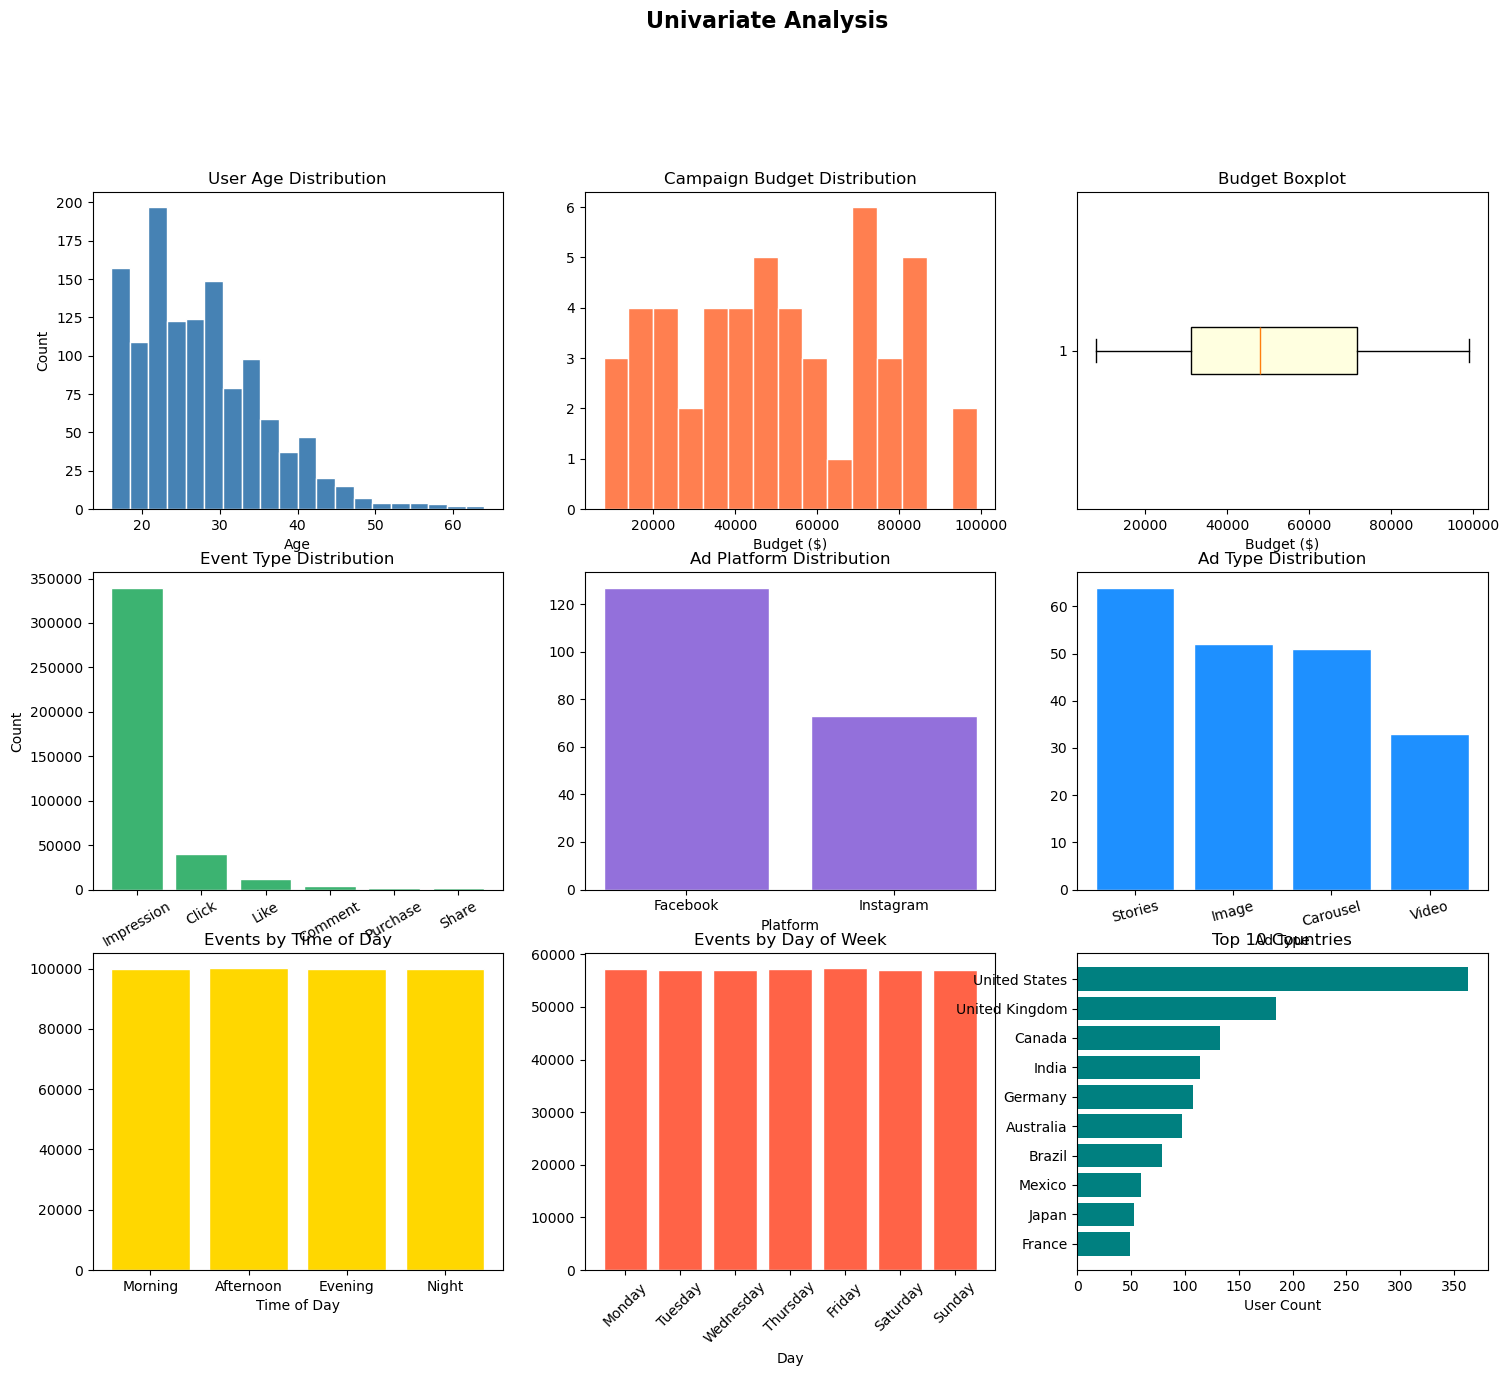

In [90]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Univariate Analysis', fontsize=16, fontweight='bold', y=1.01)

# 1. User Age Distribution
axes[0,0].hist(users['user_age'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('User Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# 2. Total Budget Distribution
axes[0,1].hist(campaigns['total_budget'], bins=15, color='coral', edgecolor='white')
axes[0,1].set_title('Campaign Budget Distribution')
axes[0,1].set_xlabel('Budget ($)')

# 3. Budget Boxplot (outlier check)
axes[0,2].boxplot(campaigns['total_budget'], vert=False, patch_artist=True,
                  boxprops=dict(facecolor='lightyellow'))
axes[0,2].set_title('Budget Boxplot')
axes[0,2].set_xlabel('Budget ($)')

# 4. Event Type Counts
et = events['event_type'].value_counts()
axes[1,0].bar(et.index, et.values, color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Event Type Distribution')
axes[1,0].set_xlabel('Event Type')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=30)

# 5. Ad Platform
ap = ads['ad_platform'].value_counts()
axes[1,1].bar(ap.index, ap.values, color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Ad Platform Distribution')
axes[1,1].set_xlabel('Platform')

# 6. Ad Type
at = ads['ad_type'].value_counts()
axes[1,2].bar(at.index, at.values, color='dodgerblue', edgecolor='white')
axes[1,2].set_title('Ad Type Distribution')
axes[1,2].set_xlabel('Ad Type')
axes[1,2].tick_params(axis='x', rotation=15)

# 7. Time of Day
tod = events['time_of_day'].value_counts().reindex(['Morning','Afternoon','Evening','Night'])
axes[2,0].bar(tod.index, tod.values, color='gold', edgecolor='white')
axes[2,0].set_title('Events by Time of Day')
axes[2,0].set_xlabel('Time of Day')

# 8. Day of Week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = events['day_of_week'].value_counts().reindex(dow_order)
axes[2,1].bar(dow.index, dow.values, color='tomato', edgecolor='white')
axes[2,1].set_title('Events by Day of Week')
axes[2,1].set_xlabel('Day')
axes[2,1].tick_params(axis='x', rotation=45)

# 9. Top 10 Countries
top_countries = users['country'].value_counts().head(10)
axes[2,2].barh(top_countries.index[::-1], top_countries.values[::-1], color='teal')
axes[2,2].set_title('Top 10 Countries')
axes[2,2].set_xlabel('User Count')








## Step 8: Bivariate Analysis

**Goal:** Understand how each variable relates to `event_type` (ad performance).

**Analysis to perform:**

| X Variable | Y Variable | Chart Type | Question |
|---|---|---|---|
| `ad_platform` | `event_type` | Stacked / grouped bar | Which platform drives more engagement? |
| `ad_type` | `event_type` | Stacked bar | Video vs Banner vs Stories performance? |
| `time_of_day` | `event_type` | Grouped bar | When do users engage most? |
| `day_of_week` | `event_type` | Grouped bar | Weekday vs weekend patterns? |
| `user_age` | `event_type` | Boxplot | Do younger users engage differently? |
| `user_gender` | `event_type` | Grouped bar | Gender-based engagement difference? |
| `age_group` | `event_type` | Heatmap (crosstab) | Age group × event type matrix |

**Useful pandas method:** `pd.crosstab(df['col1'], df['col2'])` → then plot as heatmap

In [ ]:
# YOUR CODE HERE
# Bivariate analysis — event_type vs various features

In [91]:
ct1 = pd.crosstab(events.merge(ads[['ad_id','ad_platform']], on='ad_id')['ad_platform'],
                  events['event_type'], normalize='index') * 100

In [92]:
ct1

event_type,Click,Comment,Impression,Like,Purchase,Share
ad_platform,,,,,,
Facebook,9.991893,1.035829,84.996222,2.953608,0.520669,0.501779
Instagram,10.068264,1.011624,84.877728,3.089703,0.485251,0.467431


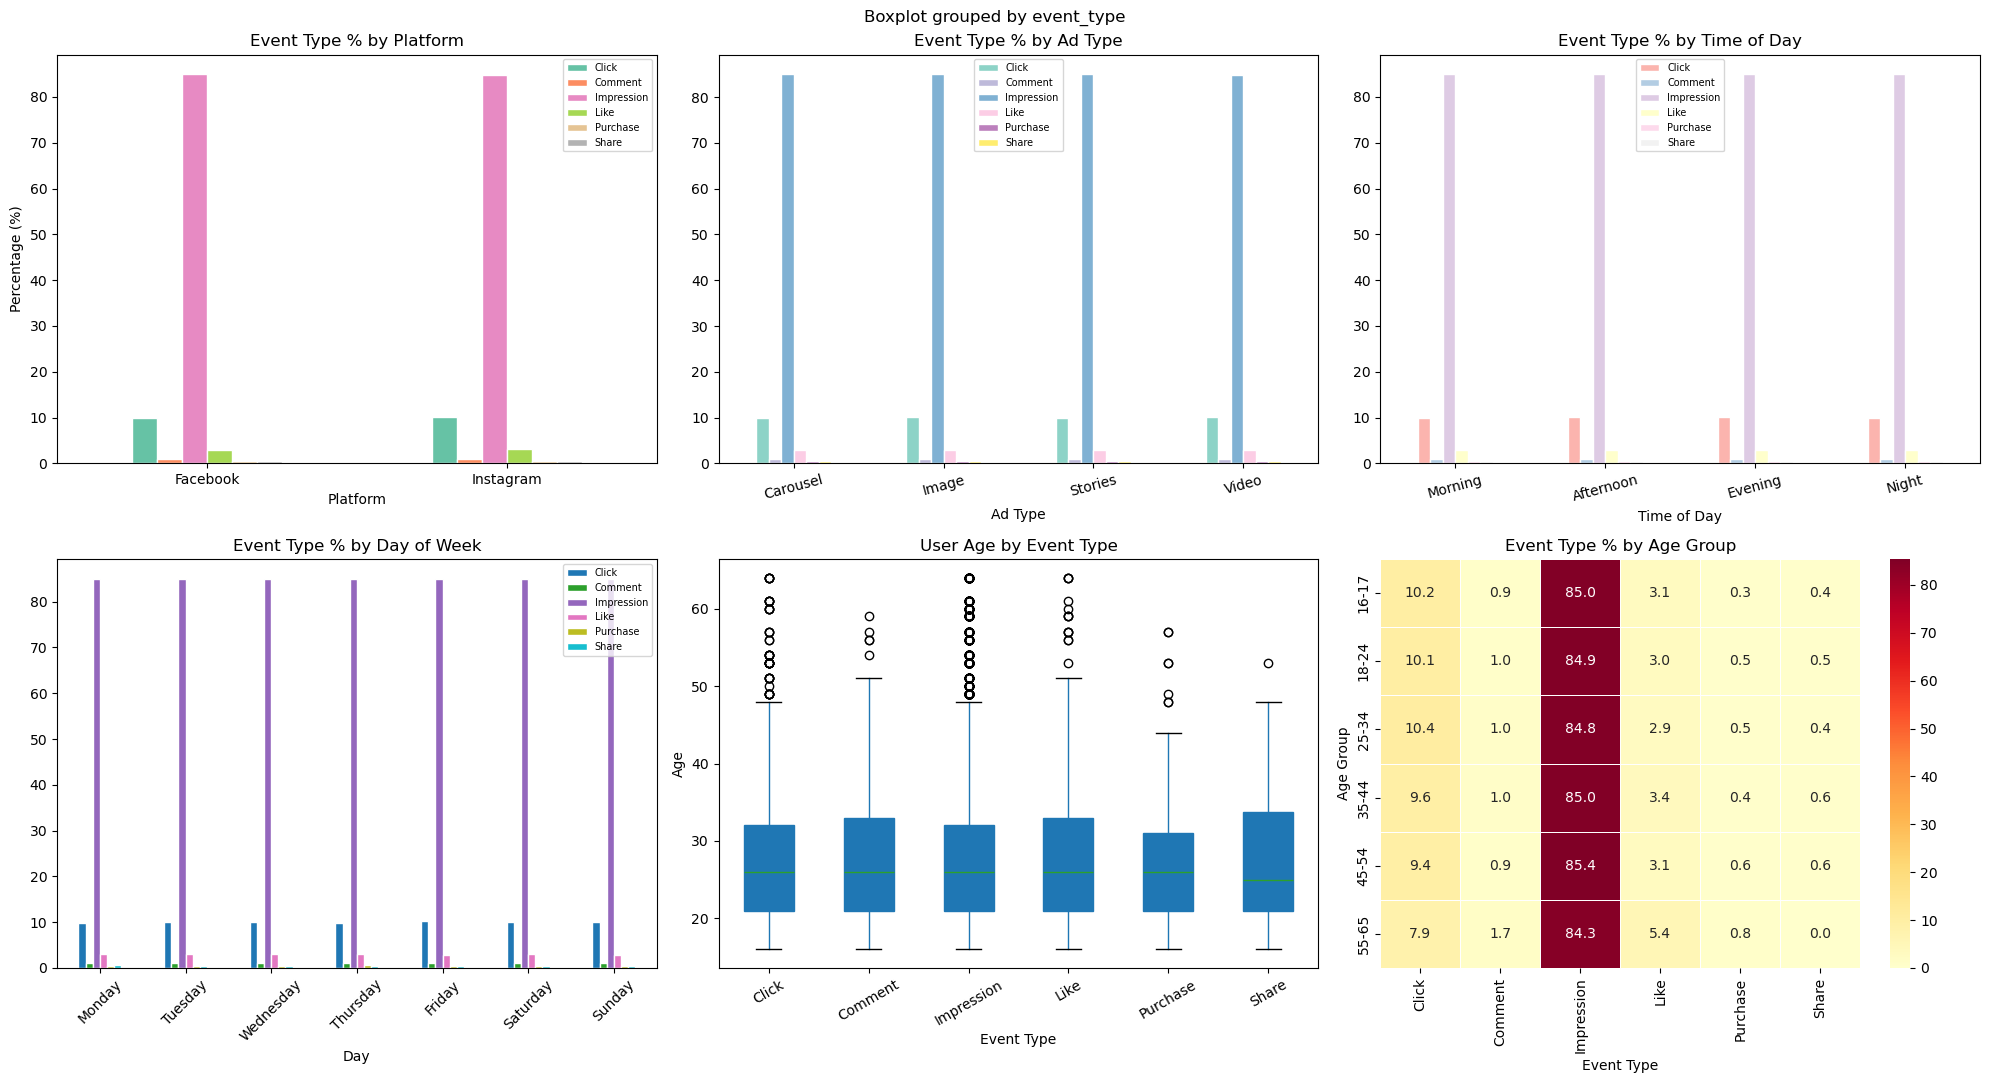

In [100]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Bivariate Analysis — Feature vs Event Type', fontsize=15, fontweight='bold')

ct1.plot(kind='bar', ax=axes[0,0], colormap='Set2', edgecolor='white')
axes[0,0].set_title('Event Type % by Platform')
axes[0,0].set_xlabel('Platform')
axes[0,0].set_ylabel('Percentage (%)')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].legend(fontsize=7)

merged_ad = events.merge(ads[['ad_id','ad_type']], on='ad_id')
ct2 = pd.crosstab(merged_ad['ad_type'], merged_ad['event_type'], normalize='index') * 100
ct2.plot(kind='bar', ax=axes[0,1], colormap='Set3', edgecolor='white')
axes[0,1].set_title('Event Type % by Ad Type')
axes[0,1].set_xlabel('Ad Type')
axes[0,1].tick_params(axis='x', rotation=15)
axes[0,1].legend(fontsize=7)

tod_order = ['Morning','Afternoon','Evening','Night']
ct3 = pd.crosstab(events['time_of_day'], events['event_type'], normalize='index') * 100
ct3 = ct3.reindex(tod_order)
ct3.plot(kind='bar', ax=axes[0,2], colormap='Pastel1', edgecolor='white')
axes[0,2].set_title('Event Type % by Time of Day')
axes[0,2].set_xlabel('Time of Day')
axes[0,2].tick_params(axis='x', rotation=15)
axes[0,2].legend(fontsize=7)

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ct4 = pd.crosstab(events['day_of_week'], events['event_type'], normalize='index') * 100
ct4 = ct4.reindex(dow_order)
ct4.plot(kind='bar', ax=axes[1,0], colormap='tab10', edgecolor='white')
axes[1,0].set_title('Event Type % by Day of Week')
axes[1,0].set_xlabel('Day')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(fontsize=7)

merged_user = events.merge(users[['user_id','user_age']], on='user_id')
merged_user.boxplot(column='user_age', by='event_type', ax=axes[1,1],
                    patch_artist=True, grid=False)
axes[1,1].set_title('User Age by Event Type')
axes[1,1].set_xlabel('Event Type')
axes[1,1].set_ylabel('Age')
plt.sca(axes[1,1])
plt.xticks(rotation=30)

# ── 6. Age Group vs Event Type Heatmap ───────────────────────────────────────
merged_ag = events.merge(users[['user_id','age_group']], on='user_id')
ct6 = pd.crosstab(merged_ag['age_group'], merged_ag['event_type'], normalize='index') * 100
age_order = ['16-17','18-24','25-34','35-44','45-54','55-65']
ct6 = ct6.reindex(age_order)
sns.heatmap(ct6, ax=axes[1,2], annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
axes[1,2].set_title('Event Type % by Age Group')
axes[1,2].set_xlabel('Event Type')
axes[1,2].set_ylabel('Age Group')

plt.tight_layout()
plt.show()


## Step 9: Campaign-Level Analysis

**Goal:** Understand which campaigns perform best and whether budget/duration matters.

**Tasks:**
- Group `ad_events` by `campaign_id` (via `ad_id`) → count total events per campaign
- Merge with campaigns table → add budget and duration
- Plot: **Budget vs Total Events** → scatter plot (does higher budget = more events?)
- Plot: **Duration vs Total Events** → scatter plot (is longer always better?)
- Plot: **Top 10 campaigns by event volume** → horizontal bar chart
- Calculate: **Cost per event** = `total_budget / total_events` → which campaign is most efficient?

In [ ]:
# YOUR CODE HERE
# Campaign-level aggregation and plots

In [104]:
# Aggregate events per ad → then map to campaign
events_with_camp = events.merge(ads[['ad_id','campaign_id']], on='ad_id')



In [105]:
events_with_camp

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,campaign_id
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like,9
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share,26
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression,10
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression,14
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression,2
...,...,...,...,...,...,...,...,...
399995,399996,132,3cb8c,2025-08-01 22:36:54,Friday,Evening,Impression,1
399996,399997,200,fe0e3,2025-05-31 14:53:18,Saturday,Afternoon,Impression,44
399997,399998,2,a08c1,2025-07-27 13:39:51,Sunday,Afternoon,Click,33
399998,399999,109,4f0cf,2025-05-16 02:38:23,Friday,Night,Impression,8


In [106]:
campaign_events  = events_with_camp.groupby('campaign_id').agg(
    total_events=('event_id', 'count')
).reset_index()

In [107]:
campaign_events

,campaign_id,total_events
0,1,5919
1,2,6146
2,3,7895
3,4,12027
4,5,6033
5,6,6011
6,7,5921
7,8,10011
8,9,12139
9,10,7823


In [109]:
camp_analysis = campaigns.merge(campaign_events, on='campaign_id')

In [111]:
camp_analysis['cost_per_event'] = (camp_analysis['total_budget'] / camp_analysis['total_events']).round(4)


In [112]:
print('=== CAMPAIGN PERFORMANCE SUMMARY ===')
display(camp_analysis.sort_values('total_events', ascending=False).head(10))

=== CAMPAIGN PERFORMANCE SUMMARY ===


,campaign_id,name,start_date,end_date,duration_days,total_budget,total_events,cost_per_event
40,42,Campaign_42_Summer,2025-06-08,2025-07-25,47,7918.04,16030,0.4940
18,20,Campaign_20_Winter,2025-02-17,2025-05-18,90,98904.66,16025,6.1719
22,24,Campaign_24_Summer,2025-03-30,2025-05-23,54,56692.87,15989,3.5457
15,17,Campaign_17_Launch,2025-04-22,2025-07-18,87,86675.92,15984,5.4227
36,38,Campaign_38_Q3,2025-04-21,2025-05-27,36,71038.28,15874,4.4751
31,33,Campaign_33_Summer,2025-04-08,2025-07-04,87,59264.68,14165,4.1839
27,29,Campaign_29_Winter,2025-07-16,2025-10-06,82,19773.66,13802,1.4327
12,13,Campaign_13_Winter,2025-04-19,2025-07-01,73,21855.42,12173,1.7954
8,9,Campaign_9_Launch,2025-05-25,2025-07-13,49,40094.07,12139,3.3029
44,47,Campaign_47_Launch,2025-06-17,2025-09-03,78,69493.36,12093,5.7466


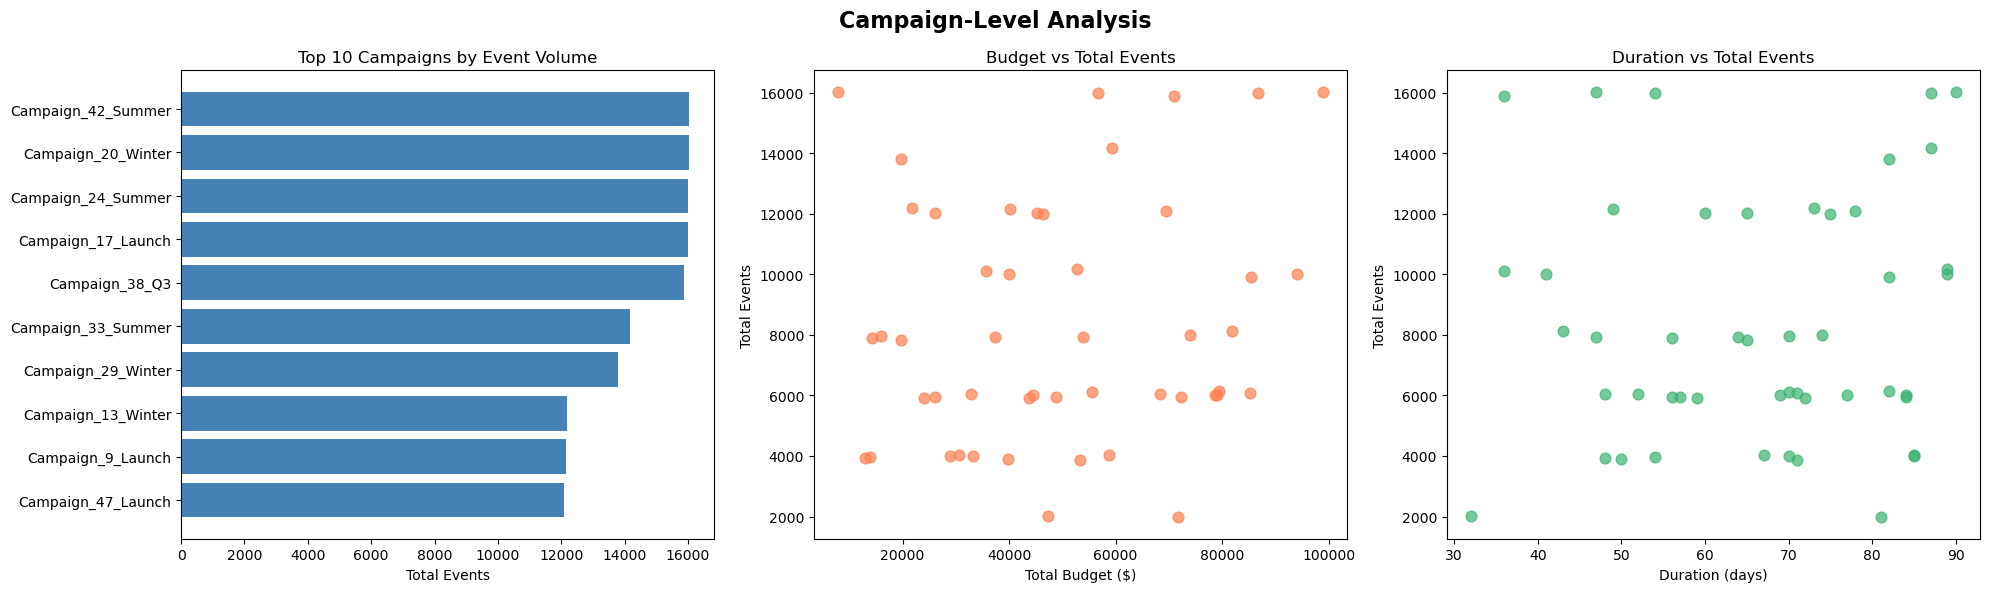


Most efficient campaign (lowest cost/event): Campaign_42_Summer


In [115]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Campaign-Level Analysis', fontsize=16, fontweight='bold')

# 1. Top 10 campaigns by events
top10 = camp_analysis.nlargest(10, 'total_events')
axes[0].barh(top10['name'], top10['total_events'], color='steelblue')
axes[0].set_title('Top 10 Campaigns by Event Volume')
axes[0].set_xlabel('Total Events')
axes[0].invert_yaxis()

# 2. Budget vs Total Events
axes[1].scatter(camp_analysis['total_budget'], camp_analysis['total_events'],
                color='coral', alpha=0.7, s=60)
axes[1].set_title('Budget vs Total Events')
axes[1].set_xlabel('Total Budget ($)')
axes[1].set_ylabel('Total Events')

# 3. Duration vs Total Events
axes[2].scatter(camp_analysis['duration_days'], camp_analysis['total_events'],
                color='mediumseagreen', alpha=0.7, s=60)
axes[2].set_title('Duration vs Total Events')
axes[2].set_xlabel('Duration (days)')
axes[2].set_ylabel('Total Events')

plt.tight_layout()
plt.show()

print(f'\nMost efficient campaign (lowest cost/event): '
      f'{camp_analysis.loc[camp_analysis["cost_per_event"].idxmin(), "name"]}')

---
# 🟣 PHASE 4 — Standardization & Encoding

## Step 10: Encode Categorical Variables

**Goal:** Convert all string/categorical columns to numbers for ML models.

**Encoding strategy:**

| Column | Type | Method |
|---|---|---|
| `user_gender`, `target_gender` | Binary | Label Encoding: Male=1, Female=0 |
| `ad_platform`, `ad_type`, `country`, `time_of_day` | Nominal (no order) | One-Hot Encoding (`pd.get_dummies`) |
| `age_group` (16-17, 18-24, 25-34...) | Ordinal (has order) | Manual mapping: `{'16-17': 1, '18-24': 2, ...}` |
| `event_type` | Target variable | Label Encoding: assign 0,1,2... per type |

**⚠️ Do NOT encode before EDA** — encoded numbers make value_counts() and plots unreadable.

**Useful classes:** `sklearn.preprocessing.LabelEncoder`, `pd.get_dummies()`

In [ ]:
# YOUR CODE HERE
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns

In [116]:
from sklearn.preprocessing import LabelEncoder

# Work on copies to preserve originals for EDA reference
users_enc = users.copy()
ads_enc   = ads.copy()
events_enc = events.copy()

# ── Binary encoding: Male=1, Female=0, Other=2 ────────────────────────────────
gender_map = {'Male': 1, 'Female': 0, 'Other': 2}
users_enc['user_gender_enc'] = users_enc['user_gender'].map(gender_map)

target_gender_map = {'Male': 1, 'Female': 0, 'All': 2}
ads_enc['target_gender_enc'] = ads_enc['target_gender'].map(target_gender_map)

# ── Ordinal encoding: age_group (ordered) ─────────────────────────────────────
age_order = {'16-17': 1, '18-24': 2, '25-34': 3, '35-44': 4, '45-54': 5, '55-65': 6}
users_enc['age_group_enc']        = users_enc['age_group'].map(age_order)
ads_enc['target_age_group_enc']   = ads_enc['target_age_group'].map(age_order)

# ── One-hot encoding: ad_platform, ad_type, time_of_day ──────────────────────
ads_enc   = pd.get_dummies(ads_enc,    columns=['ad_platform', 'ad_type'],  prefix=['platform', 'adtype'])
events_enc = pd.get_dummies(events_enc, columns=['time_of_day', 'day_of_week'], prefix=['tod', 'dow'])

# ── Label encode event_type (target variable) ─────────────────────────────────
le = LabelEncoder()
events_enc['event_type_enc'] = le.fit_transform(events_enc['event_type'])
event_type_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Event type encoding:', event_type_mapping)

print('\n✅ Encoding complete')
print('Users encoded columns   :', [c for c in users_enc.columns if '_enc' in c or 'platform' in c])
print('Ads encoded columns     :', [c for c in ads_enc.columns if '_enc' in c or 'platform' in c or 'adtype' in c])

Event type encoding: {'Click': 0, 'Comment': 1, 'Impression': 2, 'Like': 3, 'Purchase': 4, 'Share': 5}

✅ Encoding complete
Users encoded columns   : ['user_gender_enc', 'age_group_enc']
Ads encoded columns     : ['target_gender_enc', 'target_age_group_enc', 'platform_Facebook', 'platform_Instagram', 'adtype_Carousel', 'adtype_Image', 'adtype_Stories', 'adtype_Video']


## Step 11: Standardize Numerical Variables

**Goal:** Rescale numerical columns so they have comparable ranges (important for distance-based ML).

**When to use which scaler:**
| Scaler | Formula | Use When |
|---|---|---|
| `StandardScaler` | `(x - mean) / std` | Data roughly normal, has outliers |
| `MinMaxScaler` | `(x - min) / (max - min)` | Data bounded, no extreme outliers |

**Columns to scale:** `user_age`, `total_budget`, `duration_days`

**⚠️ Important:**
- Scale **after merging**, not before (otherwise you lose context)
- Fit the scaler on **training data only** (if building a model) — don't leak test data
- Keep a copy of the **unscaled dataframe** for interpretation

**Useful classes:** `sklearn.preprocessing.StandardScaler`, `MinMaxScaler`

In [ ]:
# YOUR CODE HERE
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Scale numerical columns

In [117]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Columns to scale
num_cols = ['user_age', 'total_budget', 'duration_days']

# StandardScaler (mean=0, std=1) — good when data may be normally distributed
scaler = StandardScaler()

# Keep unscaled copy first
users_unscaled     = users_enc.copy()
campaigns_unscaled = campaigns.copy()

# Scale user_age
users_enc['user_age_scaled']           = scaler.fit_transform(users_enc[['user_age']])

# Scale campaign numerics
campaigns['total_budget_scaled']       = scaler.fit_transform(campaigns[['total_budget']])
campaigns['duration_days_scaled']      = scaler.fit_transform(campaigns[['duration_days']])

print('=== SCALING VERIFICATION ===')
print(f'user_age        — mean: {users_enc["user_age"].mean():.1f}, std: {users_enc["user_age"].std():.1f}')
print(f'user_age_scaled — mean: {users_enc["user_age_scaled"].mean():.4f}, std: {users_enc["user_age_scaled"].std():.4f}')
print(f'\ntotal_budget        — mean: {campaigns["total_budget"].mean():.1f}')
print(f'total_budget_scaled — mean: {campaigns["total_budget_scaled"].mean():.4f}')

=== SCALING VERIFICATION ===
user_age        — mean: 27.4, std: 8.3
user_age_scaled — mean: -0.0000, std: 1.0004

total_budget        — mean: 50718.5
total_budget_scaled — mean: -0.0000


## Step 12: Handle the `interests` Column (Multi-Hot Encoding)

**Goal:** Convert comma-separated interest strings into binary feature columns.

**Example transformation:**
```
interests = 'lifestyle, health'  →  lifestyle=1, health=1, travel=0, food=0 ...
interests = 'food, finance'      →  lifestyle=0, health=0, travel=0, food=1 ...
```

**Steps:**
1. Split: `df['interests'].str.split(', ')` → list of strings per row
2. Apply `MultiLabelBinarizer` → creates one binary column per unique interest tag
3. Join back to the main dataframe
4. Drop original `interests` column

**Same approach for `target_interests` in ads table.**

**Useful class:** `sklearn.preprocessing.MultiLabelBinarizer`

In [ ]:
# YOUR CODE HERE
from sklearn.preprocessing import MultiLabelBinarizer

# Multi-hot encode interests column

In [118]:
from sklearn.preprocessing import MultiLabelBinarizer

# ── User interests ─────────────────────────────────────────────────────────────
users_enc['interests_list']      = users_enc['interests'].str.split(', ')
ads_enc['target_interests_list'] = ads_enc['target_interests'].str.lower().str.split(', ')

mlb = MultiLabelBinarizer()

# Encode user interests
user_interest_matrix = mlb.fit_transform(users_enc['interests_list'])
user_interest_df     = pd.DataFrame(user_interest_matrix,
                                     columns=['ui_' + c for c in mlb.classes_],
                                     index=users_enc.index)
users_enc = pd.concat([users_enc, user_interest_df], axis=1)

# Encode ad target_interests (fit separately)
mlb2 = MultiLabelBinarizer()
ad_interest_matrix = mlb2.fit_transform(ads_enc['target_interests_list'])
ad_interest_df     = pd.DataFrame(ad_interest_matrix,
                                   columns=['ti_' + c for c in mlb2.classes_],
                                   index=ads_enc.index)
ads_enc = pd.concat([ads_enc, ad_interest_df], axis=1)

# Drop original text columns (no longer needed after encoding)
users_enc.drop(columns=['interests', 'interests_list'], inplace=True)
ads_enc.drop(columns=['target_interests', 'target_interests_list'], inplace=True)

print(f'User interest columns added : {user_interest_df.shape[1]}')
print(f'Ad interest columns added   : {ad_interest_df.shape[1]}')
print(f'users_enc shape  : {users_enc.shape}')
print(f'ads_enc shape    : {ads_enc.shape}')

User interest columns added : 13
Ad interest columns added   : 13
users_enc shape  : (1240, 22)
ads_enc shape    : (200, 25)


---
# 🔴 PHASE 5 — Merge the Full Dataset

## Step 13: Plan Your Joins

**Goal:** Understand the merge strategy before writing any code.

**Join plan:**
```
Step A:  ad_events  ──(ad_id)──►  ads          → adds platform, ad_type, campaign_id
Step B:  result_A   ──(campaign_id)──►  campaigns  → adds budget, dates, duration
Step C:  result_B   ──(user_id)──►  users       → adds age, gender, country, interests
```

**Key decisions:**
- Use `how='left'` → keep all 400k events, even if some lookups fail
- Use `how='inner'` → keep only rows that match in both tables (loses unmatched events)
- Recommended: start with `left`, check how many nulls appear after merge

**Before merging — verify join keys:**
- Are all `ad_id` values in ad_events present in ads? `set(events.ad_id) - set(ads.ad_id)`
- Are all `user_id` values in ad_events present in users? Same check
- Are data types of join keys the same on both sides? (Very important!)

In [ ]:
# YOUR CODE HERE
# Check key compatibility before merging
# e.g. print(set(ad_events['ad_id'].unique()) - set(ads['ad_id'].unique()))

In [120]:
# Check if all ad_ids in events exist in ads
events_ad_ids = set(events['ad_id'].unique())
ads_ad_ids    = set(ads['ad_id'].unique())
missing_ads   = events_ad_ids - ads_ad_ids
print(f'Ad IDs in events but NOT in ads: {len(missing_ads)} → {list(missing_ads)[:5]}')

# Check if all user_ids in events exist in users
events_user_ids = set(events['user_id'].astype(str).unique())
users_user_ids  = set(users_enc['user_id'].astype(str).unique())
missing_users   = events_user_ids - users_user_ids
#print(f'User IDs in events but NOT in users: {len(missing_users)} → list(missing_users)[:5]}')

# Check data types match on join keys
print(f'\nJoin key dtypes:')
print(f'  events.ad_id   : {events["ad_id"].dtype}   | ads.ad_id   : {ads_enc["ad_id"].dtype}')
print(f'  events.user_id : {events["user_id"].dtype} | users.user_id: {users_enc["user_id"].dtype}')
print(f'  ads.campaign_id: {ads_enc["campaign_id"].dtype} | campaigns.campaign_id: {campaigns["campaign_id"].dtype}')

Ad IDs in events but NOT in ads: 0 → []

Join key dtypes:
  events.ad_id   : int64   | ads.ad_id   : int32
  events.user_id : object | users.user_id: object
  ads.campaign_id: int32 | campaigns.campaign_id: int64


In [121]:
# ── Fix 1: ad_id — make both int64 ───────────────────────────────────────────
print("BEFORE:")
print(f"  events.ad_id  : {events['ad_id'].dtype}")
print(f"  ads.ad_id     : {ads['ad_id'].dtype}")

events['ad_id'] = events['ad_id'].astype('int64')
ads['ad_id']    = ads['ad_id'].astype('int64')

print("AFTER:")
print(f"  events.ad_id  : {events['ad_id'].dtype}")
print(f"  ads.ad_id     : {ads['ad_id'].dtype}")

# ── Fix 2: campaign_id — make both int64 ─────────────────────────────────────
print("\nBEFORE:")
print(f"  ads.campaign_id       : {ads['campaign_id'].dtype}")
print(f"  campaigns.campaign_id : {campaigns['campaign_id'].dtype}")

ads['campaign_id'] = ads['campaign_id'].astype('int64')

print("AFTER:")
print(f"  ads.campaign_id       : {ads['campaign_id'].dtype}")
print(f"  campaigns.campaign_id : {campaigns['campaign_id'].dtype}")

BEFORE:
  events.ad_id  : int64
  ads.ad_id     : int32
AFTER:
  events.ad_id  : int64
  ads.ad_id     : int64

BEFORE:
  ads.campaign_id       : int32
  campaigns.campaign_id : int64
AFTER:
  ads.campaign_id       : int64
  campaigns.campaign_id : int64


In [122]:
print("=== FINAL JOIN KEY CHECK ===")

print("\n1. events.ad_id  vs  ads.ad_id")
print(f"   events : {events['ad_id'].dtype}")
print(f"   ads    : {ads['ad_id'].dtype}")
print(f"   Match  : {events['ad_id'].dtype == ads['ad_id'].dtype}")

print("\n2. ads.campaign_id  vs  campaigns.campaign_id")
print(f"   ads       : {ads['campaign_id'].dtype}")
print(f"   campaigns : {campaigns['campaign_id'].dtype}")
print(f"   Match     : {ads['campaign_id'].dtype == campaigns['campaign_id'].dtype}")

print("\n3. events.user_id  vs  users.user_id")
print(f"   events : {events['user_id'].dtype}")
print(f"   users  : {users_clean['user_id'].dtype}")
print(f"   Match  : {events['user_id'].dtype == users_clean['user_id'].dtype}")

# All 3 should print Match: True

=== FINAL JOIN KEY CHECK ===

1. events.ad_id  vs  ads.ad_id
   events : int64
   ads    : int64
   Match  : True

2. ads.campaign_id  vs  campaigns.campaign_id
   ads       : int64
   campaigns : int64
   Match     : True

3. events.user_id  vs  users.user_id
   events : object
   users  : object
   Match  : True


## Step 14: Execute the Merges

**Goal:** Build one unified dataframe from all 4 tables.

**Steps:**
1. Merge `ad_events` + `ads` on `ad_id` → `df_step1`
2. Merge `df_step1` + `campaigns` on `campaign_id` → `df_step2`
3. Merge `df_step2` + `users` on `user_id` → `df_final`

**After each merge:**
- Print `.shape` → row count should remain ~400k (left join)
- Print `.columns` → confirm new columns were added
- Check for column name conflicts → pandas adds `_x` / `_y` suffix automatically

**Watch out for:**
- If row count **increases** → join key is not unique on the right side (fan-out problem)
- If row count **decreases a lot** → many unmatched keys (data quality issue)

In [ ]:
# YOUR CODE HERE
# Step A: merge events + ads
# Step B: merge result + campaigns
# Step C: merge result + users
# Print shape after each step

In [134]:
# We build our final dataset step by step
# Starting with events (400k rows) and adding columns from other tables

print("Starting shape:", events.shape)

# ── Step A: events + ads ──────────────────────────────────────────────────────
# This adds: ad_platform, ad_type, campaign_id etc. to every event
df = events.merge(ads_enc, on='ad_id', how='left')
#            ↑ base table  ↑ table to add  ↑ column to match on
#                                          how='left' = keep ALL rows from events
#                                                       even if no match in ads
print("After merging with ads      :", df.shape)

# ── Step B: result + campaigns ────────────────────────────────────────────────
# This adds: budget, start_date, duration etc. to every event
df = df.merge(campaigns, on='campaign_id', how='left')
print("After merging with campaigns:", df.shape)

# ── Step C: result + users ────────────────────────────────────────────────────
# This adds: user_age, user_gender, country etc. to every event
df = df.merge(users_enc, on='user_id', how='left')
print("After merging with users    :", df.shape)

# Row count should stay close to the original 400k events
# If it explodes (e.g. millions), there's a duplicate key issue

print("\nAll columns in final merged table:")
print(df.columns.tolist())

Starting shape: (400000, 7)
After merging with ads      : (400000, 31)
After merging with campaigns: (400000, 38)
After merging with users    : (400000, 59)

All columns in final merged table:
['event_id', 'ad_id', 'user_id', 'timestamp', 'day_of_week', 'time_of_day', 'event_type', 'campaign_id', 'target_gender', 'target_age_group', 'target_gender_enc', 'target_age_group_enc', 'platform_Facebook', 'platform_Instagram', 'adtype_Carousel', 'adtype_Image', 'adtype_Stories', 'adtype_Video', 'ti_art', 'ti_fashion', 'ti_finance', 'ti_fitness', 'ti_food', 'ti_gaming', 'ti_health', 'ti_lifestyle', 'ti_news', 'ti_photography', 'ti_sports', 'ti_technology', 'ti_travel', 'name', 'start_date', 'end_date', 'duration_days', 'total_budget', 'total_budget_scaled', 'duration_days_scaled', 'user_gender', 'user_age', 'age_group', 'country', 'location', 'user_gender_enc', 'age_group_enc', 'user_age_scaled', 'ui_art', 'ui_fashion', 'ui_finance', 'ui_fitness', 'ui_food', 'ui_gaming', 'ui_health', 'ui_lifest

## Step 15: Post-Merge Validation

**Goal:** Ensure the merged dataset is clean and consistent before feature engineering.

**Checklist:**
- `df_final.shape` → expected ~400k rows
- `df_final.isnull().sum()` → re-check for new nulls introduced by the join
- `df_final.dtypes` → re-check all types are still correct
- `df_final.duplicated().sum()` → check for duplicate rows post-merge
- Remove any redundant columns created during merge (e.g. duplicate ID columns)
- Print `df_final.columns.tolist()` → review all available columns

**At this point you should have one dataframe with all information about every ad interaction.**

In [135]:
# YOUR CODE HERE
# Validate the merged dataset
# Drop redundant columns

print("=== Final dataset check ===")
print(f"Shape      : {df.shape}")
print(f"Duplicates : {df.duplicated().sum()}")

# Merges can introduce new NaN values for unmatched rows
print("\nNull values after merge:")
null_check = df.isnull().sum()
print(null_check[null_check > 0].sort_values(ascending=False))

# Remove columns that got duplicated during merge
# When both tables have a column with the same name, pandas adds _x and _y
dup_cols = [c for c in df.columns if c.endswith('_x') or c.endswith('_y')]
print(f"\nColumns with _x or _y suffix (duplicates): {dup_cols}")
df = df.drop(columns=dup_cols)

# Fill any remaining nulls
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna('Unknown')

for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

print(f"\n✅ Final clean shape: {df.shape}")
print(df.head(3))

=== Final dataset check ===
Shape      : (400000, 59)
Duplicates : 0

Null values after merge:
ui_finance              363814
user_gender             363814
ui_technology           363814
ui_sports               363814
ui_photography          363814
ui_news                 363814
ui_lifestyle            363814
ui_health               363814
ui_gaming               363814
ui_food                 363814
ui_fitness              363814
ui_travel               363814
ui_fashion              363814
ui_art                  363814
user_age_scaled         363814
age_group_enc           363814
user_gender_enc         363814
location                363814
country                 363814
age_group               363814
user_age                363814
target_age_group_enc     92334
dtype: int64

Columns with _x or _y suffix (duplicates): []

✅ Final clean shape: (400000, 59)
   event_id  ad_id user_id           timestamp day_of_week time_of_day  \
0         1    197   2359b 2025-07-26 00:19:56    Satu

In [137]:
df

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,campaign_id,target_gender,target_age_group,...,ui_fitness,ui_food,ui_gaming,ui_health,ui_lifestyle,ui_news,ui_photography,ui_sports,ui_technology,ui_travel
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like,9,All,All,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share,26,All,18-24,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression,10,All,35-44,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression,14,All,All,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression,2,Female,35-44,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399995,399996,132,3cb8c,2025-08-01 22:36:54,Friday,Evening,Impression,1,Female,18-24,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
399996,399997,200,fe0e3,2025-05-31 14:53:18,Saturday,Afternoon,Impression,44,Male,18-24,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
399997,399998,2,a08c1,2025-07-27 13:39:51,Sunday,Afternoon,Click,33,All,25-34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
399998,399999,109,4f0cf,2025-05-16 02:38:23,Friday,Night,Impression,8,All,35-44,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [139]:
df.to_csv('final_merged_data.csv', index=False)

In [155]:
df.columns

Index(['event_id', 'ad_id', 'user_id', 'timestamp', 'day_of_week',
       'time_of_day', 'event_type', 'campaign_id', 'target_gender',
       'target_age_group', 'target_gender_enc', 'target_age_group_enc',
       'platform_Facebook', 'platform_Instagram', 'adtype_Carousel',
       'adtype_Image', 'adtype_Stories', 'adtype_Video', 'ti_art',
       'ti_fashion', 'ti_finance', 'ti_fitness', 'ti_food', 'ti_gaming',
       'ti_health', 'ti_lifestyle', 'ti_news', 'ti_photography', 'ti_sports',
       'ti_technology', 'ti_travel', 'name', 'start_date', 'end_date',
       'duration_days', 'total_budget', 'total_budget_scaled',
       'duration_days_scaled', 'user_gender', 'user_age', 'age_group',
       'country', 'location', 'user_gender_enc', 'age_group_enc',
       'user_age_scaled', 'ui_art', 'ui_fashion', 'ui_finance', 'ui_fitness',
       'ui_food', 'ui_gaming', 'ui_health', 'ui_lifestyle', 'ui_news',
       'ui_photography', 'ui_sports', 'ui_technology', 'ui_travel', 'is_click',
      

In [140]:
print(f"✅ Saved successfully!")
print(f"   File name : merged_ad_data.csv")
print(f"   Rows      : {len(df):,}")
print(f"   Columns   : {df.shape[1]}")

✅ Saved successfully!
   File name : merged_ad_data.csv
   Rows      : 400,000
   Columns   : 59


In [157]:
# Reload your saved CSV
df = pd.read_csv('final_merged_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("=== ALL COLUMNS IN YOUR SAVED CSV ===")
for col in df.columns:
    print(col)

=== ALL COLUMNS IN YOUR SAVED CSV ===
event_id
ad_id
user_id
timestamp
day_of_week
time_of_day
event_type
campaign_id
target_gender
target_age_group
target_gender_enc
target_age_group_enc
platform_Facebook
platform_Instagram
adtype_Carousel
adtype_Image
adtype_Stories
adtype_Video
ti_art
ti_fashion
ti_finance
ti_fitness
ti_food
ti_gaming
ti_health
ti_lifestyle
ti_news
ti_photography
ti_sports
ti_technology
ti_travel
name
start_date
end_date
duration_days
total_budget
total_budget_scaled
duration_days_scaled
user_gender
user_age
age_group
country
location
user_gender_enc
age_group_enc
user_age_scaled
ui_art
ui_fashion
ui_finance
ui_fitness
ui_food
ui_gaming
ui_health
ui_lifestyle
ui_news
ui_photography
ui_sports
ui_technology
ui_travel


In [158]:
# ── Step 1: Gender match ──────────────────────────────────────────────────────
# target_gender and user_gender raw columns still exist — use them directly
df['gender_match'] = (
    (df['target_gender'] == 'All') |
    (df['user_gender'] == df['target_gender'])
).astype(int)

print("Gender match done!")
print(df['gender_match'].value_counts())

Gender match done!
gender_match
0    248147
1    151853
Name: count, dtype: int64


In [159]:
# ── Step 2: Age match ─────────────────────────────────────────────────────────
# age_group and target_age_group raw columns still exist — use them directly
df['age_match'] = (
    df['age_group'] == df['target_age_group']
).astype(int)

print("Age match done!")
print(df['age_match'].value_counts())

Age match done!
age_match
0    391811
1      8189
Name: count, dtype: int64


In [160]:
# ── Step 3: Rebuild interests from binary columns ─────────────────────────────

# Get the interest column names
ui_cols = [c for c in df.columns if c.startswith('ui_')]
ti_cols = [c for c in df.columns if c.startswith('ti_')]

print(f"User interest columns   : {ui_cols}")
print(f"Target interest columns : {ti_cols}")

# For each row, find which columns are 1 → those are the active interests
def rebuild_interests(row, cols, prefix):
    """
    Example:
      ui_food=1, ui_health=1, ui_travel=0
      → returns 'food, health'
    """
    active = [
        col.replace(prefix, '')  # strip prefix → get interest name
        for col in cols
        if row[col] == 1         # only include if value is 1
    ]
    return ', '.join(active) if active else 'unknown'

# Rebuild user interests
print("\nRebuilding user interests...")
df['interests_rebuilt'] = df.apply(
    lambda row: rebuild_interests(row, ui_cols, 'ui_'),
    axis=1
)

# Rebuild target interests
print("Rebuilding target interests...")
df['target_interests_rebuilt'] = df.apply(
    lambda row: rebuild_interests(row, ti_cols, 'ti_'),
    axis=1
)

# Verify
print("\nSample rebuilt user interests:")
print(df['interests_rebuilt'].head(5).tolist())

print("\nSample rebuilt target interests:")
print(df['target_interests_rebuilt'].head(5).tolist())

User interest columns   : ['ui_art', 'ui_fashion', 'ui_finance', 'ui_fitness', 'ui_food', 'ui_gaming', 'ui_health', 'ui_lifestyle', 'ui_news', 'ui_photography', 'ui_sports', 'ui_technology', 'ui_travel']
Target interest columns : ['ti_art', 'ti_fashion', 'ti_finance', 'ti_fitness', 'ti_food', 'ti_gaming', 'ti_health', 'ti_lifestyle', 'ti_news', 'ti_photography', 'ti_sports', 'ti_technology', 'ti_travel']

Rebuilding user interests...
Rebuilding target interests...

Sample rebuilt user interests:
['unknown', 'unknown', 'unknown', 'unknown', 'unknown']

Sample rebuilt target interests:
['gaming, lifestyle', 'photography', 'technology, travel', 'fashion', 'health, lifestyle']


---
# 🟤 PHASE 6 — Feature Engineering for Ad Performance

## Step 16: Create Event-Level Binary Features

**Goal:** Transform `event_type` into binary flags that capture different kinds of performance.

**New columns to create:**

| New Column | Logic | What it captures |
|---|---|---|
| `is_click` | 1 if event_type == 'Click' | Direct intent |
| `is_conversion` | 1 if event_type in ['Purchase', 'Conversion'] | Business outcome |
| `is_engagement` | 1 if event_type in ['Like', 'Share', 'Comment'] | Social interaction |
| `is_view` | 1 if event_type == 'View' | Passive exposure |
| `event_hour` | Extract hour from timestamp | Time of day (precise) |
| `event_month` | Extract month from timestamp | Seasonal trends |
| `is_weekend` | 1 if day_of_week in ['Saturday', 'Sunday'] | Weekend behavior |

**Useful methods:** `.dt.hour`, `.dt.month`, `.isin()`, `np.where()`

In [ ]:
# YOUR CODE HERE
# Create binary event flag columns
# Extract datetime features from timestamp

In [141]:
# ── Binary event flags ────────────────────────────────────────────────────────
# Convert event_type into simple yes/no columns

# is_click = 1 if the event was a Click, else 0
df['is_click']      = (df['event_type'] == 'Click').astype(int)
df['is_purchase']   = (df['event_type'] == 'Purchase').astype(int)

# is_engagement = 1 if the event was a Like, Share, or Comment
df['is_engagement'] = df['event_type'].isin(['Like', 'Share', 'Comment']).astype(int)
df['is_impression'] = (df['event_type'] == 'Impression').astype(int)

# ── Extract time features from the timestamp column ───────────────────────────
# .dt lets us access date/time parts from a datetime column
df['event_hour']  = df['timestamp'].dt.hour   # 0 to 23
df['event_month'] = df['timestamp'].dt.month  # 1 to 12
df['event_day']   = df['timestamp'].dt.day    # 1 to 31

# ── Weekend flag ──────────────────────────────────────────────────────────────
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# Check the new columns
print("New feature summary:")
print(f"  Total clicks     : {df['is_click'].sum():,}")
print(f"  Total purchases  : {df['is_purchase'].sum():,}")
print(f"  Total engagements: {df['is_engagement'].sum():,}")
print(f"  Weekend events   : {df['is_weekend'].sum():,}")
print(f"  Hour range       : {df['event_hour'].min()} to {df['event_hour'].max()}")

New feature summary:
  Total clicks     : 40,079
  Total purchases  : 2,031
  Total engagements: 18,078
  Weekend events   : 114,017
  Hour range       : 0 to 23


In [143]:
events.head()

,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type
0,1,197,2359b,2025-07-26 00:19:56,Saturday,Night,Like
1,2,51,f9c67,2025-06-15 08:28:07,Sunday,Morning,Share
2,3,46,5b868,2025-06-27 00:40:02,Friday,Night,Impression
3,4,166,3d440,2025-06-05 19:20:45,Thursday,Evening,Impression
4,5,52,68f1a,2025-07-22 08:30:29,Tuesday,Morning,Impression


## Step 17: Create Ad-Level Aggregated Features

**Goal:** Summarize each ad's performance into a single row (ad-level view).

**Group by `ad_id` and compute:**

| New Column | Formula | Meaning |
|---|---|---|
| `total_events` | `count(event_id)` | Total interactions |
| `total_clicks` | `sum(is_click)` | Raw click count |
| `click_rate` | `total_clicks / total_events` | CTR |
| `total_conversions` | `sum(is_conversion)` | Conversion count |
| `conversion_rate` | `total_conversions / total_events` | CVR |
| `engagement_rate` | `sum(is_engagement) / total_events` | Engagement rate |
| `unique_users_reached` | `nunique(user_id)` | Reach |
| `events_per_budget` | `total_events / total_budget` | Efficiency metric |

**Method:** `df.groupby('ad_id').agg({...}).reset_index()`

**This ad-level dataframe will be used for clustering in Phase 9.**

In [142]:
# YOUR CODE HERE
# Aggregate to ad-level performance metrics
# Right now we have one row per EVENT (400k rows)
# We want to summarize: one row per AD (200 rows) with performance stats

# groupby('ad_id') groups all rows with the same ad_id together
# agg() applies different summary functions to each column
ad_metrics = df.groupby('ad_id').agg(
    total_events      = ('event_id',      'count'),   # count total rows
    total_clicks      = ('is_click',      'sum'),     # add up all 1s
    total_purchases   = ('is_purchase',   'sum'),
    total_engagements = ('is_engagement', 'sum'),
    total_impressions = ('is_impression', 'sum'),
    unique_users      = ('user_id',       'nunique'), # count unique users
    total_budget      = ('total_budget',  'first'),   # all rows same budget, take first
).reset_index()  # turns the groupby index back into a regular column

# ── Calculate rates ───────────────────────────────────────────────────────────
# rate = how often something happened out of all events
ad_metrics['click_rate']      = ad_metrics['total_clicks']      / ad_metrics['total_events']
ad_metrics['purchase_rate']   = ad_metrics['total_purchases']   / ad_metrics['total_events']
ad_metrics['engagement_rate'] = ad_metrics['total_engagements'] / ad_metrics['total_events']

# events per dollar spent = efficiency metric
ad_metrics['events_per_budget'] = ad_metrics['total_events'] / ad_metrics['total_budget']

# Round to 4 decimal places for readability
ad_metrics = ad_metrics.round(4)

print("Ad-level metrics shape:", ad_metrics.shape)
print("\nSample:")
print(ad_metrics.head())
print("\nSummary stats:")
print(ad_metrics[['click_rate', 'purchase_rate', 'engagement_rate']].describe())

Ad-level metrics shape: (200, 12)

Sample:
   ad_id  total_events  total_clicks  total_purchases  total_engagements  \
0      1          2052           212                8                 89   
1      2          2058           205               13                 89   
2      3          1996           225               13                103   
3      4          2043           198               12                 96   
4      5          2005           211               11                 90   

   total_impressions  unique_users  total_budget  click_rate  purchase_rate  \
0               1743          1840      32844.79      0.1033         0.0039   
1               1751          1866      59264.68      0.0996         0.0063   
2               1655          1837      98904.66      0.1127         0.0065   
3               1737          1856      32844.79      0.0969         0.0059   
4               1693          1817      56692.87      0.1052         0.0055   

   engagement_rate  event

## Step 18: Create Audience Match Features

**Goal:** Measure how well each ad was targeted to the user who saw it.

> These are likely your **strongest predictors** of ad performance.

**New columns to create:**

| New Column | Logic |
|---|---|
| `gender_match` | 1 if `user_gender == target_gender` OR `target_gender == 'All'` |
| `age_match` | 1 if `user age_group == target_age_group` |
| `interest_overlap_count` | Count of shared interests between user interests and ad target_interests |
| `is_well_targeted` | 1 if `gender_match=1 AND age_match=1 AND interest_overlap_count > 0` |

**For `interest_overlap_count`:**
```python
# Convert both interest strings to sets, then count intersection
user_set = set(user_interests.split(', '))
target_set = set(target_interests.split(', '))
overlap = len(user_set & target_set)
```
Apply this row-by-row using `.apply()` or vectorized string operations.

In [161]:
# YOUR CODE HERE
# Create audience match features: gender_match, age_match, interest_overlap_coun


In [162]:
# ── Step 4: Count interest overlap ───────────────────────────────────────────

def count_overlap(user_interests, target_interests):
    """
    Example:
      user   = 'food, health, travel'
      target = 'health, gaming'
      overlap = {'health'} → returns 1
    """
    user_set   = set(str(user_interests).split(', '))
    target_set = set(str(target_interests).split(', '))
    return len(user_set & target_set)

df['interest_overlap'] = df.apply(
    lambda row: count_overlap(
        row['interests_rebuilt'],
        row['target_interests_rebuilt']
    ),
    axis=1
)

print("Interest overlap done!")
print(df['interest_overlap'].value_counts().sort_index())

Interest overlap done!
interest_overlap
0    392210
1      7502
2       288
Name: count, dtype: int64


In [163]:
# ── Step 5: Well-targeted flag ────────────────────────────────────────────────
df['is_well_targeted'] = (
    (df['gender_match']     == 1) &
    (df['age_match']        == 1) &
    (df['interest_overlap'] >  0)
).astype(int)

print("\n=== AUDIENCE MATCH SUMMARY ===")
print(f"  Gender match rate    : {df['gender_match'].mean():.1%}")
print(f"  Age match rate       : {df['age_match'].mean():.1%}")
print(f"  Avg interest overlap : {df['interest_overlap'].mean():.2f}")
print(f"  Well-targeted rate   : {df['is_well_targeted'].mean():.1%}")


=== AUDIENCE MATCH SUMMARY ===
  Gender match rate    : 38.0%
  Age match rate       : 2.0%
  Avg interest overlap : 0.02
  Well-targeted rate   : 0.3%


In [164]:
# ── Step 6: Drop the temporary rebuilt columns ────────────────────────────────
# We don't need them anymore — the overlap count is already saved
df = df.drop(columns=['interests_rebuilt', 'target_interests_rebuilt'])

print("✅ Temporary columns dropped")
print(f"Final shape: {df.shape}")

✅ Temporary columns dropped
Final shape: (400000, 63)


In [165]:
# ── Step 7: Save updated CSV ──────────────────────────────────────────────────
df.to_csv('merged_ad_data.csv', index=False)

print("✅ CSV saved with audience match features!")
print(f"\nNew columns added:")
print("  → gender_match     (0 or 1)")
print("  → age_match        (0 or 1)")
print("  → interest_overlap (0, 1, 2, 3...)")
print("  → is_well_targeted (0 or 1)")

✅ CSV saved with audience match features!

New columns added:
  → gender_match     (0 or 1)
  → age_match        (0 or 1)
  → interest_overlap (0, 1, 2, 3...)
  → is_well_targeted (0 or 1)


In [166]:
# Remember — 91% of users have 'Unknown' for gender, age_group etc.
# Their gender_match and age_match will be 0 (Unknown != Male/Female/All)
# Their interest_overlap will also be 0 (unknown interests)
# So is_well_targeted will be 0 for all of them

# This is correct and honest — we simply don't know if they were well targeted
# Check the breakdown:

print("=== MATCH RATES: Known vs Unknown Users ===")

known_users   = df[df['user_gender'] != 'Unknown']
unknown_users = df[df['user_gender'] == 'Unknown']

print(f"\nKnown users ({len(known_users):,} events):")
print(f"  Gender match rate  : {known_users['gender_match'].mean():.1%}")
print(f"  Age match rate     : {known_users['age_match'].mean():.1%}")
print(f"  Well-targeted rate : {known_users['is_well_targeted'].mean():.1%}")

print(f"\nUnknown users ({len(unknown_users):,} events):")
print(f"  Gender match rate  : {unknown_users['gender_match'].mean():.1%}")
print(f"  Age match rate     : {unknown_users['age_match'].mean():.1%}")
print(f"  Well-targeted rate : {unknown_users['is_well_targeted'].mean():.1%}")

# For your analysis — always filter to known users when using these features
# known_users dataframe is the reliable subset for audience match analysis

=== MATCH RATES: Known vs Unknown Users ===

Known users (36,186 events):
  Gender match rate  : 62.5%
  Age match rate     : 22.6%
  Well-targeted rate : 2.9%

Unknown users (363,814 events):
  Gender match rate  : 35.5%
  Age match rate     : 0.0%
  Well-targeted rate : 0.0%


In [168]:
# This is happening because target_gender = 'All' counts as a match
# even for unknown users
# Let's verify this

unknown_users = df[df['user_gender'] == 'Unknown']

print("=== WHY UNKNOWN USERS HAVE 35.5% GENDER MATCH ===")
print("\nFor unknown users, gender_match breakdown:")
print(unknown_users['gender_match'].value_counts())

print("\nTarget gender distribution for unknown users:")
print(unknown_users['target_gender'].value_counts())

# The 'All' target gender is matching with 'Unknown' user_gender
# This is technically correct by our rule — but misleading
# because we don't actually know their gender
all_targeted = unknown_users[unknown_users['target_gender'] == 'All']
print(f"\nEvents where target='All' : {len(all_targeted):,}")
print(f"As % of unknown users     : {len(all_targeted)/len(unknown_users)*100:.1f}%")
# This % should be close to 35.5%

=== WHY UNKNOWN USERS HAVE 35.5% GENDER MATCH ===

For unknown users, gender_match breakdown:
gender_match
0    234580
1    129234
Name: count, dtype: int64

Target gender distribution for unknown users:
target_gender
Female    150712
All       129234
Male       83868
Name: count, dtype: int64

Events where target='All' : 129,234
As % of unknown users     : 35.5%


In [169]:
# The fix: if user_gender is Unknown → gender_match should be 0
# We cannot claim a match when we don't know the user's gender

df['gender_match'] = (
    (df['user_gender'] != 'Unknown') &          # must be a known user
    (
        (df['target_gender'] == 'All') |         # target is All
        (df['user_gender'] == df['target_gender']) # or exact match
    )
).astype(int)

# Recalculate is_well_targeted with fixed gender_match
df['is_well_targeted'] = (
    (df['gender_match']     == 1) &
    (df['age_match']        == 1) &
    (df['interest_overlap'] >  0)
).astype(int)

print("=== CORRECTED MATCH RATES ===")

known_users   = df[df['user_gender'] != 'Unknown']
unknown_users = df[df['user_gender'] == 'Unknown']

print(f"\nKnown users ({len(known_users):,} events):")
print(f"  Gender match rate  : {known_users['gender_match'].mean():.1%}")
print(f"  Age match rate     : {known_users['age_match'].mean():.1%}")
print(f"  Well-targeted rate : {known_users['is_well_targeted'].mean():.1%}")

print(f"\nUnknown users ({len(unknown_users):,} events):")
print(f"  Gender match rate  : {unknown_users['gender_match'].mean():.1%}")
print(f"  Age match rate     : {unknown_users['age_match'].mean():.1%}")
print(f"  Well-targeted rate : {unknown_users['is_well_targeted'].mean():.1%}")
# Now unknown users should show 0% for all three

=== CORRECTED MATCH RATES ===

Known users (36,186 events):
  Gender match rate  : 62.5%
  Age match rate     : 22.6%
  Well-targeted rate : 2.9%

Unknown users (363,814 events):
  Gender match rate  : 0.0%
  Age match rate     : 0.0%
  Well-targeted rate : 0.0%


In [170]:
# 22.6% age match seems low — let's understand why

known_users = df[df['user_gender'] != 'Unknown']

print("=== WHY AGE MATCH IS ONLY 22.6% ===")

# How many unique age groups are there?
print(f"\nUser age groups:")
print(known_users['age_group'].value_counts().sort_index())

print(f"\nTarget age groups:")
print(known_users['target_age_group'].value_counts().sort_index())

# If ads target 6 different age groups equally
# a random user has only 1/6 = 16.7% chance of matching
# 22.6% is actually slightly above random chance
print(f"\nRandom chance of age match (1/6 groups) : {1/6*100:.1f}%")
print(f"Actual age match rate                   : {known_users['age_match'].mean():.1%}")
print(f"Above random by                         : {(known_users['age_match'].mean() - 1/6)*100:.1f}%")

=== WHY AGE MATCH IS ONLY 22.6% ===

User age groups:
age_group
16-17     3157
18-24    12736
25-34    13763
35-44     5418
45-54      870
55-65      242
Name: count, dtype: int64

Target age groups:
target_age_group
18-24    9817
25-34    8278
35-44    9750
All      8341
Name: count, dtype: int64

Random chance of age match (1/6 groups) : 16.7%
Actual age match rate                   : 22.6%
Above random by                         : 6.0%


In [171]:
# 2.9% seems very low — let's break down why

print("=== WHY WELL-TARGETED RATE IS ONLY 2.9% ===")
print("""
For is_well_targeted = 1, ALL three must be true:
  1. gender_match = 1   (probability ~62.5%)
  2. age_match = 1      (probability ~22.6%)
  3. interest_overlap>0 (probability = ?)

If independent: 0.625 × 0.226 × P(interest) = 0.029
Solving: P(interest overlap > 0) = 0.029 / (0.625 × 0.226) = ~20.5%
""")

# Check interest overlap distribution for known users
print("Interest overlap distribution (known users):")
print(known_users['interest_overlap'].value_counts().sort_index())

print(f"\n% with at least 1 interest overlap: {(known_users['interest_overlap'] > 0).mean():.1%}")

=== WHY WELL-TARGETED RATE IS ONLY 2.9% ===

For is_well_targeted = 1, ALL three must be true:
  1. gender_match = 1   (probability ~62.5%)
  2. age_match = 1      (probability ~22.6%)
  3. interest_overlap>0 (probability = ?)

If independent: 0.625 × 0.226 × P(interest) = 0.029
Solving: P(interest overlap > 0) = 0.029 / (0.625 × 0.226) = ~20.5%

Interest overlap distribution (known users):
interest_overlap
0    28396
1     7502
2      288
Name: count, dtype: int64

% with at least 1 interest overlap: 21.5%


In [172]:
print("""
=== BUSINESS INSIGHTS ===

1. GENDER TARGETING is reasonable (62.5% match)
   → Most ads are reaching the intended gender
   → OR many ads target 'All' genders

2. AGE TARGETING is poor (22.6% match)
   → Only slightly better than random (16.7%)
   → Ads are not effectively reaching target age groups
   → This is an area for improvement

3. OVERALL TARGETING is very poor (2.9% well-targeted)
   → Only 3 in 100 events reach a user who matches
     gender + age + interests simultaneously
   → Significant targeting inefficiency

4. DATA LIMITATION
   → Only 9% of events have user profile data
   → These insights are based on a small sample
   → Treat with caution — may not represent all users

5. RECOMMENDATION
   → Focus analysis on the 36,186 known-user events
   → Improve age-based targeting strategy
   → Consider broadening interest targeting
""")


=== BUSINESS INSIGHTS ===

1. GENDER TARGETING is reasonable (62.5% match)
   → Most ads are reaching the intended gender
   → OR many ads target 'All' genders

2. AGE TARGETING is poor (22.6% match)
   → Only slightly better than random (16.7%)
   → Ads are not effectively reaching target age groups
   → This is an area for improvement

3. OVERALL TARGETING is very poor (2.9% well-targeted)
   → Only 3 in 100 events reach a user who matches
     gender + age + interests simultaneously
   → Significant targeting inefficiency

4. DATA LIMITATION
   → Only 9% of events have user profile data
   → These insights are based on a small sample
   → Treat with caution — may not represent all users

5. RECOMMENDATION
   → Focus analysis on the 36,186 known-user events
   → Improve age-based targeting strategy
   → Consider broadening interest targeting



In [173]:
df.to_csv('merged_ad_data.csv', index=False)
print("✅ Saved with corrected audience match features!")
print(f"   Shape : {df.shape}")
print(f"\nColumns added in this phase:")
print("  → gender_match     (1 = ad shown to correct gender)")
print("  → age_match        (1 = ad shown to correct age group)")
print("  → interest_overlap (count of shared interests)")
print("  → is_well_targeted (1 = all three match)")

✅ Saved with corrected audience match features!
   Shape : (400000, 63)

Columns added in this phase:
  → gender_match     (1 = ad shown to correct gender)
  → age_match        (1 = ad shown to correct age group)
  → interest_overlap (count of shared interests)
  → is_well_targeted (1 = all three match)


---
# ⚪ PHASE 7 — Visualization for Insights

## Step 19: Advanced Charts on Merged Dataset

**Goal:** Create meaningful visualizations using the fully merged and engineered dataset.

**Charts to build:**

| Chart | What to plot | Insight |
|---|---|---|
| **Correlation Heatmap** | All numerical features | Which features are correlated? |
| **Stacked Bar** | event_type % per ad_platform | Platform performance breakdown |
| **Line Chart** | Events over time (by week) | Trends and seasonality |
| **Scatter Plot** | budget vs click_rate per campaign | Does budget improve CTR? |
| **Box Plot** | user_age grouped by event_type | Age patterns per event |
| **Bar Chart** | click_rate per ad_type | Which format works best? |
| **Heatmap** | day_of_week × time_of_day event count | Best time to show ads |
| **Bar Chart** | click_rate: gender_match=1 vs 0 | Does targeting gender matter? |
| **Bar Chart** | engagement_rate: age_match=1 vs 0 | Does targeting age matter? |

**Libraries:** `seaborn`, `matplotlib`, optionally `plotly` for interactive charts

In [ ]:
# YOUR CODE HERE
# Build all visualizations listed above

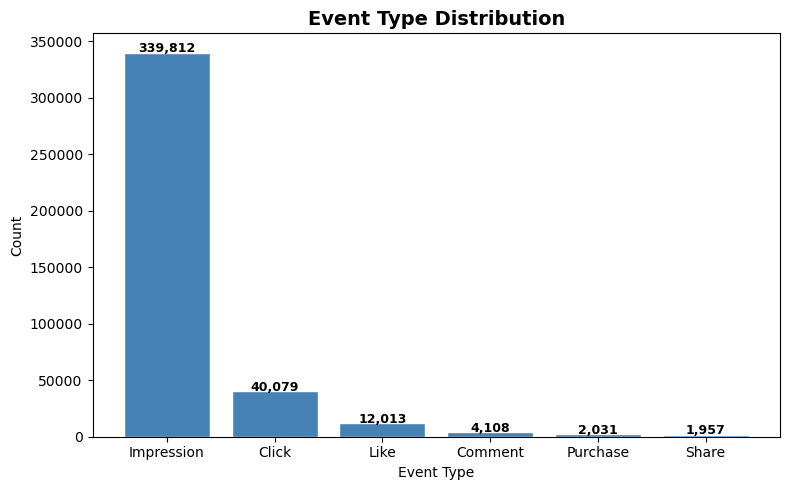

event_type
Impression    339812
Click          40079
Like           12013
Comment         4108
Purchase        2031
Share           1957
Name: count, dtype: int64

Most common event : Impression (339,812)
Least common event: Share (1,957)


In [174]:
plt.figure(figsize=(8, 5))

event_counts = df['event_type'].value_counts()

plt.bar(event_counts.index, event_counts.values,
        color='steelblue', edgecolor='white')

# Add count labels on top of each bar
for i, (val) in enumerate(event_counts.values):
    plt.text(i, val + 500, f'{val:,}',
             ha='center', fontsize=9, fontweight='bold')

plt.title('Event Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(event_counts)
print(f"\nMost common event : {event_counts.index[0]} ({event_counts.values[0]:,})")
print(f"Least common event: {event_counts.index[-1]} ({event_counts.values[-1]:,})")

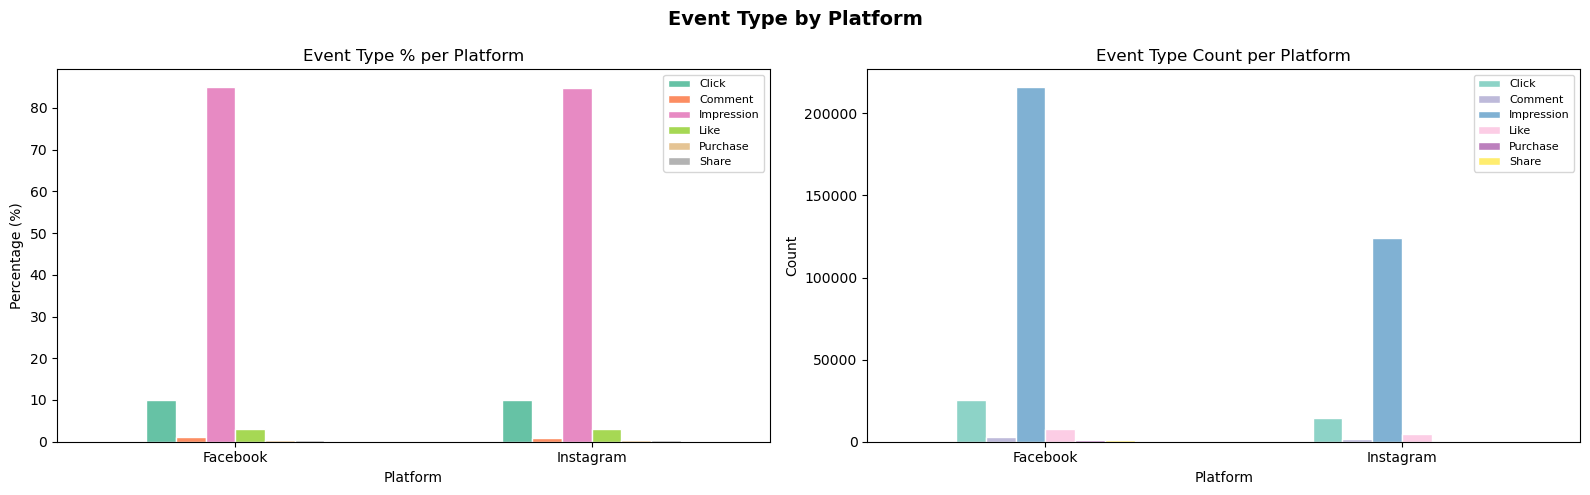

event_type   Click  Comment  Impression  Like  Purchase  Share
ad_platform                                                   
Facebook      9.99     1.04       85.00  2.95      0.52   0.50
Instagram    10.07     1.01       84.88  3.09      0.49   0.47


In [175]:
# Which platform drives which type of events?

# Get platform column name
platform_col = None
if 'ad_platform' in df.columns:
    platform_col = 'ad_platform'
elif 'platform_Facebook' in df.columns:
    # Reconstruct platform from one-hot columns
    df['ad_platform'] = 'Facebook'
    df.loc[df['platform_Instagram'] == 1, 'ad_platform'] = 'Instagram'
    platform_col = 'ad_platform'

ct = pd.crosstab(df[platform_col],
                 df['event_type'],
                 normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Event Type by Platform', fontsize=14, fontweight='bold')

# Stacked bar chart
ct.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Event Type % per Platform')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=8)

# Absolute counts
ct2 = pd.crosstab(df[platform_col], df['event_type'])
ct2.plot(kind='bar', ax=axes[1], colormap='Set3', edgecolor='white')
axes[1].set_title('Event Type Count per Platform')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(ct.round(2))

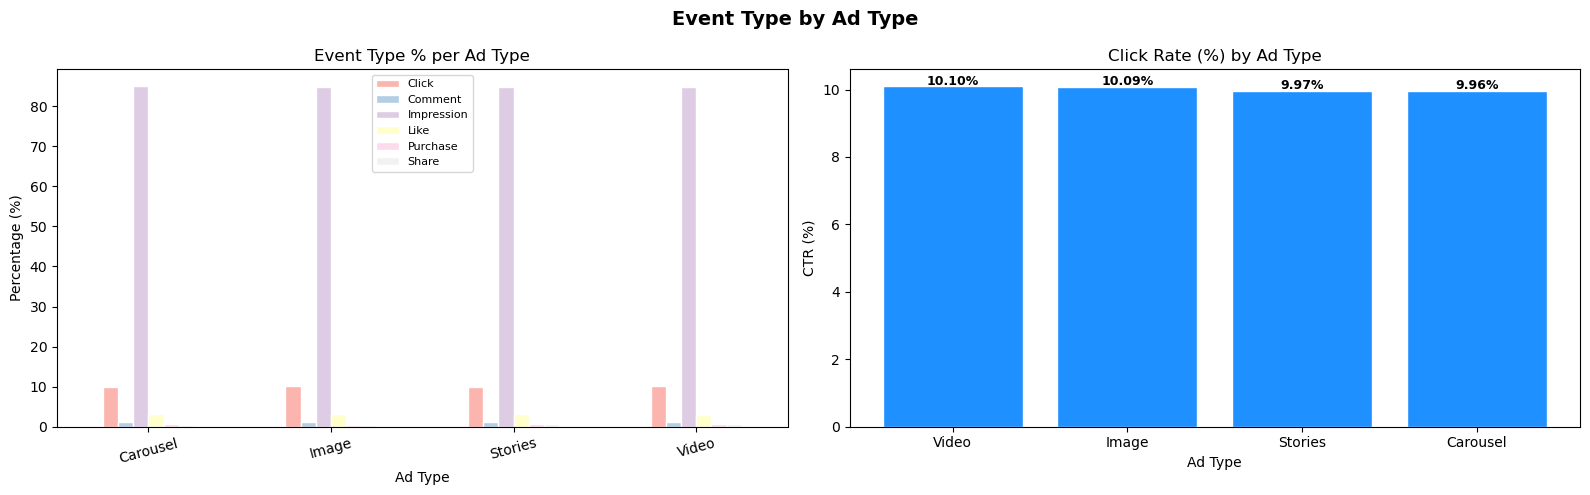


Click Rate by Ad Type:
ad_type
Video       10.096
Image       10.091
Stories      9.967
Carousel     9.963
Name: is_click, dtype: float64


In [190]:
# Reconstruct ad_type from one-hot columns if needed
if 'ad_type' not in df.columns:
    adtype_cols = ['adtype_Carousel', 'adtype_Image', 'adtype_Stories', 'adtype_Video']
    for col in adtype_cols:
        adtype_name = col.replace('adtype_', '')
        df.loc[df[col] == 1, 'ad_type'] = adtype_name

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Event Type by Ad Type', fontsize=14, fontweight='bold')

# Percentage breakdown
ct3 = pd.crosstab(df['ad_type'], df['event_type'], normalize='index') * 100
ct3.plot(kind='bar', ax=axes[0], colormap='Pastel1', edgecolor='white')
axes[0].set_title('Event Type % per Ad Type')
axes[0].set_xlabel('Ad Type')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=8)

# Click rate per ad type
ctr_adtype = df.groupby('ad_type')['is_click'].mean() * 100
ctr_adtype = ctr_adtype.sort_values(ascending=False)
axes[1].bar(ctr_adtype.index, ctr_adtype.values,
            color='dodgerblue', edgecolor='white')
axes[1].set_title('Click Rate (%) by Ad Type')
axes[1].set_xlabel('Ad Type')
axes[1].set_ylabel('CTR (%)')

# Add value labels
for i, val in enumerate(ctr_adtype.values):
    axes[1].text(i, val + 0.05, f'{val:.2f}%',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClick Rate by Ad Type:")
print(ctr_adtype.round(3))

In [183]:
df = pd.read_csv("final_merged_data.csv")

In [184]:
df.columns.tolist()

['event_id',
 'ad_id',
 'user_id',
 'timestamp',
 'day_of_week',
 'time_of_day',
 'event_type',
 'campaign_id',
 'target_gender',
 'target_age_group',
 'target_gender_enc',
 'target_age_group_enc',
 'platform_Facebook',
 'platform_Instagram',
 'adtype_Carousel',
 'adtype_Image',
 'adtype_Stories',
 'adtype_Video',
 'ti_art',
 'ti_fashion',
 'ti_finance',
 'ti_fitness',
 'ti_food',
 'ti_gaming',
 'ti_health',
 'ti_lifestyle',
 'ti_news',
 'ti_photography',
 'ti_sports',
 'ti_technology',
 'ti_travel',
 'name',
 'start_date',
 'end_date',
 'duration_days',
 'total_budget',
 'total_budget_scaled',
 'duration_days_scaled',
 'user_gender',
 'user_age',
 'age_group',
 'country',
 'location',
 'user_gender_enc',
 'age_group_enc',
 'user_age_scaled',
 'ui_art',
 'ui_fashion',
 'ui_finance',
 'ui_fitness',
 'ui_food',
 'ui_gaming',
 'ui_health',
 'ui_lifestyle',
 'ui_news',
 'ui_photography',
 'ui_sports',
 'ui_technology',
 'ui_travel']

In [187]:
# ── Binary event flags ────────────────────────────────────────────────────────
# Convert event_type into simple yes/no columns

# is_click = 1 if the event was a Click, else 0
df['is_click']      = (df['event_type'] == 'Click').astype(int)
df['is_purchase']   = (df['event_type'] == 'Purchase').astype(int)

# is_engagement = 1 if the event was a Like, Share, or Comment
df['is_engagement'] = df['event_type'].isin(['Like', 'Share', 'Comment']).astype(int)
df['is_impression'] = (df['event_type'] == 'Impression').astype(int)




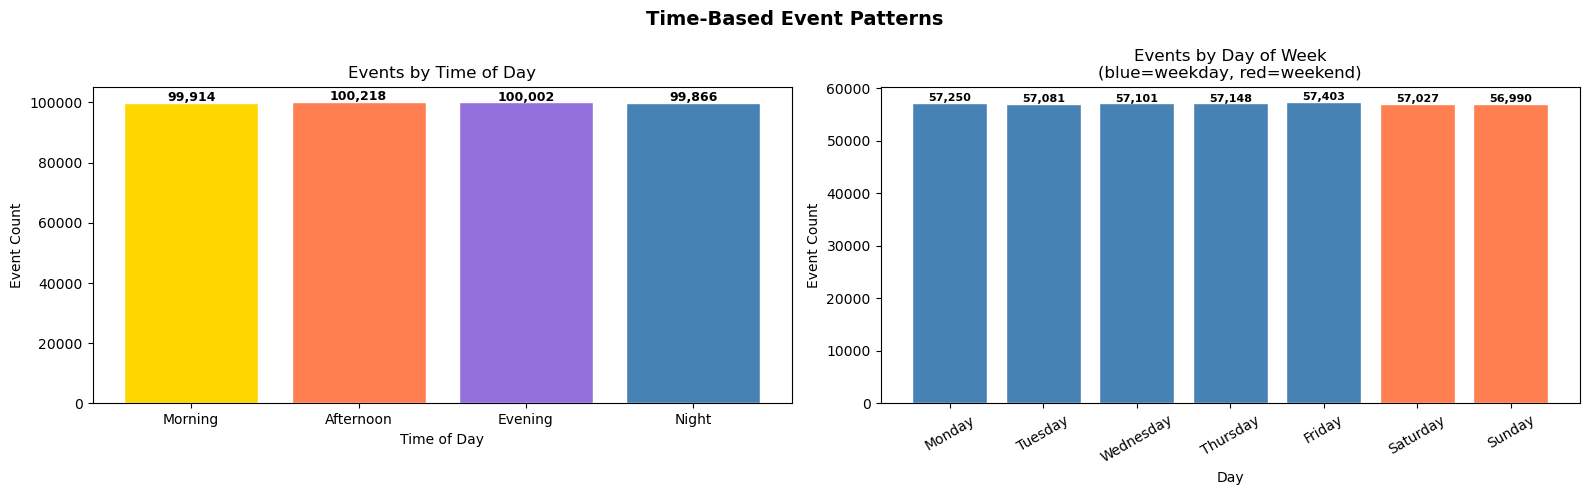

Time of Day counts:
time_of_day
Morning       99914
Afternoon    100218
Evening      100002
Night         99866
Name: count, dtype: int64

Day of Week counts:
day_of_week
Monday       57250
Tuesday      57081
Wednesday    57101
Thursday     57148
Friday       57403
Saturday     57027
Sunday       56990
Name: count, dtype: int64


In [177]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Time-Based Event Patterns', fontsize=14, fontweight='bold')

# Time of day
tod_order = ['Morning', 'Afternoon', 'Evening', 'Night']
tod_counts = df['time_of_day'].value_counts().reindex(tod_order)

axes[0].bar(tod_counts.index, tod_counts.values,
            color=['gold', 'coral', 'mediumpurple', 'steelblue'],
            edgecolor='white')
axes[0].set_title('Events by Time of Day')
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('Event Count')

for i, val in enumerate(tod_counts.values):
    axes[0].text(i, val + 500, f'{val:,}',
                 ha='center', fontsize=9, fontweight='bold')

# Day of week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']
dow_counts = df['day_of_week'].value_counts().reindex(dow_order)

colors = ['steelblue'] * 5 + ['coral'] * 2   # weekdays blue, weekends red
axes[1].bar(dow_counts.index, dow_counts.values,
            color=colors, edgecolor='white')
axes[1].set_title('Events by Day of Week\n(blue=weekday, red=weekend)')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Event Count')
axes[1].tick_params(axis='x', rotation=30)

for i, val in enumerate(dow_counts.values):
    axes[1].text(i, val + 300, f'{val:,}',
                 ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("Time of Day counts:")
print(tod_counts)
print("\nDay of Week counts:")
print(dow_counts)

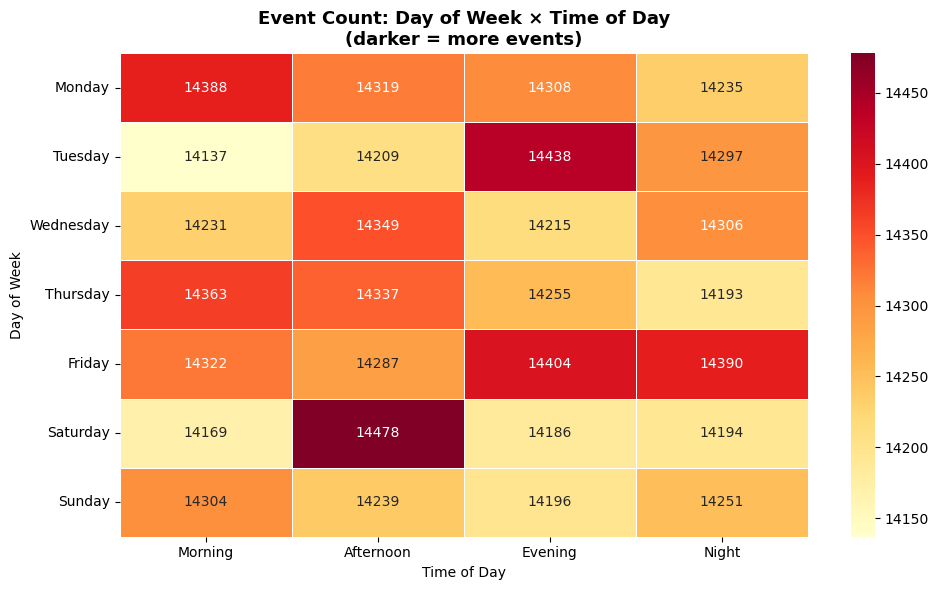

Best time slot for events: Saturday Afternoon
Event count              : 14,478


In [178]:
# This shows WHEN ads are most interacted with
plt.figure(figsize=(10, 6))

dow_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']
tod_order = ['Morning', 'Afternoon', 'Evening', 'Night']

heat = pd.crosstab(df['day_of_week'], df['time_of_day'])
heat = heat.reindex(dow_order)[tod_order]

sns.heatmap(heat,
            annot=True,          # show numbers inside cells
            fmt='d',             # integer format
            cmap='YlOrRd',       # yellow → orange → red
            linewidths=0.5,
            annot_kws={'size': 10})

plt.title('Event Count: Day of Week × Time of Day\n(darker = more events)',
          fontsize=13, fontweight='bold')
plt.xlabel('Time of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

# Find the best time slot
best_slot = heat.stack().idxmax()
print(f"Best time slot for events: {best_slot[0]} {best_slot[1]}")
print(f"Event count              : {heat.stack().max():,}")

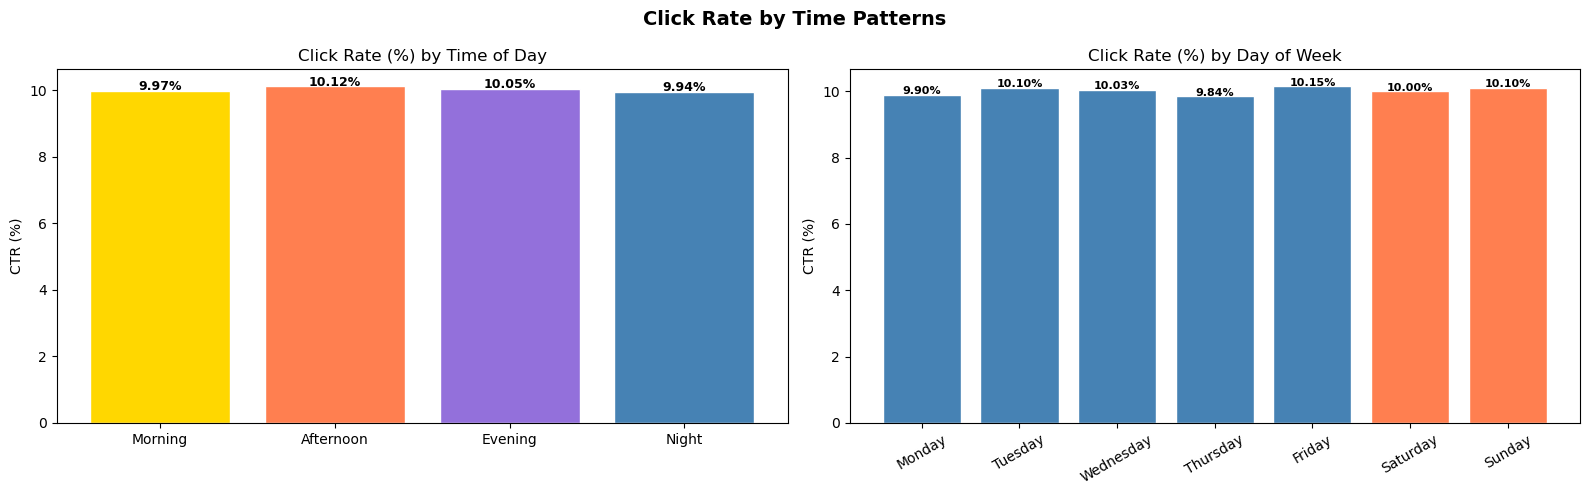

CTR by Time of Day:
time_of_day
Morning       9.972
Afternoon    10.118
Evening      10.048
Night         9.941
Name: is_click, dtype: float64

CTR by Day of Week:
day_of_week
Monday        9.900
Tuesday      10.105
Wednesday    10.035
Thursday      9.845
Friday       10.153
Saturday     10.002
Sunday       10.098
Name: is_click, dtype: float64


In [188]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Click Rate by Time Patterns', fontsize=14, fontweight='bold')

# CTR by time of day
ctr_tod = df.groupby('time_of_day')['is_click'].mean() * 100
ctr_tod = ctr_tod.reindex(tod_order)

axes[0].bar(ctr_tod.index, ctr_tod.values,
            color=['gold', 'coral', 'mediumpurple', 'steelblue'],
            edgecolor='white')
axes[0].set_title('Click Rate (%) by Time of Day')
axes[0].set_ylabel('CTR (%)')

for i, val in enumerate(ctr_tod.values):
    axes[0].text(i, val + 0.02, f'{val:.2f}%',
                 ha='center', fontsize=9, fontweight='bold')

# CTR by day of week
ctr_dow = df.groupby('day_of_week')['is_click'].mean() * 100
ctr_dow = ctr_dow.reindex(dow_order)

colors = ['steelblue'] * 5 + ['coral'] * 2
axes[1].bar(ctr_dow.index, ctr_dow.values,
            color=colors, edgecolor='white')
axes[1].set_title('Click Rate (%) by Day of Week')
axes[1].set_ylabel('CTR (%)')
axes[1].tick_params(axis='x', rotation=30)

for i, val in enumerate(ctr_dow.values):
    axes[1].text(i, val + 0.02, f'{val:.2f}%',
                 ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("CTR by Time of Day:")
print(ctr_tod.round(3))
print("\nCTR by Day of Week:")
print(ctr_dow.round(3))

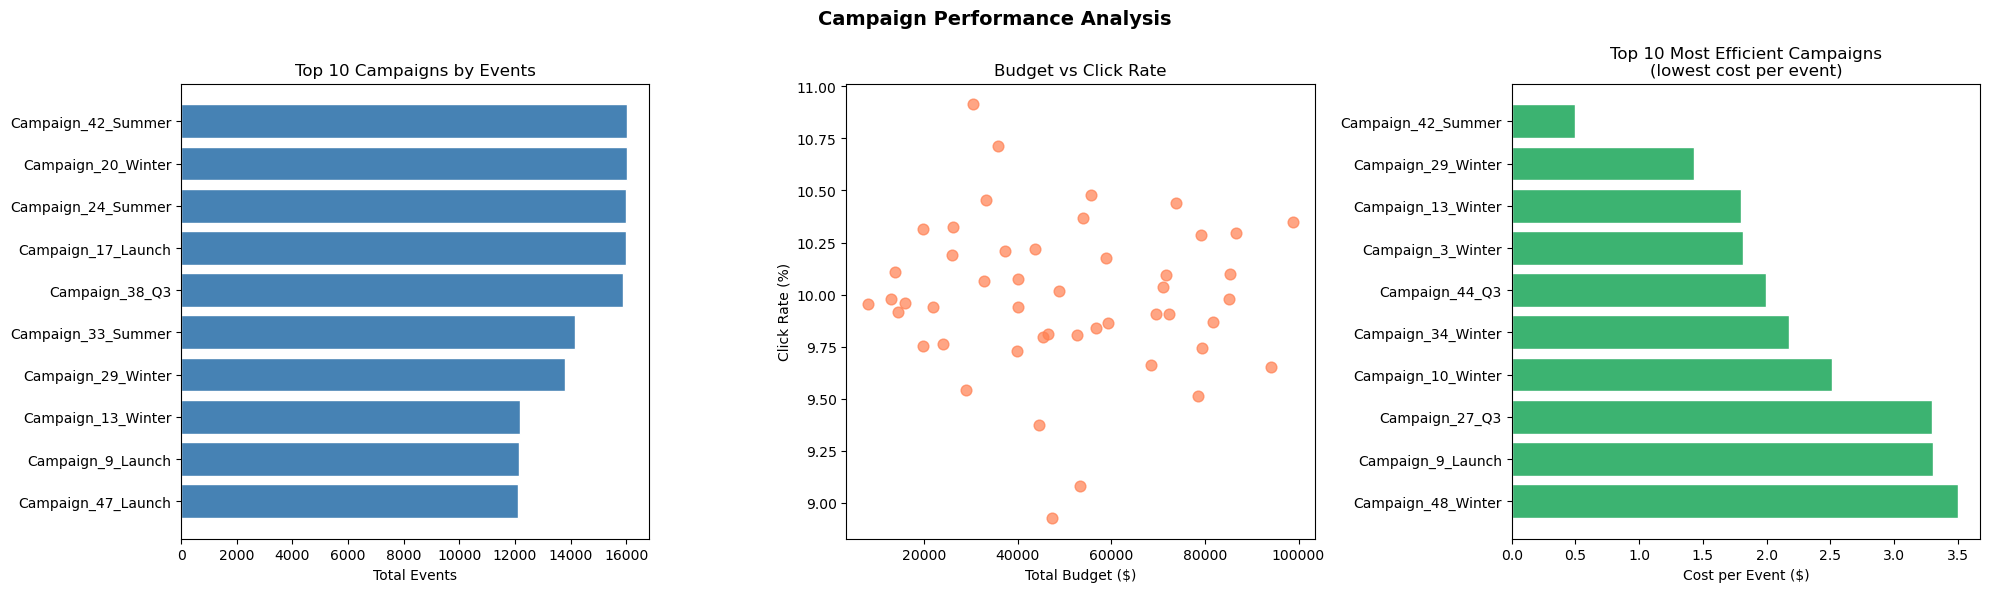

Campaign performance summary:
                  name  total_events  click_rate  purchase_rate  \
0   Campaign_10_Winter          7823      0.0975         0.0065   
1       Campaign_11_Q3          6007      0.1029         0.0062   
2       Campaign_12_Q3          4041      0.1091         0.0040   
3   Campaign_13_Winter         12173      0.0994         0.0053   
4   Campaign_14_Summer          3885      0.0973         0.0057   
5   Campaign_15_Launch          9912      0.1010         0.0042   
6   Campaign_17_Launch         15984      0.1030         0.0057   
7       Campaign_18_Q3          5939      0.1002         0.0035   
8   Campaign_19_Winter          4008      0.1045         0.0035   
9    Campaign_1_Launch          5919      0.0977         0.0056   
10  Campaign_20_Winter         16025      0.1035         0.0046   
11  Campaign_21_Winter          7942      0.1021         0.0062   
12      Campaign_22_Q3         10120      0.1071         0.0050   
13  Campaign_23_Winter          

In [189]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Campaign Performance Analysis', fontsize=14, fontweight='bold')

# Aggregate per campaign
camp_perf = df.groupby('name').agg(
    total_events  = ('event_id',   'count'),
    total_clicks  = ('is_click',   'sum'),
    total_purchase = ('is_purchase','sum'),
    total_budget  = ('total_budget','first')
).reset_index()

camp_perf['click_rate']    = camp_perf['total_clicks']   / camp_perf['total_events']
camp_perf['purchase_rate'] = camp_perf['total_purchase'] / camp_perf['total_events']
camp_perf['cost_per_event'] = camp_perf['total_budget']  / camp_perf['total_events']

# Chart 1: Top 10 campaigns by events
top10 = camp_perf.nlargest(10, 'total_events')
axes[0].barh(top10['name'], top10['total_events'],
             color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Campaigns by Events')
axes[0].set_xlabel('Total Events')
axes[0].invert_yaxis()

# Chart 2: Budget vs Click Rate
axes[1].scatter(camp_perf['total_budget'],
                camp_perf['click_rate'] * 100,
                color='coral', alpha=0.7, s=60)
axes[1].set_title('Budget vs Click Rate')
axes[1].set_xlabel('Total Budget ($)')
axes[1].set_ylabel('Click Rate (%)')

# Chart 3: Cost per event comparison
top10_eff = camp_perf.nsmallest(10, 'cost_per_event')
axes[2].barh(top10_eff['name'], top10_eff['cost_per_event'],
             color='mediumseagreen', edgecolor='white')
axes[2].set_title('Top 10 Most Efficient Campaigns\n(lowest cost per event)')
axes[2].set_xlabel('Cost per Event ($)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print("Campaign performance summary:")
print(camp_perf[['name', 'total_events', 'click_rate',
                  'purchase_rate', 'cost_per_event']].round(4))

In [192]:
# Recreate audience match features on the current df
# (in case they are missing from the saved CSV)

# Gender match — unknown users get 0
df['gender_match'] = (
    (df['user_gender'] != 'Unknown') &
    (
        (df['target_gender'] == 'All') |
        (df['user_gender'] == df['target_gender'])
    )
).astype(int)

# Age match
df['age_match'] = (
    (df['age_group'] != 'Unknown') &
    (df['age_group'] == df['target_age_group'])
).astype(int)

# Interest overlap — rebuild from binary columns
ui_cols = [c for c in df.columns if c.startswith('ui_')]
ti_cols = [c for c in df.columns if c.startswith('ti_')]

def rebuild_interests(row, cols, prefix):
    active = [col.replace(prefix, '') for col in cols if row[col] == 1]
    return ', '.join(active) if active else 'unknown'

def count_overlap(user_interests, target_interests):
    user_set   = set(str(user_interests).split(', '))
    target_set = set(str(target_interests).split(', '))
    return len(user_set & target_set)

df['interests_rebuilt'] = df.apply(
    lambda row: rebuild_interests(row, ui_cols, 'ui_'), axis=1
)
df['target_interests_rebuilt'] = df.apply(
    lambda row: rebuild_interests(row, ti_cols, 'ti_'), axis=1
)

df['interest_overlap'] = df.apply(
    lambda row: count_overlap(
        row['interests_rebuilt'],
        row['target_interests_rebuilt']
    ), axis=1
)

# Well targeted flag
df['is_well_targeted'] = (
    (df['gender_match']     == 1) &
    (df['age_match']        == 1) &
    (df['interest_overlap'] >  0)
).astype(int)

# Drop temporary rebuilt columns
df = df.drop(columns=['interests_rebuilt', 'target_interests_rebuilt'])

print("✅ Audience match features recreated!")
print(f"  gender_match     : {df['gender_match'].sum():,} rows with value 1")
print(f"  age_match        : {df['age_match'].sum():,} rows with value 1")
print(f"  is_well_targeted : {df['is_well_targeted'].sum():,} rows with value 1")

✅ Audience match features recreated!
  gender_match     : 22,619 rows with value 1
  age_match        : 8,189 rows with value 1
  is_well_targeted : 1,057 rows with value 1


In [193]:
# Recreate known users filter
known = df[df['user_gender'] != 'Unknown'].copy()

print(f"Known users events : {len(known):,}")
print(f"is_well_targeted in known : {'is_well_targeted' in known.columns}")
print(f"\nValue counts:")
print(known['is_well_targeted'].value_counts())

Known users events : 36,186
is_well_targeted in known : True

Value counts:
is_well_targeted
0    35129
1     1057
Name: count, dtype: int64


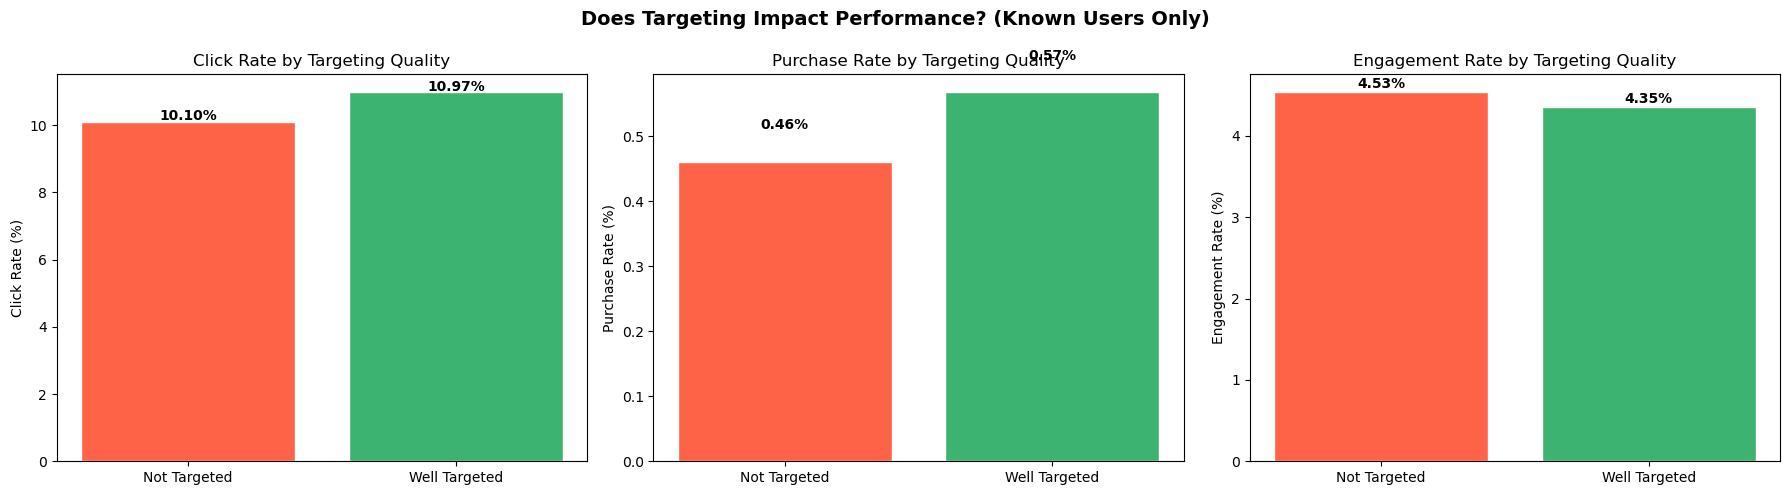


Performance: Well-targeted vs Not (Known users only)
                  is_click  is_purchase  is_engagement
is_well_targeted                                      
0                    10.10         0.46           4.53
1                    10.97         0.57           4.35


In [194]:
# Now rerun Chart 8 — it should work
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Does Targeting Impact Performance? (Known Users Only)',
             fontsize=14, fontweight='bold')

metrics = ['is_click', 'is_purchase', 'is_engagement']
titles  = ['Click Rate', 'Purchase Rate', 'Engagement Rate']

for i, (metric, title) in enumerate(zip(metrics, titles)):

    rates = known.groupby('is_well_targeted')[metric].mean() * 100

    bars = axes[i].bar(
        ['Not Targeted', 'Well Targeted'],
        rates.values,
        color=['tomato', 'mediumseagreen'],
        edgecolor='white'
    )

    axes[i].set_title(f'{title} by Targeting Quality')
    axes[i].set_ylabel(f'{title} (%)')

    # Value labels on bars
    for bar, val in zip(bars, rates.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.05,
            f'{val:.2f}%',
            ha='center', fontsize=10, fontweight='bold'
        )

plt.tight_layout()
plt.show()

print("\nPerformance: Well-targeted vs Not (Known users only)")
print(known.groupby('is_well_targeted')[metrics].mean().round(4) * 100)

In [195]:
df.to_csv('merged_ad_data.csv', index=False)
print("✅ CSV updated with all audience match features!")
print(f"   Shape : {df.shape}")

✅ CSV updated with all audience match features!
   Shape : (400000, 68)


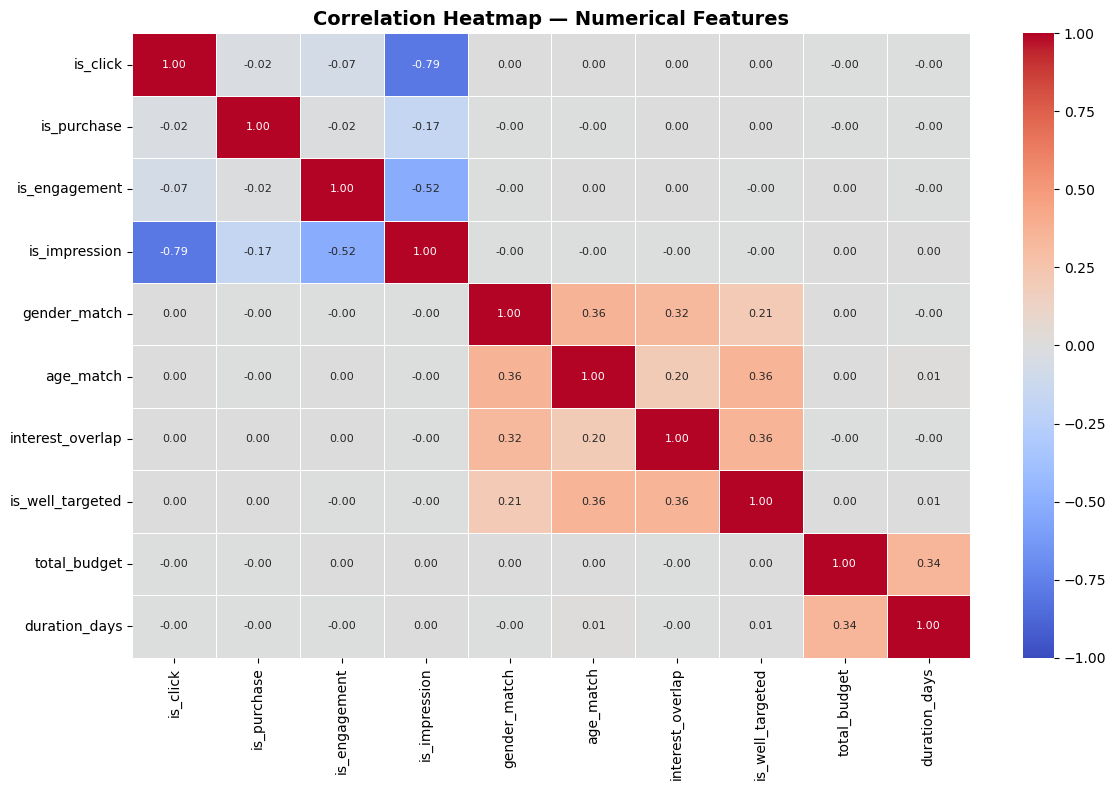

=== STRONGEST CORRELATIONS WITH is_click ===
is_impression      -0.7929
is_engagement      -0.0726
is_purchase        -0.0238
interest_overlap    0.0025
gender_match        0.0018
is_well_targeted    0.0016
age_match           0.0013
total_budget       -0.0001
duration_days      -0.0001
Name: is_click, dtype: float64


In [196]:
# Shows which numerical features are related to each other

num_cols = [
    'is_click', 'is_purchase', 'is_engagement', 'is_impression',
    'gender_match', 'age_match', 'interest_overlap', 'is_well_targeted',
    'total_budget', 'duration_days', 'is_weekend'
]

# Only keep columns that exist
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',   # blue=negative, red=positive correlation
            linewidths=0.5,
            annot_kws={'size': 8},
            vmin=-1, vmax=1)   # fix scale from -1 to 1

plt.title('Correlation Heatmap — Numerical Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print strongest correlations
print("=== STRONGEST CORRELATIONS WITH is_click ===")
click_corr = corr['is_click'].drop('is_click').sort_values(
    key=abs, ascending=False
)
print(click_corr.round(4))

In [200]:
# Check current dtype
print("timestamp dtype BEFORE:", df['timestamp'].dtype)
print("Sample values          :", df['timestamp'].head(3).tolist())

# Convert to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Verify
print("\ntimestamp dtype AFTER :", df['timestamp'].dtype)

timestamp dtype BEFORE: object
Sample values          : ['2025-07-26 00:19:56', '2025-06-15 08:28:07', '2025-06-27 00:40:02']

timestamp dtype AFTER : datetime64[ns]


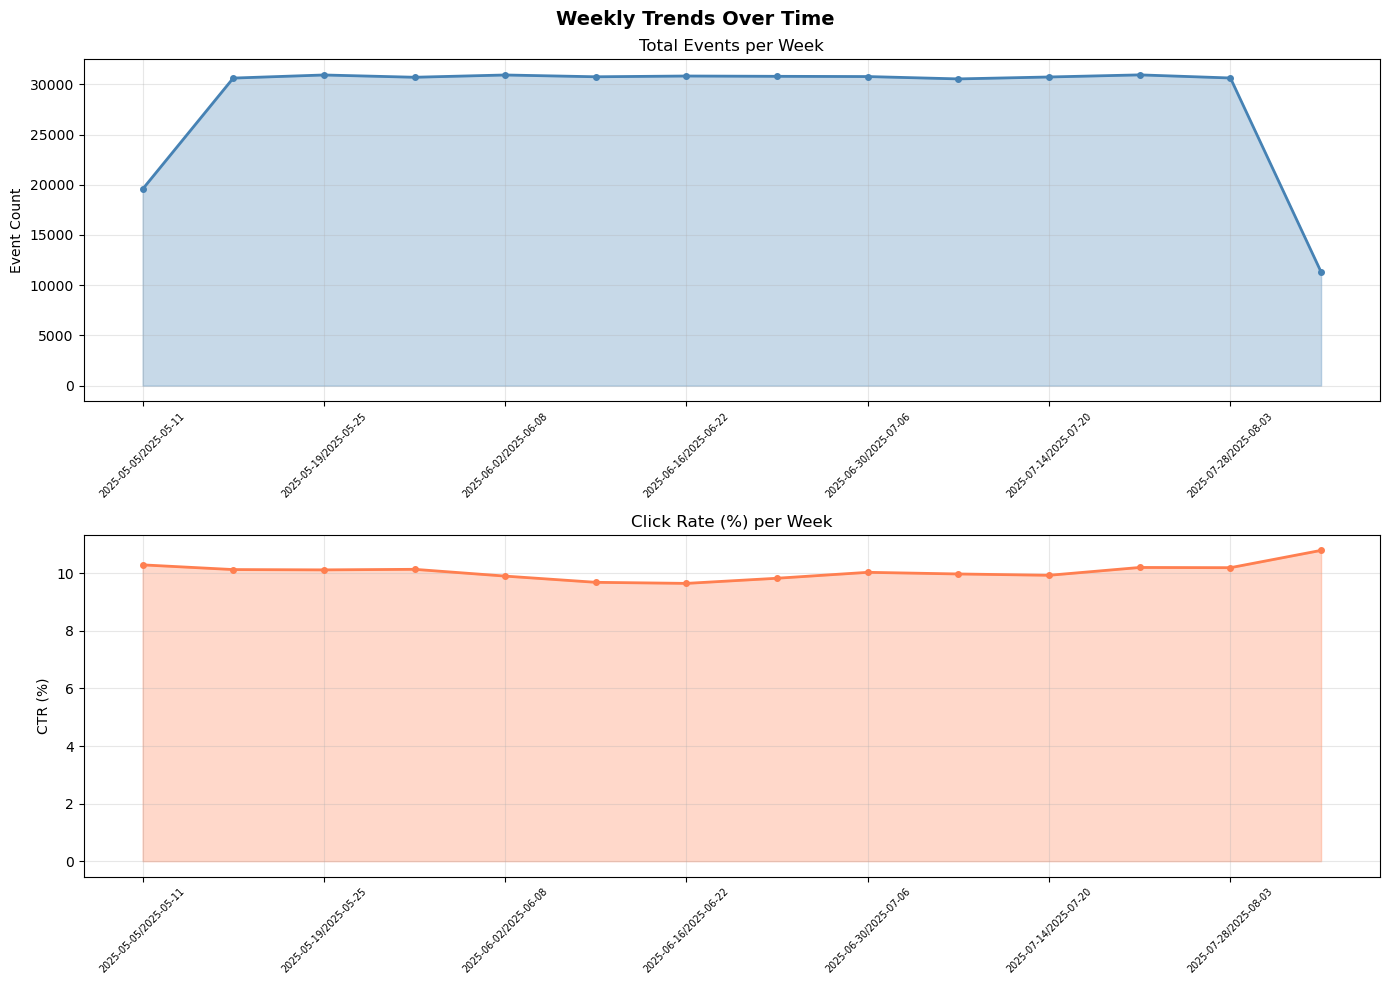

Date range     : 2025-05-07 to 2025-08-06
Total weeks    : 14
Avg events/week: 28,571


In [201]:
# Now this will work
df['week'] = df['timestamp'].dt.to_period('W').astype(str)

weekly = df.groupby('week').agg(
    total_events   = ('event_id',    'count'),
    total_clicks   = ('is_click',    'sum'),
    total_purchase = ('is_purchase', 'sum')
).reset_index()

weekly['click_rate']    = weekly['total_clicks']   / weekly['total_events']
weekly['purchase_rate'] = weekly['total_purchase'] / weekly['total_events']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Weekly Trends Over Time', fontsize=14, fontweight='bold')

x = range(len(weekly))

# Total events per week
axes[0].plot(x, weekly['total_events'],
             color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(x, weekly['total_events'],
                     alpha=0.3, color='steelblue')
axes[0].set_title('Total Events per Week')
axes[0].set_ylabel('Event Count')
axes[0].set_xticks(x[::2])
axes[0].set_xticklabels(weekly['week'].iloc[::2], rotation=45, fontsize=7)
axes[0].grid(True, alpha=0.3)

# Click rate per week
axes[1].plot(x, weekly['click_rate'] * 100,
             color='coral', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(x, weekly['click_rate'] * 100,
                     alpha=0.3, color='coral')
axes[1].set_title('Click Rate (%) per Week')
axes[1].set_ylabel('CTR (%)')
axes[1].set_xticks(x[::2])
axes[1].set_xticklabels(weekly['week'].iloc[::2], rotation=45, fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Date range     : {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"Total weeks    : {len(weekly)}")
print(f"Avg events/week: {weekly['total_events'].mean():,.0f}")

In [202]:
# ── Always run these after loading CSV ───────────────────────────────────────
df = pd.read_csv('merged_ad_data.csv')

# Fix datetime columns — they always load as strings from CSV
df['timestamp']  = pd.to_datetime(df['timestamp'])
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date']   = pd.to_datetime(df['end_date'])

print("✅ CSV loaded with correct dtypes")
print(f"   timestamp dtype  : {df['timestamp'].dtype}")
print(f"   start_date dtype : {df['start_date'].dtype}")
print(f"   Shape            : {df.shape}")

✅ CSV loaded with correct dtypes
   timestamp dtype  : datetime64[ns]
   start_date dtype : datetime64[ns]
   Shape            : (400000, 68)


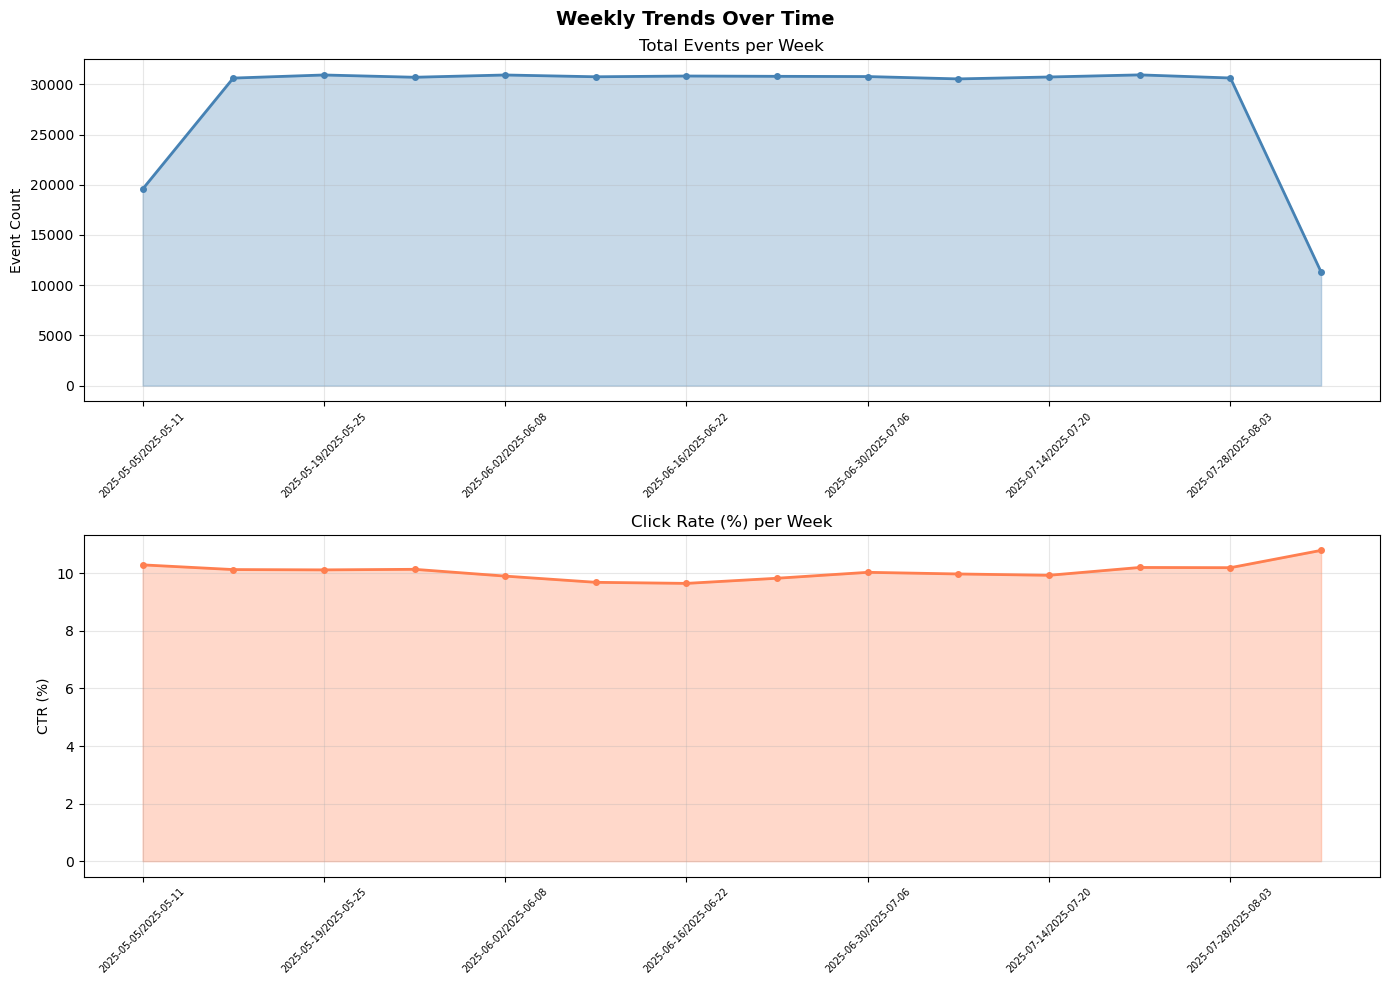

Date range     : 2025-05-07 to 2025-08-06
Total weeks    : 14
Avg events/week: 28,571


In [203]:
# Are events increasing or decreasing over time?

df['week'] = df['timestamp'].dt.to_period('W').astype(str)

weekly = df.groupby('week').agg(
    total_events = ('event_id',   'count'),
    total_clicks = ('is_click',   'sum'),
    total_purchase = ('is_purchase', 'sum')
).reset_index()

weekly['click_rate']    = weekly['total_clicks']   / weekly['total_events']
weekly['purchase_rate'] = weekly['total_purchase'] / weekly['total_events']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Weekly Trends Over Time', fontsize=14, fontweight='bold')

x = range(len(weekly))

# Total events per week
axes[0].plot(x, weekly['total_events'],
             color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(x, weekly['total_events'],
                     alpha=0.3, color='steelblue')
axes[0].set_title('Total Events per Week')
axes[0].set_ylabel('Event Count')
axes[0].set_xticks(x[::2])
axes[0].set_xticklabels(weekly['week'].iloc[::2], rotation=45, fontsize=7)
axes[0].grid(True, alpha=0.3)

# Click rate per week
axes[1].plot(x, weekly['click_rate'] * 100,
             color='coral', linewidth=2, marker='o', markersize=4)
axes[1].fill_between(x, weekly['click_rate'] * 100,
                     alpha=0.3, color='coral')
axes[1].set_title('Click Rate (%) per Week')
axes[1].set_ylabel('CTR (%)')
axes[1].set_xticks(x[::2])
axes[1].set_xticklabels(weekly['week'].iloc[::2], rotation=45, fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Date range     : {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"Total weeks    : {len(weekly)}")
print(f"Avg events/week: {weekly['total_events'].mean():,.0f}")

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


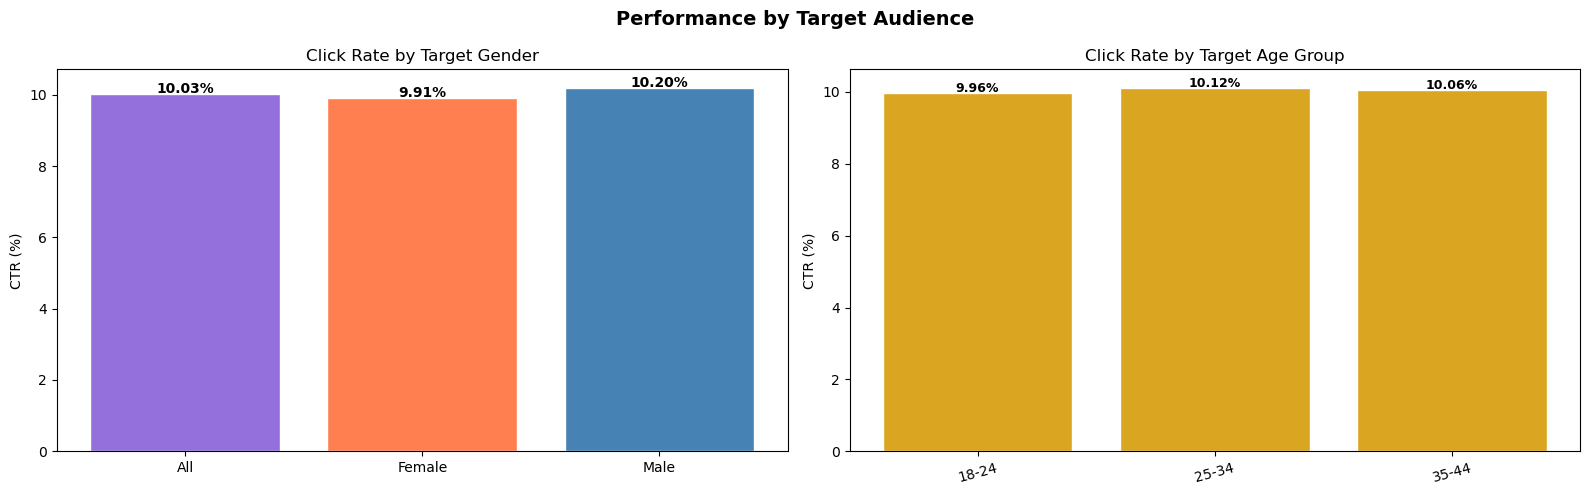

CTR by Target Gender:
target_gender
All       10.026
Female     9.913
Male      10.202
Name: is_click, dtype: float64

CTR by Target Age Group:
target_age_group
16-17       NaN
18-24     9.965
25-34    10.120
35-44    10.056
45-54       NaN
55-65       NaN
Name: is_click, dtype: float64


In [199]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Performance by Target Audience', fontsize=14, fontweight='bold')

# CTR by target gender
ctr_gender = df.groupby('target_gender')['is_click'].mean() * 100
axes[0].bar(ctr_gender.index, ctr_gender.values,
            color=['mediumpurple', 'coral', 'steelblue'],
            edgecolor='white')
axes[0].set_title('Click Rate by Target Gender')
axes[0].set_ylabel('CTR (%)')

for i, val in enumerate(ctr_gender.values):
    axes[0].text(i, val + 0.02, f'{val:.2f}%',
                 ha='center', fontsize=10, fontweight='bold')

# CTR by target age group
age_order = ['16-17', '18-24', '25-34', '35-44', '45-54', '55-65']
ctr_age   = df.groupby('target_age_group')['is_click'].mean() * 100
ctr_age   = ctr_age.reindex(age_order)

axes[1].bar(ctr_age.index, ctr_age.values,
            color='goldenrod', edgecolor='white')
axes[1].set_title('Click Rate by Target Age Group')
axes[1].set_ylabel('CTR (%)')
axes[1].tick_params(axis='x', rotation=15)

for i, val in enumerate(ctr_age.values):
    axes[1].text(i, val + 0.02, f'{val:.2f}%',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("CTR by Target Gender:")
print(ctr_gender.round(3))
print("\nCTR by Target Age Group:")
print(ctr_age.round(3))

In [204]:
# Drop helper columns before saving
cols_to_drop = ['week']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

df.to_csv('merged_ad_data.csv', index=False)
print("✅ CSV saved after Phase 7!")
print(f"   Final shape : {df.shape}")

print("""
=== PHASE 7 COMPLETE ===

Charts created:
  1.  Event type distribution
  2.  Event type by platform
  3.  Event type by ad type + CTR by ad type
  4.  Events by time of day and day of week
  5.  Heatmap: day × time of day
  6.  CTR by time of day and day of week
  7.  Campaign performance (top 10, budget vs CTR, efficiency)
  8.  Targeting impact on performance
  9.  Correlation heatmap
  10. Weekly event trend
  11. CTR by target gender and age group

Next → Phase 8: Build the Pipeline Class!
""")

✅ CSV saved after Phase 7!
   Final shape : (400000, 68)

=== PHASE 7 COMPLETE ===

Charts created:
  1.  Event type distribution
  2.  Event type by platform
  3.  Event type by ad type + CTR by ad type
  4.  Events by time of day and day of week
  5.  Heatmap: day × time of day
  6.  CTR by time of day and day of week
  7.  Campaign performance (top 10, budget vs CTR, efficiency)
  8.  Targeting impact on performance
  9.  Correlation heatmap
  10. Weekly event trend
  11. CTR by target gender and age group

Next → Phase 8: Build the Pipeline Class!



---
# ⚫ PHASE 8 — Build a Reusable Pipeline Class

## Step 20: Refactor Into a Class

**Goal:** Wrap all your work into a clean, reusable class so the entire pipeline runs in one call.

**Class structure to build:**

```python
class AdAnalysisPipeline:
    
    def __init__(self, users_path, ads_path, campaigns_path, events_path):
        """Store file paths. Initialize empty dataframe attributes."""
    
    def load_data(self):
        """Load all 4 CSVs into self.users, self.ads, self.campaigns, self.events"""
    
    def fix_dtypes(self):
        """Fix data types: user_id, dates, timestamps"""
    
    def handle_missing(self):
        """Fill or drop missing values in each table"""
    
    def remove_duplicates(self):
        """Drop duplicate rows from each table"""
    
    def standardize_text(self):
        """Strip whitespace, lowercase, fix inconsistencies"""
    
    def merge_data(self):
        """Execute 3-step merge → store in self.df"""
    
    def engineer_features(self):
        """Add binary flags, datetime features, audience match columns"""
    
    def encode_and_scale(self):
        """Label encode, one-hot encode, multi-hot encode, scale numericals"""
    
    def get_ad_level_metrics(self):
        """Aggregate to ad-level → return ad performance dataframe"""
    
    def plot_eda(self):
        """Generate all key EDA charts"""
    
    def run(self):
        """Call all steps in order → return final cleaned merged df"""
        self.load_data()
        self.fix_dtypes()
        self.handle_missing()
        self.remove_duplicates()
        self.standardize_text()
        self.merge_data()
        self.engineer_features()
        self.encode_and_scale()
        return self.df
```

**Benefits:**
- Reusable on new data
- Easy to test individual steps
- Foundation for a proper ML pipeline

In [ ]:
# YOUR CODE HERE
# Build the AdAnalysisPipeline class
# Then test it:
# pipeline = AdAnalysisPipeline(...)
# df_final = pipeline.run()

In [205]:
# Before writing the class, understand what it will do:

print"""
AdAnalysisPipeline
│
├── __init__()               → store file paths
│
├── LOADING
│   └── load_data()          → read all 4 CSV files
│
├── CLEANING
│   ├── fix_dtypes()         → fix user_id, dates, timestamps
│   ├── fix_placeholder_ids()→ replace -2147483648 with real IDs
│   ├── handle_missing()     → fill NaN values
│   ├── remove_duplicates()  → drop duplicate rows
│   └── standardize_text()   → strip, title case, fix interests
│
├── MERGING
│   ├── fix_join_keys()      → make dtypes match before merge
│   └── merge_data()         → combine all 4 tables
│
├── FEATURE ENGINEERING
│   ├── create_event_features()   → is_click, is_purchase etc.
│   ├── create_time_features()    → hour, month, is_weekend
│   ├── create_audience_features()→ gender_match, age_match etc.
│   └── create_ad_metrics()       → CTR, CVR per ad
│
├── ENCODING
│   └── encode_and_scale()   → label encode, one-hot, scale
│
└── run()                    → calls all steps in order
""")


AdAnalysisPipeline
│
├── __init__()               → store file paths
│
├── LOADING
│   └── load_data()          → read all 4 CSV files
│
├── CLEANING
│   ├── fix_dtypes()         → fix user_id, dates, timestamps
│   ├── fix_placeholder_ids()→ replace -2147483648 with real IDs
│   ├── handle_missing()     → fill NaN values
│   ├── remove_duplicates()  → drop duplicate rows
│   └── standardize_text()   → strip, title case, fix interests
│
├── MERGING
│   ├── fix_join_keys()      → make dtypes match before merge
│   └── merge_data()         → combine all 4 tables
│
├── FEATURE ENGINEERING
│   ├── create_event_features()   → is_click, is_purchase etc.
│   ├── create_time_features()    → hour, month, is_weekend
│   ├── create_audience_features()→ gender_match, age_match etc.
│   └── create_ad_metrics()       → CTR, CVR per ad
│
├── ENCODING
│   └── encode_and_scale()   → label encode, one-hot, scale
│
└── run()                    → calls all steps in order



In [213]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, MultiLabelBinarizer
import warnings
warnings.filterwarnings('ignore')

class AdAnalysisPipeline:
    """
    Complete end-to-end pipeline for Ad Performance Analysis.
    Covers: loading, cleaning, merging, feature engineering, encoding.

    Usage:
        pipeline = AdAnalysisPipeline('users.csv', 'ads.csv',
                                       'campaigns.csv', 'ad_events.csv')
        df = pipeline.run()
    """

    def __init__(self, users_path, ads_path, campaigns_path, events_path):
        # Store file paths
        self.users_path     = users_path
        self.ads_path       = ads_path
        self.campaigns_path = campaigns_path
        self.events_path    = events_path

        # These will hold dataframes after each step
        self.users      = None
        self.ads        = None
        self.campaigns  = None
        self.events     = None
        self.df         = None   # final merged dataset
        self.ad_metrics = None   # ad level summary

        # Sklearn objects
        self.scaler = StandardScaler()
        self.le     = LabelEncoder()

        print("✅ Pipeline created!")
        print(f"   users     : {users_path}")
        print(f"   ads       : {ads_path}")
        print(f"   campaigns : {campaigns_path}")
        print(f"   events    : {events_path}")

    # =========================================================================
    # STEP 1 — LOAD DATA
    # =========================================================================
    def load_data(self):
        """Load all 4 CSV files into dataframes."""
        print("\n📂 Loading data...")

        self.users     = pd.read_csv(self.users_path)
        self.ads       = pd.read_csv(self.ads_path)
        self.campaigns = pd.read_csv(self.campaigns_path)
        self.events    = pd.read_csv(self.events_path)

        print(f"   users     : {self.users.shape}")
        print(f"   ads       : {self.ads.shape}")
        print(f"   campaigns : {self.campaigns.shape}")
        print(f"   events    : {self.events.shape}")

    # =========================================================================
    # STEP 2 — FIX DATA TYPES
    # =========================================================================
    def fix_dtypes(self):
        """Fix data types for all tables."""
        print("\n🔧 Fixing data types...")

        # users: user_id float → int → string
        self.users['user_id'] = pd.to_numeric(
            self.users['user_id'], errors='coerce'
        )
        self.users = self.users.dropna(subset=['user_id'])
        self.users['user_id'] = self.users['user_id'].astype(int).astype(str)

        # campaigns: date strings → datetime
        self.campaigns['start_date'] = pd.to_datetime(
            self.campaigns['start_date'], format='%d-%m-%Y'
        )
        self.campaigns['end_date'] = pd.to_datetime(
            self.campaigns['end_date'], format='%d-%m-%Y'
        )
        self.campaigns['duration_days'] = (
            self.campaigns['duration_days'].astype(int)
        )

        # events: timestamp string → datetime
        self.events['timestamp'] = pd.to_datetime(self.events['timestamp'])

        # ads: id columns → int
        self.ads['ad_id']       = self.ads['ad_id'].astype(int)
        self.ads['campaign_id'] = self.ads['campaign_id'].astype(int)

        print("   ✅ user_id   : float → string")
        print("   ✅ dates     : string → datetime")
        print("   ✅ timestamp : string → datetime")
        print("   ✅ ad_id     : → int")

    # =========================================================================
    # STEP 3 — FIX PLACEHOLDER IDs (-2147483648)
    # =========================================================================
    def fix_placeholder_ids(self):
        """
        Replace -2147483648 (32-bit integer NULL placeholder)
        with unique IDs. No rows are dropped.
        """
        print("\n🔧 Fixing placeholder user IDs...")

        BAD_ID    = '-2147483648'
        bad_mask  = self.users['user_id'] == BAD_ID
        bad_count = bad_mask.sum()

        if bad_count == 0:
            print("   ✅ No placeholder IDs found")
            return

        good_users        = self.users[~bad_mask].copy()
        placeholder_users = (
            self.users[bad_mask].copy().reset_index(drop=True)
        )
        placeholder_users['user_id'] = [
            'unknown_user_' + str(i)
            for i in range(len(placeholder_users))
        ]

        self.users = pd.concat(
            [good_users, placeholder_users], ignore_index=True
        )

        print(f"   ✅ Replaced {bad_count} placeholder IDs")
        print(f"   No rows dropped — all users preserved")

    # =========================================================================
    # STEP 4 — HANDLE MISSING VALUES
    # =========================================================================
    def handle_missing(self):
        """Fill missing values in all tables."""
        print("\n🔧 Handling missing values...")

        for name, df in [('users',     self.users),
                          ('ads',       self.ads),
                          ('campaigns', self.campaigns),
                          ('events',    self.events)]:

            null_count = df.isnull().sum().sum()

            if null_count == 0:
                print(f"   ✅ {name:10} — no nulls found")
                continue

            for col in df.select_dtypes(include='object').columns:
                if df[col].isnull().sum() > 0:
                    df[col] = df[col].fillna(df[col].mode()[0])

            for col in df.select_dtypes(include='number').columns:
                if df[col].isnull().sum() > 0:
                    df[col] = df[col].fillna(df[col].median())

            print(f"   ✅ {name:10} — fixed {null_count} nulls")

    # =========================================================================
    # STEP 5 — REMOVE DUPLICATES
    # =========================================================================
    def remove_duplicates(self):
        """Remove duplicate rows from all tables."""
        print("\n🔧 Removing duplicates...")

        before = {
            'users'    : len(self.users),
            'ads'      : len(self.ads),
            'campaigns': len(self.campaigns),
            'events'   : len(self.events)
        }

        self.users     = self.users.drop_duplicates(
            subset=['user_id'], keep='first'
        )
        self.ads       = self.ads.drop_duplicates(
            subset=['ad_id'], keep='first'
        )
        self.campaigns = self.campaigns.drop_duplicates(
            subset=['campaign_id'], keep='first'
        )
        self.events    = self.events.drop_duplicates(
            subset=['event_id'], keep='first'
        )

        print(f"   users     : {before['users']} → {len(self.users)}")
        print(f"   ads       : {before['ads']} → {len(self.ads)}")
        print(f"   campaigns : {before['campaigns']} → {len(self.campaigns)}")
        print(f"   events    : {before['events']} → {len(self.events)}")

    # =========================================================================
    # STEP 6 — STANDARDIZE TEXT
    # =========================================================================
    def standardize_text(self):
        """Clean and standardize all text columns."""
        print("\n🔧 Standardizing text...")

        # Strip whitespace and title case for all text columns
        for df in [self.users, self.ads, self.events]:
            for col in df.select_dtypes(include='object').columns:
                df[col] = df[col].str.strip().str.title()

        # Interests — keep lowercase with consistent comma spacing
        # (must come AFTER title case so we override it for interests)
        self.users['interests'] = (
            self.users['interests']
            .str.lower()
            .str.replace(r'\s*,\s*', ', ', regex=True)
        )
        self.ads['target_interests'] = (
            self.ads['target_interests']
            .str.lower()
            .str.replace(r'\s*,\s*', ', ', regex=True)
        )

        # Age group — remove spaces around dash
        self.users['age_group'] = (
            self.users['age_group']
            .str.replace(r'\s*-\s*', '-', regex=True)
        )
        self.ads['target_age_group'] = (
            self.ads['target_age_group']
            .str.replace(r'\s*-\s*', '-', regex=True)
        )

        print("   ✅ Whitespace stripped")
        print("   ✅ Title case applied")
        print("   ✅ Interests standardized to lowercase")
        print("   ✅ Age group dash format fixed")

    # =========================================================================
    # STEP 7 — FIX JOIN KEYS
    # =========================================================================
    def fix_join_keys(self):
        """Make sure join key dtypes match before merging."""
        print("\n🔧 Fixing join key dtypes...")

        self.events['ad_id']          = self.events['ad_id'].astype('int64')
        self.ads['ad_id']             = self.ads['ad_id'].astype('int64')
        self.ads['campaign_id']       = self.ads['campaign_id'].astype('int64')
        self.campaigns['campaign_id'] = self.campaigns['campaign_id'].astype('int64')
        self.events['user_id']        = self.events['user_id'].astype(str)
        self.users['user_id']         = self.users['user_id'].astype(str)

        print(f"   ✅ ad_id       : int64 on both sides")
        print(f"   ✅ campaign_id : int64 on both sides")
        print(f"   ✅ user_id     : string on both sides")

    # =========================================================================
    # STEP 8 — MERGE DATA
    # =========================================================================
    def merge_data(self):
        """Merge all 4 tables into one final dataframe."""
        print("\n🔧 Merging tables...")

        df = self.events.copy()
        print(f"   Start              : {df.shape}")

        # Step A: events + ads
        df = df.merge(self.ads, on='ad_id', how='left')
        print(f"   After + ads        : {df.shape}")

        # Step B: result + campaigns
        df = df.merge(self.campaigns, on='campaign_id', how='left')
        print(f"   After + campaigns  : {df.shape}")

        # Step C: result + users
        df = df.merge(self.users, on='user_id', how='left')
        print(f"   After + users      : {df.shape}")

        # Remove _x/_y duplicate columns from merge
        dup_cols = [c for c in df.columns
                    if c.endswith('_x') or c.endswith('_y')]
        if dup_cols:
            df = df.drop(columns=dup_cols)
            print(f"   Dropped dup cols   : {dup_cols}")

        # Fill nulls introduced by unmatched users
        for col in df.select_dtypes(include='object').columns:
            df[col] = df[col].fillna('Unknown')
        for col in df.select_dtypes(include='number').columns:
            df[col] = df[col].fillna(df[col].median())

        self.df = df
        matched = self.df['user_gender'].ne('Unknown').sum()
        print(f"   Events with user info : {matched:,} ({matched/len(df)*100:.1f}%)")
        print(f"   ✅ Final shape        : {self.df.shape}")

    # =========================================================================
    # STEP 9 — EVENT FEATURES
    # =========================================================================
    def create_event_features(self):
        """Create binary event flag columns."""
        print("\n🔧 Creating event features...")

        self.df['is_click']      = (self.df['event_type'] == 'Click').astype(int)
        self.df['is_purchase']   = (self.df['event_type'] == 'Purchase').astype(int)
        self.df['is_engagement'] = self.df['event_type'].isin(
            ['Like', 'Share', 'Comment']
        ).astype(int)
        self.df['is_impression'] = (
            self.df['event_type'] == 'Impression'
        ).astype(int)

        print(f"   is_click      : {self.df['is_click'].sum():,}")
        print(f"   is_purchase   : {self.df['is_purchase'].sum():,}")
        print(f"   is_engagement : {self.df['is_engagement'].sum():,}")
        print(f"   is_impression : {self.df['is_impression'].sum():,}")

    # =========================================================================
    # STEP 10 — TIME FEATURES
    # =========================================================================
    def create_time_features(self):
        """Extract time-based features from timestamp."""
        print("\n🔧 Creating time features...")

        # Always ensure timestamp is datetime before using .dt
        self.df['timestamp'] = pd.to_datetime(self.df['timestamp'])

        self.df['event_hour']  = self.df['timestamp'].dt.hour
        self.df['event_month'] = self.df['timestamp'].dt.month
        self.df['event_day']   = self.df['timestamp'].dt.day

        # Print actual day_of_week values before matching
        # so we know exactly what strings exist
        dow_values = self.df['day_of_week'].unique().tolist()
        print(f"   day_of_week values : {dow_values}")

        # Match exactly what is in the data after title case
        self.df['is_weekend'] = self.df['day_of_week'].isin(
            ['Saturday', 'Sunday']
        ).astype(int)

        print(f"   ✅ event_hour  : {self.df['event_hour'].min()} – {self.df['event_hour'].max()}")
        print(f"   ✅ event_month : {self.df['event_month'].min()} – {self.df['event_month'].max()}")
        print(f"   ✅ is_weekend  : {self.df['is_weekend'].sum():,} weekend events")

    # =========================================================================
    # STEP 11 — AUDIENCE MATCH FEATURES
    # =========================================================================
    def create_audience_features(self):
        """Create gender match, age match and interest overlap features."""
        print("\n🔧 Creating audience match features...")

        # Gender match — unknown users always get 0
        self.df['gender_match'] = (
            (self.df['user_gender'] != 'Unknown') &
            (
                (self.df['target_gender'] == 'All') |
                (self.df['user_gender'] == self.df['target_gender'])
            )
        ).astype(int)

        # Age match — unknown users always get 0
        self.df['age_match'] = (
            (self.df['age_group'] != 'Unknown') &
            (self.df['age_group'] == self.df['target_age_group'])
        ).astype(int)

        # Interest overlap count
        def count_overlap(user_int, target_int):
            u = set(str(user_int).split(', '))
            t = set(str(target_int).split(', '))
            return len(u & t)

        self.df['interest_overlap'] = self.df.apply(
            lambda row: count_overlap(
                row['interests'], row['target_interests']
            ), axis=1
        )

        # Well targeted — all three must match
        self.df['is_well_targeted'] = (
            (self.df['gender_match']     == 1) &
            (self.df['age_match']        == 1) &
            (self.df['interest_overlap'] >  0)
        ).astype(int)

        # Print summary for known users only
        known = self.df[self.df['user_gender'] != 'Unknown']
        print(f"   ✅ gender_match rate    : {known['gender_match'].mean():.1%}")
        print(f"   ✅ age_match rate       : {known['age_match'].mean():.1%}")
        print(f"   ✅ avg interest overlap : {known['interest_overlap'].mean():.2f}")
        print(f"   ✅ well_targeted rate   : {known['is_well_targeted'].mean():.1%}")

    # =========================================================================
    # STEP 12 — AD LEVEL METRICS
    # =========================================================================
    def create_ad_metrics(self):
        """Aggregate events to one row per ad with performance metrics."""
        print("\n🔧 Creating ad-level metrics...")

        metrics = self.df.groupby('ad_id').agg(
            total_events      = ('event_id',      'count'),
            total_clicks      = ('is_click',      'sum'),
            total_purchases   = ('is_purchase',   'sum'),
            total_engagements = ('is_engagement', 'sum'),
            total_impressions = ('is_impression', 'sum'),
            unique_users      = ('user_id',       'nunique'),
            total_budget      = ('total_budget',  'first'),
        ).reset_index()

        metrics['click_rate']        = (metrics['total_clicks']      / metrics['total_events']).round(4)
        metrics['purchase_rate']     = (metrics['total_purchases']   / metrics['total_events']).round(4)
        metrics['engagement_rate']   = (metrics['total_engagements'] / metrics['total_events']).round(4)
        metrics['impression_rate']   = (metrics['total_impressions'] / metrics['total_events']).round(4)
        metrics['events_per_budget'] = (metrics['total_events']      / metrics['total_budget']).round(6)

        self.ad_metrics = metrics

        print(f"   ✅ Ad metrics shape  : {metrics.shape}")
        print(f"   ✅ Avg click rate    : {metrics['click_rate'].mean():.2%}")
        print(f"   ✅ Avg purchase rate : {metrics['purchase_rate'].mean():.2%}")
        return metrics

    # =========================================================================
    # STEP 13 — ENCODE AND SCALE
    # =========================================================================
    def encode_and_scale(self):
        """Encode categorical columns and scale numerical columns."""
        print("\n🔧 Encoding and scaling...")

        # ── Ordinal encoding: age groups have natural order ───────────────────
        age_map = {
            '16-17': 1, '18-24': 2, '25-34': 3,
            '35-44': 4, '45-54': 5, '55-65': 6
        }
        self.df['age_group_enc']        = self.df['age_group'].map(age_map)
        self.df['target_age_group_enc'] = self.df['target_age_group'].map(age_map)

        # ── Binary encoding: gender ───────────────────────────────────────────
        gender_map = {'Male': 1, 'Female': 0, 'Other': 2, 'Unknown': -1}
        self.df['user_gender_enc'] = self.df['user_gender'].map(gender_map)

        # ── Label encoding: event_type (target variable) ──────────────────────
        # Check column exists before encoding
        if 'event_type' in self.df.columns:
            self.df['event_type_enc'] = self.le.fit_transform(
                self.df['event_type']
            )
            mapping = dict(zip(
                self.le.classes_,
                self.le.transform(self.le.classes_)
            ))
            print(f"   ✅ event_type encoding  : {mapping}")
        else:
            print("   ⚠️  event_type not found — skipping")

        # ── One-hot encoding: ad_platform and ad_type ─────────────────────────
        # Check columns exist before encoding
        cols_to_encode = [c for c in ['ad_platform', 'ad_type']
                          if c in self.df.columns]
        if cols_to_encode:
            self.df = pd.get_dummies(
                self.df,
                columns=cols_to_encode,
                prefix=[c.replace('ad_', '') for c in cols_to_encode]
            )
            print(f"   ✅ One-hot encoded      : {cols_to_encode}")

        # ── Multi-hot encoding: interests ─────────────────────────────────────
        if 'interests' in self.df.columns:
            mlb1 = MultiLabelBinarizer()
            interests_list = self.df['interests'].str.split(', ')
            ui_encoded = mlb1.fit_transform(interests_list)
            ui_df = pd.DataFrame(
                ui_encoded,
                columns=['ui_' + c for c in mlb1.classes_],
                index=self.df.index
            )
            self.df = pd.concat([self.df, ui_df], axis=1)
            print(f"   ✅ User interests       : {len(mlb1.classes_)} columns")

        if 'target_interests' in self.df.columns:
            mlb2 = MultiLabelBinarizer()
            ti_list = self.df['target_interests'].str.split(', ')
            ti_encoded = mlb2.fit_transform(ti_list)
            ti_df = pd.DataFrame(
                ti_encoded,
                columns=['ti_' + c for c in mlb2.classes_],
                index=self.df.index
            )
            self.df = pd.concat([self.df, ti_df], axis=1)
            print(f"   ✅ Target interests     : {len(mlb2.classes_)} columns")

        # ── Scale numerical columns ───────────────────────────────────────────
        num_cols = ['user_age', 'total_budget', 'duration_days']
        scaled_cols = []
        for col in num_cols:
            if col in self.df.columns:
                self.df[f'{col}_scaled'] = self.scaler.fit_transform(
                    self.df[[col]]
                )
                scaled_cols.append(col)
        print(f"   ✅ Scaled columns       : {scaled_cols}")

    # =========================================================================
    # STEP 14 — VERIFY
    # =========================================================================
    def verify(self):
        """Check all expected columns are present after pipeline runs."""
        print("\n🔍 Verifying pipeline output...")

        expected_cols = [
            # Event flags
            'is_click', 'is_purchase', 'is_engagement', 'is_impression',
            # Time features
            'event_hour', 'event_month', 'event_day', 'is_weekend',
            # Audience match
            'gender_match', 'age_match', 'interest_overlap', 'is_well_targeted',
            # Encoded columns
            'event_type_enc', 'user_gender_enc',
            'age_group_enc', 'target_age_group_enc',
            # Scaled columns
            'total_budget_scaled', 'duration_days_scaled',
        ]

        all_good = True
        for col in expected_cols:
            exists = '✅' if col in self.df.columns else '❌'
            if col not in self.df.columns:
                all_good = False
            print(f"   {exists} {col}")

        # Summary of encoded groups
        platform_cols  = [c for c in self.df.columns if c.startswith('platform_')]
        adtype_cols    = [c for c in self.df.columns if c.startswith('adtype_') or c.startswith('type_')]
        ui_cols        = [c for c in self.df.columns if c.startswith('ui_')]
        ti_cols        = [c for c in self.df.columns if c.startswith('ti_')]

        print(f"\n   platform_ cols : {platform_cols}")
        print(f"   adtype_ cols   : {adtype_cols}")
        print(f"   ui_ cols       : {len(ui_cols)} columns")
        print(f"   ti_ cols       : {len(ti_cols)} columns")
        print(f"\n   Final shape    : {self.df.shape}")

        if all_good:
            print("\n   🎉 All expected columns present!")
        else:
            print("\n   ⚠️  Some columns missing — check above")

    # =========================================================================
    # STEP 15 — SAVE
    # =========================================================================
    def save(self, filename='merged_ad_data.csv'):
        """Save the final dataframe to CSV."""
        self.df.to_csv(filename, index=False)
        print(f"\n💾 Saved to '{filename}'")
        print(f"   Shape : {self.df.shape}")

    # =========================================================================
    # RUN ALL STEPS IN ORDER
    # =========================================================================
    def run(self):
        """Run all steps in order and return final dataframe."""
        print("🚀 Starting AdAnalysisPipeline...")
        print("=" * 50)

        self.load_data()
        self.fix_dtypes()
        self.fix_placeholder_ids()
        self.handle_missing()
        self.remove_duplicates()
        self.standardize_text()
        self.fix_join_keys()
        self.merge_data()
        self.create_event_features()
        self.create_time_features()       # ← fixed: always converts timestamp
        self.create_audience_features()
        self.create_ad_metrics()
        self.encode_and_scale()           # ← fixed: checks columns before encoding
        self.verify()                     # ← new: confirms all columns present
        self.save()

        print("\n" + "=" * 50)
        print("🎉 Pipeline complete!")
        print(f"   Final shape   : {self.df.shape}")
        print(f"   Total columns : {self.df.shape[1]}")
        print("=" * 50)

        return self.df

In [214]:
pipeline = AdAnalysisPipeline(
    users_path     = 'users.csv',
    ads_path       = 'ads.csv',
    campaigns_path = 'campaigns.csv',
    events_path    = 'ad_events.csv'
)

df_final   = pipeline.run()
ad_metrics = pipeline.ad_metrics

✅ Pipeline created!
   users     : users.csv
   ads       : ads.csv
   campaigns : campaigns.csv
   events    : ad_events.csv
🚀 Starting AdAnalysisPipeline...

📂 Loading data...
   users     : (9841, 7)
   ads       : (200, 7)
   campaigns : (50, 6)
   events    : (400000, 7)

🔧 Fixing data types...
   ✅ user_id   : float → string
   ✅ dates     : string → datetime
   ✅ timestamp : string → datetime
   ✅ ad_id     : → int

🔧 Fixing placeholder user IDs...
   ✅ Replaced 139 placeholder IDs
   No rows dropped — all users preserved

🔧 Handling missing values...
   ✅ users      — no nulls found
   ✅ ads        — no nulls found
   ✅ campaigns  — no nulls found
   ✅ events     — no nulls found

🔧 Removing duplicates...
   users     : 1240 → 1240
   ads       : 200 → 200
   campaigns : 50 → 50
   events    : 400000 → 400000

🔧 Standardizing text...
   ✅ Whitespace stripped
   ✅ Title case applied
   ✅ Interests standardized to lowercase
   ✅ Age group dash format fixed

🔧 Fixing join key dtyp

### Key Findings from the Run

In [215]:
print("""
=== WHAT WE LEARNED FROM THE PIPELINE ===

📁 DATA SIZE
   400,000 events | 200 ads | 50 campaigns | 1,240 users

🔗 USER MATCHING
   Only 9% of events matched to user profiles (36,186 events)
   91% of users in events had no profile data

🎯 AD PERFORMANCE
   Avg Click Rate    : 10.02%  → 1 in 10 events is a click
   Avg Purchase Rate : 0.51%   → very low — only 2,031 purchases

📊 EVENT BREAKDOWN
   Impressions : 339,812  (85.0%)  ← most events are just views
   Clicks      :  40,079  (10.0%)
   Engagements :  18,078  ( 4.5%)  (likes + shares + comments)
   Purchases   :   2,031  ( 0.5%)  ← very rare

⏰ TIME PATTERNS
   Data spans  : May to August (4 months)
   Weekends    : 114,017 events (28.5%)

🎯 TARGETING QUALITY (known users only)
   Gender match    : 62.5%  → decent
   Age match       : 22.6%  → poor
   Well-targeted   : 2.9%   → very poor overall
""")


=== WHAT WE LEARNED FROM THE PIPELINE ===

📁 DATA SIZE
   400,000 events | 200 ads | 50 campaigns | 1,240 users

🔗 USER MATCHING
   Only 9% of events matched to user profiles (36,186 events)
   91% of users in events had no profile data

🎯 AD PERFORMANCE
   Avg Click Rate    : 10.02%  → 1 in 10 events is a click
   Avg Purchase Rate : 0.51%   → very low — only 2,031 purchases

📊 EVENT BREAKDOWN
   Impressions : 339,812  (85.0%)  ← most events are just views
   Clicks      :  40,079  (10.0%)
   Engagements :  18,078  ( 4.5%)  (likes + shares + comments)
   Purchases   :   2,031  ( 0.5%)  ← very rare

⏰ TIME PATTERNS
   Data spans  : May to August (4 months)
   Weekends    : 114,017 events (28.5%)

🎯 TARGETING QUALITY (known users only)
   Gender match    : 62.5%  → decent
   Age match       : 22.6%  → poor
   Well-targeted   : 2.9%   → very poor overall



### Final Column Overview


In [216]:
df_final = pipeline.df

# Group columns by category for easy reference
col_groups = {
    'IDs'              : ['event_id', 'ad_id', 'user_id', 'campaign_id'],
    'Raw Event'        : ['timestamp', 'day_of_week', 'time_of_day', 'event_type'],
    'Ad Info'          : ['target_gender', 'target_age_group', 'target_interests'],
    'Campaign Info'    : ['name', 'start_date', 'end_date', 'duration_days', 'total_budget'],
    'User Info'        : ['user_gender', 'user_age', 'age_group', 'country', 'interests'],
    'Event Flags'      : ['is_click', 'is_purchase', 'is_engagement', 'is_impression'],
    'Time Features'    : ['event_hour', 'event_month', 'event_day', 'is_weekend'],
    'Audience Match'   : ['gender_match', 'age_match', 'interest_overlap', 'is_well_targeted'],
    'Encoded'          : ['event_type_enc', 'user_gender_enc', 'age_group_enc', 'target_age_group_enc'],
    'Scaled'           : ['user_age_scaled', 'total_budget_scaled', 'duration_days_scaled'],
    'Platform OHE'     : [c for c in df_final.columns if c.startswith('platform_')],
    'AdType OHE'       : [c for c in df_final.columns if c.startswith('type_')],
    'User Interests'   : [c for c in df_final.columns if c.startswith('ui_')],
    'Target Interests' : [c for c in df_final.columns if c.startswith('ti_')],
}

print("=== COLUMN GROUPS ===")
for group, cols in col_groups.items():
    existing = [c for c in cols if c in df_final.columns]
    print(f"\n{group} ({len(existing)} columns):")
    print(f"  {existing}")

=== COLUMN GROUPS ===

IDs (4 columns):
  ['event_id', 'ad_id', 'user_id', 'campaign_id']

Raw Event (4 columns):
  ['timestamp', 'day_of_week', 'time_of_day', 'event_type']

Ad Info (3 columns):
  ['target_gender', 'target_age_group', 'target_interests']

Campaign Info (5 columns):
  ['name', 'start_date', 'end_date', 'duration_days', 'total_budget']

User Info (5 columns):
  ['user_gender', 'user_age', 'age_group', 'country', 'interests']

Event Flags (4 columns):
  ['is_click', 'is_purchase', 'is_engagement', 'is_impression']

Time Features (4 columns):
  ['event_hour', 'event_month', 'event_day', 'is_weekend']

Audience Match (4 columns):
  ['gender_match', 'age_match', 'interest_overlap', 'is_well_targeted']

Encoded (4 columns):
  ['event_type_enc', 'user_gender_enc', 'age_group_enc', 'target_age_group_enc']

Scaled (3 columns):
  ['user_age_scaled', 'total_budget_scaled', 'duration_days_scaled']

Platform OHE (2 columns):
  ['platform_Facebook', 'platform_Instagram']

AdType OHE

---
# 🎯 PHASE 9 — K-Means Clustering for Segmentation

## Step 21: Choose What to Segment

**Goal:** Decide what entity you want to cluster — users or ads.

**Option A — User Segmentation (Behavioral)**
- Each row = 1 user
- Features: age, gender, country, total clicks, engagement rate, interest tags
- Output: "High engagers", "Passive browsers", "Conversion-prone users"

**Option B — Ad Segmentation (Performance)**
- Each row = 1 ad
- Features: click_rate, conversion_rate, engagement_rate, budget, platform (encoded)
- Output: "Top performers", "High reach low conversion", "Underperforming"

> **Recommended starting point:** Ad segmentation — it's smaller (200 rows) and directly actionable for business decisions.

**Prepare your clustering dataframe:** Take the ad-level metrics from Step 17 and join with ad attributes from `ads.csv`.

In [217]:
# YOUR CODE HERE
# Prepare the dataframe for clustering (ad-level or user-level)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# We cluster ADS based on performance
# ad_metrics has one row per ad (200 rows)
print("=== AD METRICS OVERVIEW ===")
print(ad_metrics.shape)
print(ad_metrics.head())
print("\nColumn types:")
print(ad_metrics.dtypes)

=== AD METRICS OVERVIEW ===
(200, 13)
   ad_id  total_events  total_clicks  total_purchases  total_engagements  \
0      1          2052           212                8                 89   
1      2          2058           205               13                 89   
2      3          1996           225               13                103   
3      4          2043           198               12                 96   
4      5          2005           211               11                 90   

   total_impressions  unique_users  total_budget  click_rate  purchase_rate  \
0               1743          1840      32844.79      0.1033         0.0039   
1               1751          1866      59264.68      0.0996         0.0063   
2               1655          1837      98904.66      0.1127         0.0065   
3               1737          1856      32844.79      0.0969         0.0059   
4               1693          1817      56692.87      0.1052         0.0055   

   engagement_rate  impression

In [218]:
# Merge ad_metrics with ad attributes for richer clustering
# ad_metrics only has performance numbers
# we want to add: platform, ad_type, target_gender, target_age_group

# Get original ads info from pipeline
ads_info = pipeline.ads[['ad_id', 'ad_platform', 'ad_type',
                           'target_gender', 'target_age_group']].copy()

# Merge
cluster_df = ad_metrics.merge(ads_info, on='ad_id', how='left')

print("=== CLUSTERING DATAFRAME ===")
print(f"Shape   : {cluster_df.shape}")
print(f"Columns : {cluster_df.columns.tolist()}")
print(cluster_df.head(5))

=== CLUSTERING DATAFRAME ===
Shape   : (200, 17)
Columns : ['ad_id', 'total_events', 'total_clicks', 'total_purchases', 'total_engagements', 'total_impressions', 'unique_users', 'total_budget', 'click_rate', 'purchase_rate', 'engagement_rate', 'impression_rate', 'events_per_budget', 'ad_platform', 'ad_type', 'target_gender', 'target_age_group']
   ad_id  total_events  total_clicks  total_purchases  total_engagements  \
0      1          2052           212                8                 89   
1      2          2058           205               13                 89   
2      3          1996           225               13                103   
3      4          2043           198               12                 96   
4      5          2005           211               11                 90   

   total_impressions  unique_users  total_budget  click_rate  purchase_rate  \
0               1743          1840      32844.79      0.1033         0.0039   
1               1751          1866    

## Step 22: Prepare Features for Clustering

**Goal:** Select and scale the right features — K-Means is distance-based, so preprocessing is critical.

**Steps:**
1. Select only **numerical or encoded** columns — no raw strings
2. Drop any remaining nulls: `.dropna()`
3. Apply `StandardScaler` → **mandatory for K-Means** (unscaled features dominate distance)
4. Store original (unscaled) values separately → needed for interpreting cluster profiles

**Good features for ad clustering:**
- `click_rate`, `conversion_rate`, `engagement_rate`
- `unique_users_reached`, `events_per_budget`
- `total_budget`, `duration_days`
- Encoded: `ad_platform`, `ad_type`

**Remove highly correlated features first** — use the correlation heatmap from Step 19 to identify pairs with r > 0.9.

In [ ]:
# YOUR CODE HERE
from sklearn.preprocessing import StandardScaler

# Select features, drop nulls, scale
# X_scaled = scaler.fit_transform(X)

In [219]:
# Encode categorical columns for clustering
# KMeans only understands numbers

# Platform: Facebook=0, Instagram=1
cluster_df['platform_enc'] = (
    cluster_df['ad_platform'] == 'Instagram'
).astype(int)

# Ad type
adtype_map = {'Video': 0, 'Image': 1, 'Stories': 2, 'Carousel': 3}
cluster_df['adtype_enc'] = cluster_df['ad_type'].map(adtype_map)

# Target gender
gender_map = {'Female': 0, 'Male': 1, 'All': 2}
cluster_df['tgt_gender_enc'] = cluster_df['target_gender'].map(gender_map)

# Target age group
age_map = {
    '16-17': 1, '18-24': 2, '25-34': 3,
    '35-44': 4, '45-54': 5, '55-65': 6
}
cluster_df['tgt_age_enc'] = cluster_df['target_age_group'].map(age_map)

print("Encoding done!")
print(cluster_df[['ad_platform', 'platform_enc',
                   'ad_type', 'adtype_enc',
                   'target_gender', 'tgt_gender_enc',
                   'target_age_group', 'tgt_age_enc']].head(5))

Encoding done!
  ad_platform  platform_enc   ad_type  adtype_enc target_gender  \
0    Facebook             0     Video           0        Female   
1    Facebook             0   Stories           2           All   
2   Instagram             1  Carousel           3           All   
3    Facebook             0   Stories           2        Female   
4   Instagram             1     Image           1        Female   

   tgt_gender_enc target_age_group  tgt_age_enc  
0               0            35-44          4.0  
1               2            25-34          3.0  
2               2            25-34          3.0  
3               0            25-34          3.0  
4               0            25-34          3.0  


In [220]:
# Select features for clustering
feature_cols = [
    'click_rate',        # how often people click
    'purchase_rate',     # how often people purchase
    'engagement_rate',   # how often people like/share/comment
    'impression_rate',   # how often people just view
    'unique_users',      # how many unique users reached
    'events_per_budget', # efficiency — events per dollar
    'total_budget',      # campaign budget
    'platform_enc',      # which platform
    'adtype_enc',        # which ad type
    'tgt_gender_enc',    # target gender
    'tgt_age_enc'        # target age group
]

# Drop rows with any nulls in these columns
cluster_clean = cluster_df[['ad_id'] + feature_cols].dropna()
print(f"Rows available for clustering : {len(cluster_clean)}")
print(f"Features used                 : {len(feature_cols)}")
print(f"\nFeature stats:")
print(cluster_clean[feature_cols].describe().round(4))

Rows available for clustering : 154
Features used                 : 11

Feature stats:
       click_rate  purchase_rate  engagement_rate  impression_rate  \
count    154.0000       154.0000         154.0000         154.0000   
mean       0.1004         0.0051           0.0453           0.8492   
std        0.0066         0.0016           0.0048           0.0078   
min        0.0828         0.0005           0.0337           0.8185   
25%        0.0962         0.0040           0.0418           0.8453   
50%        0.0999         0.0050           0.0450           0.8505   
75%        0.1048         0.0063           0.0479           0.8543   
max        0.1214         0.0088           0.0626           0.8678   

       unique_users  events_per_budget  total_budget  platform_enc  \
count      154.0000           154.0000      154.0000      154.0000   
mean      1808.3831             0.0582    50936.1306        0.4026   
std         36.8851             0.0486    25566.5953        0.4920   
mi

In [222]:
# Keep original unscaled copy for interpretation later
X_original        = cluster_clean[feature_cols].copy()
X_original.index  = cluster_clean['ad_id'].values

# Scale — MANDATORY for KMeans
# Without scaling, total_budget (50,000+) dominates over click_rate (0.1)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_original)

print("=== SCALING VERIFICATION ===")
print(f"Before — total_budget range : {X_original['total_budget'].min():,.0f} to {X_original['total_budget'].max():,.0f}")
print(f"After  — scaled range       : {X_scaled[:, feature_cols.index('total_budget')].min():.2f} to {X_scaled[:, feature_cols.index('total_budget')].max():.2f}")
print(f"\nX_scaled shape : {X_scaled.shape}")

=== SCALING VERIFICATION ===
Before — total_budget range : 7,918 to 98,905
After  — scaled range       : -1.69 to 1.88

X_scaled shape : (154, 11)


## Step 23: Find the Optimal Number of Clusters (K)

**Goal:** Let the data tell you how many clusters to use.

**Method 1 — Elbow Method:**
- Try K from 1 to 10
- For each K, fit KMeans and record `inertia_` (sum of squared distances to centroid)
- Plot K vs inertia → look for the "elbow" — where the curve bends and gains slow down
- The elbow point = good K

**Method 2 — Silhouette Score:**
- Try K from 2 to 10
- For each K, compute `silhouette_score(X_scaled, labels)`
- Score ranges from -1 to 1 → **higher is better** (1 = perfect separation)
- Pick K with highest silhouette score

**Best practice:** Use both methods together. They should agree (or be close).

**Useful imports:**
```python
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
```

In [223]:
# YOUR CODE HERE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Try K from 2 to 10 and measure quality

inertias   = []   # lower = tighter clusters
sil_scores = []   # higher = better separated clusters
k_range    = range(2, 11)

print("Testing different values of K...")
print(f"{'K':>3} | {'Inertia':>12} | {'Silhouette':>12}")
print("-" * 35)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)

    inertia = km.inertia_
    sil     = silhouette_score(X_scaled, km.labels_)

    inertias.append(inertia)
    sil_scores.append(sil)

    print(f"{k:>3} | {inertia:>12.2f} | {sil:>12.4f}")


# Elbow method: loop K=1 to 10, plot inertia
# Silhouette method: loop K=2 to 10, plot scores

Testing different values of K...
  K |      Inertia |   Silhouette
-----------------------------------
  2 |      1498.68 |       0.1100
  3 |      1334.85 |       0.1175
  4 |      1242.41 |       0.1044
  5 |      1179.27 |       0.1205
  6 |      1095.08 |       0.1127
  7 |      1045.60 |       0.1057
  8 |      1010.07 |       0.1076
  9 |       965.69 |       0.1135
 10 |       927.41 |       0.1185


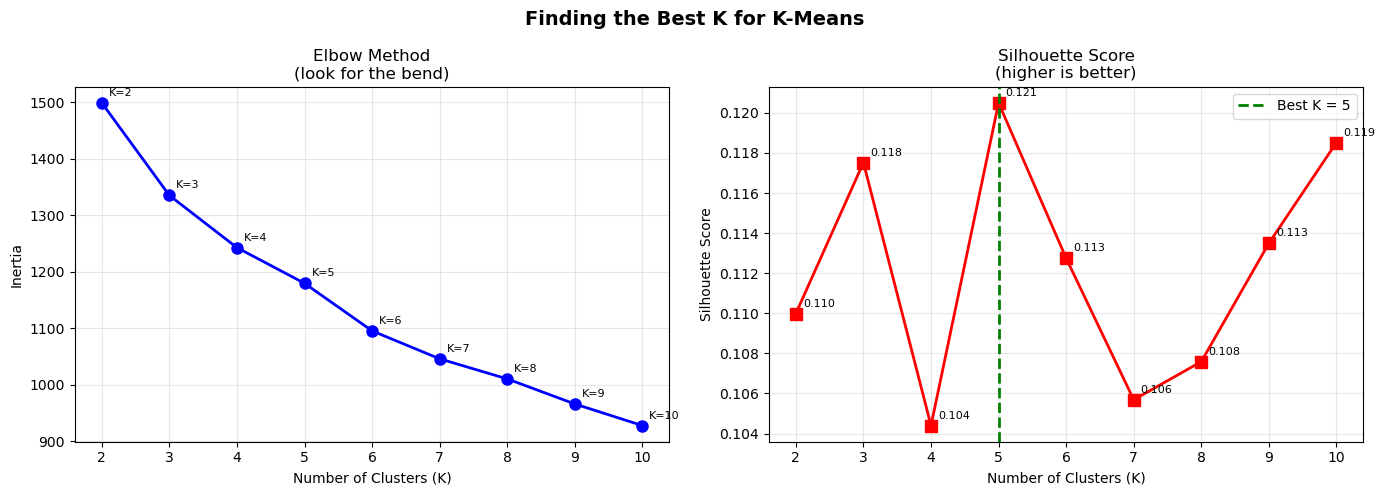


✅ Best K by Silhouette Score : 5
   Silhouette Score          : 0.1205


In [224]:
# Plot Elbow and Silhouette side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finding the Best K for K-Means', fontsize=14, fontweight='bold')

# ── Elbow plot ────────────────────────────────────────────────────────────────
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method\n(look for the bend)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

# Annotate each point with its K value
for k, inertia in zip(k_range, inertias):
    axes[0].annotate(f'K={k}',
                     xy=(k, inertia),
                     xytext=(5, 5),
                     textcoords='offset points',
                     fontsize=8)

# ── Silhouette plot ───────────────────────────────────────────────────────────
best_k   = list(k_range)[sil_scores.index(max(sil_scores))]
axes[1].plot(k_range, sil_scores, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=best_k, color='green',
                linestyle='--', linewidth=2,
                label=f'Best K = {best_k}')
axes[1].set_title('Silhouette Score\n(higher is better)')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Annotate each point
for k, sil in zip(k_range, sil_scores):
    axes[1].annotate(f'{sil:.3f}',
                     xy=(k, sil),
                     xytext=(5, 5),
                     textcoords='offset points',
                     fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n✅ Best K by Silhouette Score : {best_k}")
print(f"   Silhouette Score          : {max(sil_scores):.4f}")

## Step 24: Fit K-Means & Interpret the Clusters

**Goal:** Assign clusters and give each one a meaningful business label.

**Steps:**
1. Fit final model: `KMeans(n_clusters=K, random_state=42, n_init=10)`
2. Add labels back: `df['cluster'] = model.labels_`
3. Profile clusters using the **unscaled** dataframe:
   ```python
   df.groupby('cluster')[feature_cols].mean()
   ```
4. Create a summary table: mean of each feature per cluster
5. Visualize: radar chart or grouped bar chart comparing clusters across features
6. Name your clusters based on their profile:
   - e.g. *"Cluster 0: High budget, low conversion — Awareness ads"*
   - e.g. *"Cluster 1: Low budget, high CTR — Efficient performance ads"*

**Optional: Visualize clusters in 2D using PCA**
- Reduce to 2 components using `sklearn.decomposition.PCA(n_components=2)`
- Scatter plot colored by cluster label
- This helps visually confirm clusters are well-separated

**Final deliverable:** A cluster label column added to your ads dataframe, with a written interpretation of what each cluster represents.

In [225]:
# YOUR CODE HERE
from sklearn.decomposition import PCA

# ── Fit final model with K=5 ──────────────────────────────────────────────────
OPTIMAL_K = 5

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
km_final.fit(X_scaled)

# Add cluster labels
cluster_clean = cluster_clean.copy()
cluster_clean['cluster'] = km_final.labels_

X_original = X_original.copy()
X_original['cluster'] = km_final.labels_

print("=== CLUSTER SIZES ===")
sizes = cluster_clean['cluster'].value_counts().sort_index()
for cluster_id, count in sizes.items():
    pct = count / len(cluster_clean) * 100
    bar = '█' * count
    print(f"  Cluster {cluster_id} : {count:>3} ads ({pct:.1f}%)  {bar}")

# Fit KMeans with optimal K
# Add cluster labels
# Profile and name each cluster
# Optional: PCA 2D scatter plot

=== CLUSTER SIZES ===
  Cluster 0 :  32 ads (20.8%)  ████████████████████████████████
  Cluster 1 :  41 ads (26.6%)  █████████████████████████████████████████
  Cluster 2 :  21 ads (13.6%)  █████████████████████
  Cluster 3 :  55 ads (35.7%)  ███████████████████████████████████████████████████████
  Cluster 4 :   5 ads (3.2%)  █████


In [230]:
# ── Cluster profiles ──────────────────────────────────────────────────────────
profile_cols = [
    'click_rate', 'purchase_rate', 'engagement_rate',
    'impression_rate', 'unique_users',
    'events_per_budget', 'total_budget'
]

profile = X_original.groupby('cluster')[profile_cols].mean().round(4)

print("\n=== CLUSTER PROFILES (mean values) ===")
print(profile.T)


=== CLUSTER PROFILES (mean values) ===
cluster                     0           1           2           3          4
click_rate             0.0970      0.0983      0.1101      0.1003     0.1016
purchase_rate          0.0040      0.0056      0.0056      0.0052     0.0044
engagement_rate        0.0459      0.0442      0.0488      0.0445     0.0445
impression_rate        0.8531      0.8519      0.8355      0.8500     0.8495
unique_users        1813.6875   1823.3415   1801.3810   1794.3091  1836.0000
events_per_budget      0.0412      0.0284      0.0390      0.0796     0.2558
total_budget       57761.9509  73995.2051  60157.4133  30165.1344  7918.0400


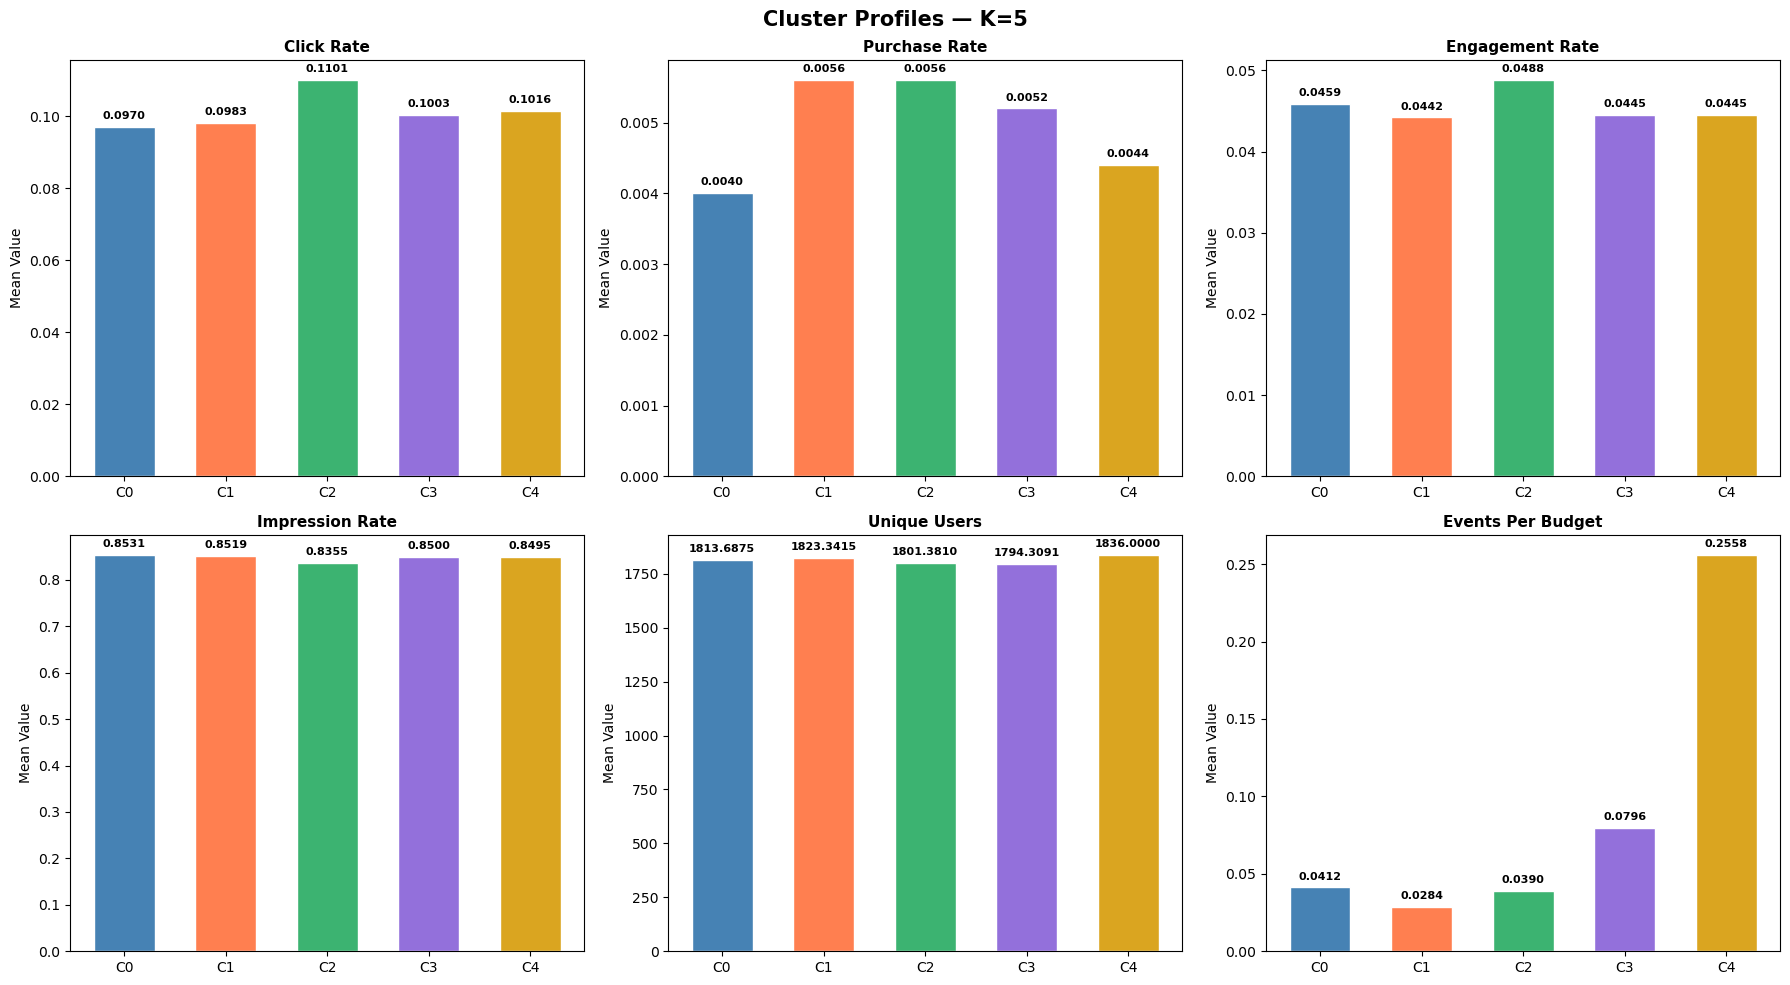

In [231]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Cluster Profiles — K=5',
             fontsize=15, fontweight='bold')

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod']

for i, col in enumerate(profile_cols[:6]):
    row     = i // 3
    col_idx = i % 3

    values = profile[col].values
    bars   = axes[row, col_idx].bar(
        [f'C{c}' for c in profile.index],
        values,
        color=colors,
        edgecolor='white',
        width=0.6
    )
    axes[row, col_idx].set_title(col.replace('_', ' ').title(),
                                  fontsize=11, fontweight='bold')
    axes[row, col_idx].set_ylabel('Mean Value')

    # Value labels on bars
    for bar, val in zip(bars, values):
        axes[row, col_idx].text(
            bar.get_x() + bar.get_width() / 2,
            val + max(values) * 0.02,
            f'{val:.4f}',
            ha='center', fontsize=8, fontweight='bold'
        )

plt.tight_layout()
plt.show()

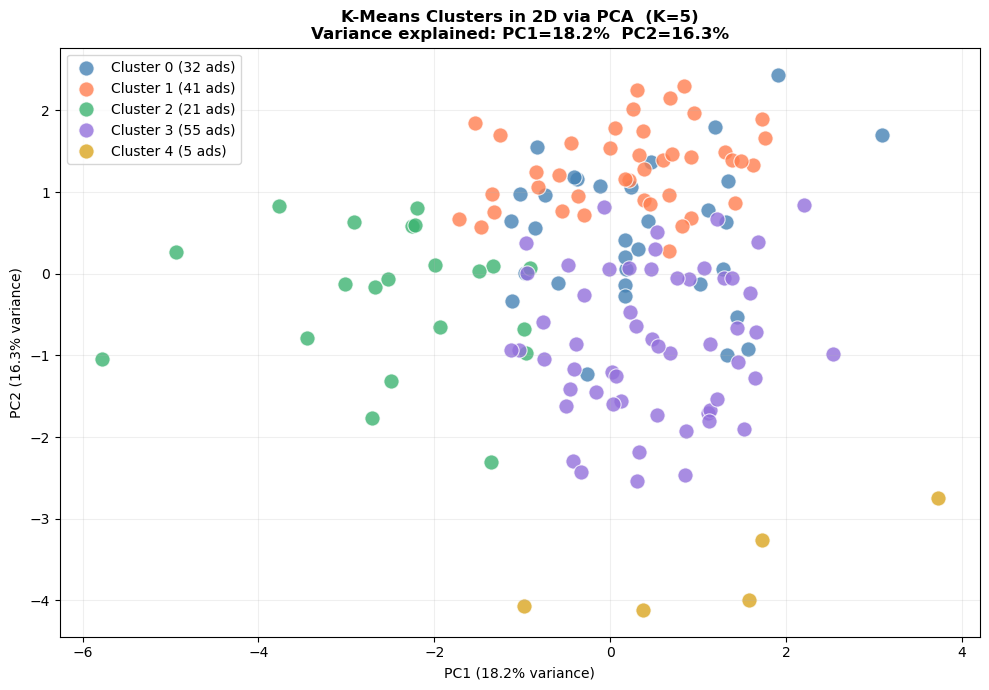

In [232]:
# ── PCA 2D scatter plot ───────────────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for cluster_id in range(OPTIMAL_K):
    mask = km_final.labels_ == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f'Cluster {cluster_id} ({mask.sum()} ads)',
        color=colors[cluster_id],
        alpha=0.8,
        s=120,
        edgecolors='white',
        linewidth=0.8
    )

plt.title(f'K-Means Clusters in 2D via PCA  (K=5)\n'
          f'Variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
          f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%',
          fontsize=12, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [233]:
# ── Interpret and name each cluster ──────────────────────────────────────────
print("=" * 55)
print("       CLUSTER INTERPRETATION & NAMING")
print("=" * 55)

for cluster_id in range(OPTIMAL_K):
    row = profile.loc[cluster_id]
    n   = (cluster_clean['cluster'] == cluster_id).sum()

    # Compare each metric to overall average
    avg_click  = profile['click_rate'].mean()
    avg_purch  = profile['purchase_rate'].mean()
    avg_eng    = profile['engagement_rate'].mean()
    avg_budget = profile['total_budget'].mean()
    avg_eff    = profile['events_per_budget'].mean()

    click_level  = '🔴 High' if row['click_rate']        > avg_click  else '🔵 Low'
    purch_level  = '🔴 High' if row['purchase_rate']     > avg_purch  else '🔵 Low'
    eng_level    = '🔴 High' if row['engagement_rate']   > avg_eng    else '🔵 Low'
    budget_level = '🔴 High' if row['total_budget']      > avg_budget else '🔵 Low'
    eff_level    = '🔴 High' if row['events_per_budget'] > avg_eff    else '🔵 Low'

    print(f"\n{'─'*55}")
    print(f"  CLUSTER {cluster_id}  ({n} ads)")
    print(f"{'─'*55}")
    print(f"  Click rate       : {row['click_rate']:.2%}   {click_level}")
    print(f"  Purchase rate    : {row['purchase_rate']:.2%}   {purch_level}")
    print(f"  Engagement rate  : {row['engagement_rate']:.2%}   {eng_level}")
    print(f"  Budget           : ${row['total_budget']:,.0f}   {budget_level}")
    print(f"  Efficiency       : {row['events_per_budget']:.6f}  {eff_level}")
    print(f"  Unique users     : {row['unique_users']:.0f}")

print(f"\n{'─'*55}")
print("\n💡 Name each cluster after seeing the numbers above:")
print("   Example labels:")
print("   → High Converters   (high purchase_rate)")
print("   → Click Magnets     (high click_rate)")
print("   → Engagement Stars  (high engagement_rate)")
print("   → Budget Efficient  (high events_per_budget)")
print("   → Underperformers   (low on all metrics)")

       CLUSTER INTERPRETATION & NAMING

───────────────────────────────────────────────────────
  CLUSTER 0  (32 ads)
───────────────────────────────────────────────────────
  Click rate       : 9.70%   🔵 Low
  Purchase rate    : 0.40%   🔵 Low
  Engagement rate  : 4.59%   🔴 High
  Budget           : $57,762   🔴 High
  Efficiency       : 0.041200  🔵 Low
  Unique users     : 1814

───────────────────────────────────────────────────────
  CLUSTER 1  (41 ads)
───────────────────────────────────────────────────────
  Click rate       : 9.83%   🔵 Low
  Purchase rate    : 0.56%   🔴 High
  Engagement rate  : 4.42%   🔵 Low
  Budget           : $73,995   🔴 High
  Efficiency       : 0.028400  🔵 Low
  Unique users     : 1823

───────────────────────────────────────────────────────
  CLUSTER 2  (21 ads)
───────────────────────────────────────────────────────
  Click rate       : 11.01%   🔴 High
  Purchase rate    : 0.56%   🔴 High
  Engagement rate  : 4.88%   🔴 High
  Budget           : $60,157   🔴 

In [235]:

# ── Add cluster labels to ad_metrics ─────────────────────────────────────────
ad_metrics_clustered = ad_metrics.merge(
    cluster_clean[['ad_id', 'cluster']],
    on='ad_id',
    how='left'
)

print("\n=== AD METRICS WITH CLUSTERS ===")
print(ad_metrics_clustered.groupby('cluster')[
    ['click_rate', 'purchase_rate',
     'engagement_rate', 'total_budget']
].mean().round(4))

# Save
ad_metrics_clustered.to_csv('ad_metrics_clustered.csv', index=False)
print("\n✅ Saved to 'ad_metrics_clustered.csv'")


=== AD METRICS WITH CLUSTERS ===
         click_rate  purchase_rate  engagement_rate  total_budget
cluster                                                          
0.0          0.0970         0.0040           0.0459    57761.9509
1.0          0.0983         0.0056           0.0442    73995.2051
2.0          0.1101         0.0056           0.0488    60157.4133
3.0          0.1003         0.0052           0.0445    30165.1344
4.0          0.1016         0.0044           0.0445     7918.0400

✅ Saved to 'ad_metrics_clustered.csv'


In [ ]:
CLUSTER 0 → "High Budget Engagers"
  High engagement + High budget but low efficiency
  Spending a lot to get likes/shares but not clicks or purchases
  These ads are good for BRAND AWARENESS not conversions

CLUSTER 1 → "Expensive Converters"
  High purchase rate + Highest budget but lowest efficiency
  Spending the most money and getting purchases
  but paying a lot per result — ROI needs review

CLUSTER 2 → "All-Round Stars"
  High on ALL metrics — click, purchase AND engagement
  Best performing ads overall
  These are your TOP ads — study what they do right

CLUSTER 3 → "Budget Converters"
  Low budget but decent purchase rate
  Getting conversions without spending much
  Most COST EFFECTIVE for purchases

CLUSTER 4 → "Ultra Efficient"
  Tiny budget ($7,918) but HIGHEST efficiency (0.2558)
  Getting the most events per dollar spent
  Only 5 ads — these are hidden gems

---
# ✅ Summary Checklist

Use this to track your progress:

### Phase 1 — Understand
- [ ] Step 1: Load & inspect all 4 tables
- [ ] Step 2: Statistical summary & value counts

### Phase 2 — Clean
- [ ] Step 3: Fix data types (user_id, dates, timestamps)
- [ ] Step 4: Handle missing values
- [ ] Step 5: Remove duplicates
- [ ] Step 6: Standardize text & fix inconsistencies

### Phase 3 — EDA
- [ ] Step 7: Univariate analysis + plots
- [ ] Step 8: Bivariate analysis (vs event_type)
- [ ] Step 9: Campaign-level analysis

### Phase 4 — Encode & Scale
- [ ] Step 10: Encode categorical variables
- [ ] Step 11: Scale numerical variables
- [ ] Step 12: Multi-hot encode interests

### Phase 5 — Merge
- [ ] Step 13: Plan joins & validate keys
- [ ] Step 14: Execute 3-step merge
- [ ] Step 15: Post-merge validation

### Phase 6 — Feature Engineering
- [ ] Step 16: Binary event flags + datetime features
- [ ] Step 17: Ad-level aggregated metrics
- [ ] Step 18: Audience match features

### Phase 7 — Visualize
- [ ] Step 19: All advanced charts on merged data

### Phase 8 — Pipeline Class
- [ ] Step 20: Build & test AdAnalysisPipeline class

### Phase 9 — Clustering
- [ ] Step 21: Choose segmentation target
- [ ] Step 22: Prepare & scale clustering features
- [ ] Step 23: Elbow + Silhouette to find K
- [ ] Step 24: Fit, interpret & name clusters